# EDA DESCRIPTION SONG NGỮ TRUNG–VIỆT (1688)

**Đầu vào:** `data/snapshot/bilingual_zh_vi.parquet` (16.348 sản phẩm), khoá bằng SHA256: file đổi thì notebook dừng ngay ô đầu.
**Phạm vi:** chỉ phần description song ngữ: `description_zh`, `description_vi`, `attributes_zh`, `attributes_vi`, `description_extra_zh`. Title chỉ dùng ở block 14 (so thuật ngữ). Không dùng mô hình hay embedding nào.
**Chạy ở đâu:** kernel local `.venv` của folder `e-commerce - EDA` (Python 3.13). Chạy từ trên xuống (Run All), mất khoảng vài phút.

**Cách đọc:** mỗi block có ô chữ (làm gì, đọc biểu đồ thế nào), ô code, rồi output: bảng, biểu đồ, và dòng **KẾT LUẬN** in số thật vừa tính.
Dòng `[OK]` / `[LỆCH]` so con số của notebook với số em đo lúc khảo sát ngày 01/10 bằng script riêng. `[LỆCH]` nghĩa là block đó cần kiểm lại trước khi tin.

**Ba cấp phân tích** (đừng trộn số của các cấp):
- **Dòng** = 1 sản phẩm (16.348).
- **Cặp thuộc tính** = 1 cặp `tên: giá trị` zh–vi trong 1 sản phẩm.
- **Cặp giá trị** = 1 giá trị trong danh sách (vd 1 màu trong `颜色: 黑色, 白色`).

**File xuất:** `data/eda/description/` (CSV `utf-8-sig`, mở bằng Excel được). File tên `*_editted.csv` có cột trống `anh_duyet`, `anh_ghi_chu` để anh duyệt tay. Cache sinh lại được: `data/interim/`. Notebook **không sửa dữ liệu**.

| Block | Nội dung |
|---|---|
| 0 | Cài đặt, kiểm SHA256, hàm dùng chung |
| 1 | Tổng quan cấu trúc, theo category, theo ngày crawl |
| 2 | Ghép cặp thuộc tính đúng cách (bẫy thứ tự, D08) |
| 3 | Độ dài và đơn vị dữ liệu (không phụ thuộc mô hình) |
| 4 | Tên thuộc tính: độ phủ, cách dịch không thống nhất |
| 5 | Vai trò thuộc tính (gợi ý để anh duyệt) |
| 6 | Giá trị thuộc tính: kiểu giá trị, kích thước thật |
| 7 | Tên hãng (品牌) |
| 8 | Lỗi đánh số ("Không.1", "Là2"...) |
| 9 | Chữ Hán còn sót, tiếng Anh do máy dịch thêm |
| 10 | Số và đơn vị |
| 11 | Trùng lặp và gần trùng |
| 12 | Thông tin cá nhân |
| 13 | `description_extra_zh` |
| 14 | Thuật ngữ: title so với description |
| 15 | Đọc thêm: dịch sai nghĩa (tên, giá trị, 是否), địa danh, không thống nhất, định dạng, ký tự lạ |
| 16 | Tổng hợp vấn đề + bảng kiểm `[OK]/[LỆCH]` |

## 0. Cài đặt

Tìm thư mục gốc của folder EDA, kiểm SHA256 của snapshot, đặt kiểu biểu đồ (1 chuỗi số liệu = 1 màu, lưới mảnh), và định nghĩa các hàm dùng chung:
`check()` in `[OK]/[LỆCH]`, `ket_luan()` in kết luận, `ghi_csv()` ghi file, `ghi_van_de()` gom vấn đề cho bảng tổng hợp ở block 15.

In [1]:
import hashlib
import random
import re
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

T0 = time.time()


def find_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "data" / "snapshot" / "bilingual_zh_vi.parquet").exists():
            return p
    raise FileNotFoundError("Không thấy data/snapshot/bilingual_zh_vi.parquet: hãy mở notebook trong folder 'e-commerce - EDA'.")


ROOT = find_root()
SNAP = ROOT / "data" / "snapshot" / "bilingual_zh_vi.parquet"
OUT = ROOT / "data" / "eda" / "description"
INTERIM = ROOT / "data" / "interim"
OUT.mkdir(parents=True, exist_ok=True)
INTERIM.mkdir(parents=True, exist_ok=True)

EXPECTED_SHA256 = "B4E5CE75D5AE8AF523235B5C23F5C7289E405A8230D879F11136AFC938135A29"
sha = hashlib.sha256(SNAP.read_bytes()).hexdigest().upper()
assert sha == EXPECTED_SHA256, f"SHA256 của snapshot đã đổi ({sha}). Dừng lại, xem data/snapshot/SNAPSHOT.md."

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 80)

# Kiểu biểu đồ: nền sáng, chữ xám, lưới mảnh; 1 chuỗi số liệu dùng 1 màu (C1)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
SEQ = LinearSegmentedColormap.from_list("xanh", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
_installed = {f.name for f in font_manager.fontManager.ttflist}
_cjk = [f for f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "WenQuanYi Zen Hei"] if f in _installed]
plt.rcParams.update({
    "font.family": ["DejaVu Sans", *_cjk],
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titlelocation": "left", "axes.labelsize": 10,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.dpi": 110, "axes.unicode_minus": False,
})
if not _cjk:
    print("Cảnh báo: máy không có font chữ Hán, nhãn tiếng Trung trong biểu đồ sẽ thành ô vuông.")

CJK = re.compile("[\u4e00-\u9fff]")
VI_DAU = re.compile("[àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]", re.I)
CATS = ["fashion", "electronics", "shoes", "bags", "beauty", "mother_baby", "food", "home", "auto"]


def has_cjk(s):
    return bool(CJK.search(s or ""))


def pct(a, b):
    return 100.0 * a / b if b else 0.0


def so(n):
    """Số nguyên kiểu Việt: 16.348"""
    return f"{int(n):,}".replace(",", ".")


def tl(a, b, nd=2):
    """Tỉ lệ kiểu Việt: 8,98%"""
    return f"{pct(a, b):.{nd}f}%".replace(".", ",")


def sf(x, nd=1):
    """Số thập phân kiểu Việt: 2,7"""
    return f"{x:.{nd}f}".replace(".", ",")


CHECKS = []


def check(ten, got, expected):
    ok = int(got) == int(expected)
    CHECKS.append({"chi_so": ten, "notebook": int(got), "luc_khao_sat": int(expected), "khop": ok})
    print(f"[{'OK' if ok else 'LỆCH'}] {ten}: {so(got)}" + ("" if ok else f"  (lúc khảo sát: {so(expected)})"))


def ket_luan(*dong):
    print("\nKẾT LUẬN:")
    for d in dong:
        print("  -", d)


def ghi_csv(frame, ten):
    path = OUT / ten
    frame.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"Đã ghi {path.relative_to(ROOT).as_posix()} ({so(len(frame))} dòng)")


ISSUES = {}


def ghi_van_de(ma, van_de, muc_do, cach_phat_hien, bang_chung, so_cap=None):
    """bang_chung: dict {chỉ số dòng của df: chuỗi bằng chứng ngắn}"""
    ISSUES[ma] = dict(van_de=van_de, muc_do=muc_do, cach_phat_hien=cach_phat_hien,
                      bang_chung={int(k): str(v)[:200] for k, v in bang_chung.items()}, so_cap=so_cap)


def bar_h(labels, values, title, xlabel, fmt_val=None, width=8.5):
    labels, values = list(labels)[::-1], list(values)[::-1]
    fig, ax = plt.subplots(figsize=(width, 0.34 * len(labels) + 1.3))
    ax.barh(range(len(values)), values, color=C1, height=0.62)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    if fmt_val and len(values) <= 16:
        for i, v in enumerate(values):
            ax.text(v, i, " " + fmt_val(v), va="center", fontsize=8.5, color=INK2)
    plt.tight_layout()
    plt.show()


print("Thư mục gốc:", ROOT)
print("SHA256 snapshot khớp SNAPSHOT.md")
print("pandas", pd.__version__, "| font chữ Hán:", _cjk or "không có")

Thư mục gốc: D:\nam4_ky1\e-commerce - EDA
SHA256 snapshot khớp SNAPSHOT.md
pandas 3.0.5 | font chữ Hán: ['Microsoft YaHei']


## 1. Tổng quan cấu trúc

**Làm gì:** đếm dòng rỗng, độ dài, số thuộc tính, số ảnh; so theo 9 category; xem số thuộc tính có đổi theo ngày crawl không (nếu đổi trong cùng 1 category thì có thể parser đã đổi giữa chừng).

**Đọc biểu đồ:** histogram = có bao nhiêu sản phẩm có N thuộc tính; boxplot = độ dài `description_vi` theo category (vạch giữa hộp là trung vị, không vẽ điểm ngoại lai); bản đồ nhiệt = số sản phẩm crawl theo ngày × category (càng đậm càng nhiều).

[OK] Số dòng (sản phẩm): 16.348

Độ dài (ký tự) từng cột:


,cot,dong_rong,trung_vi_ky_tu,p90,p99,dai_nhat
0,description_zh,0,421,718,1344,6629
1,description_vi,0,1132,1885,3829,15756
2,description_extra_zh,12599,0,161,911,12375


Số thuộc tính và số ảnh:


,n_attributes_zh,n_attributes_vi,n_attributes_aligned,description_images
count,16348.0,16348.0,16348.0,16348.0
mean,24.9,24.9,24.9,19.2
std,8.9,8.9,8.9,13.0
min,4.0,4.0,4.0,0.0
25%,18.0,18.0,18.0,11.0
50%,22.0,22.0,22.0,17.0
75%,32.0,32.0,32.0,24.0
max,53.0,53.0,53.0,294.0


Theo category (tv = trung vị):


,so_dong,tv_so_thuoc_tinh,tv_ky_tu_zh,tv_ky_tu_vi,co_extra_zh_pct,tv_so_anh
category,,,,,,
fashion,1351,36.0,508.0,1315.0,16.9,17.0
electronics,1109,19.0,458.0,1138.0,22.9,15.0
shoes,2311,39.0,506.0,1378.0,23.5,18.0
bags,2878,19.0,238.0,650.0,22.1,23.0
beauty,1318,21.0,360.0,1003.5,25.0,15.0
mother_baby,2496,25.0,461.0,1242.0,23.6,16.0
food,1421,21.0,338.0,946.0,22.4,13.0
home,2493,21.0,507.0,1375.0,18.3,16.0
auto,971,21.0,391.0,1055.0,40.9,16.0


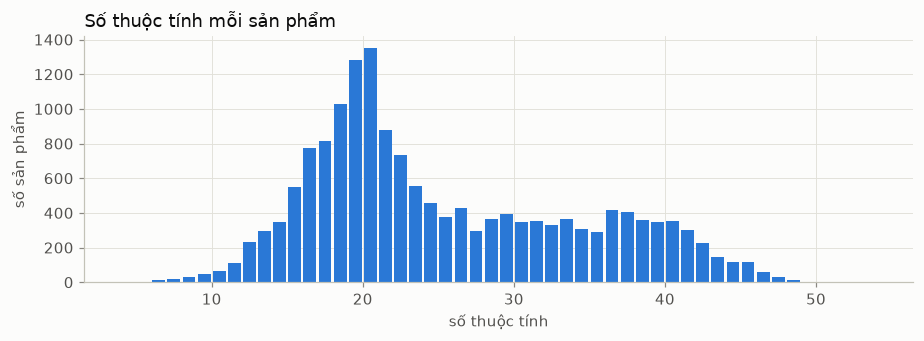

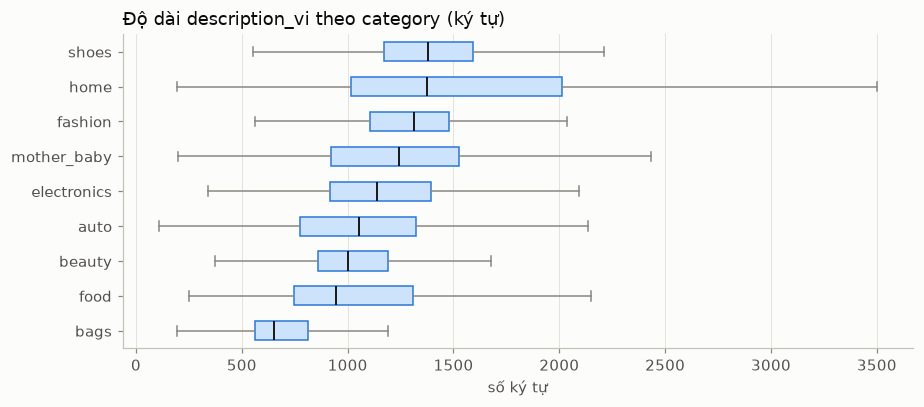

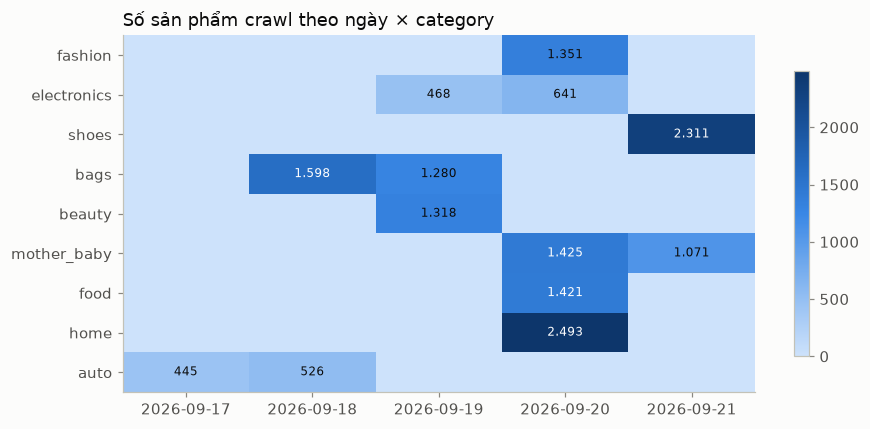

Trung vị số thuộc tính theo category × ngày crawl (ô trống = ngày đó không crawl category này):


ngay_crawl,2026-09-17,2026-09-18,2026-09-19,2026-09-20,2026-09-21
category,,,,,
fashion,NaN,NaN,NaN,36.0,NaN
electronics,NaN,NaN,22.0,16.0,NaN
shoes,NaN,NaN,NaN,NaN,39.0
bags,NaN,18.0,19.0,NaN,NaN
beauty,NaN,NaN,21.0,NaN,NaN
mother_baby,NaN,NaN,NaN,32.0,18.0
food,NaN,NaN,NaN,21.0,NaN
home,NaN,NaN,NaN,21.0,NaN
auto,15.0,26.0,NaN,NaN,NaN


Trung vị số thuộc tính theo category × worker (máy crawl):


worker,worker_huy,worker_nhat_anh
category,,
fashion,36.0,36.0
electronics,18.0,19.0
shoes,37.0,40.0
bags,19.0,19.0
beauty,21.0,21.0
mother_baby,33.0,22.0
food,21.0,21.0
home,22.0,21.0
auto,28.0,18.0


Trong cùng danh mục con 1688: số thuộc tính của máy Huy trừ máy Nhật Anh (trung vị các danh mục con):


,category,so_danh_muc_con_ca_2_may,tv_chenh_huy_tru_nhat_anh,chenh_lon_nhat
0,fashion,3,0.0,2.0
1,electronics,3,1.0,1.0
2,shoes,6,-0.5,1.5
3,bags,8,0.0,1.0
4,beauty,4,0.0,1.0
5,mother_baby,3,-1.0,2.0
6,food,7,0.5,2.0
7,home,8,0.0,0.0
8,auto,1,3.0,3.0



KẾT LUẬN:
  - Không dòng nào rỗng description_zh/description_vi; 12.599 dòng rỗng description_extra_zh.
  - Số thuộc tính zh = vi = aligned ở 16.348/16.348 dòng; trung vị 22 thuộc tính/sản phẩm (từ 4 tới 53).
  - Bản Việt dài gấp khoảng 2,7 lần bản Trung tính theo ký tự (chữ Hán đặc hơn chữ Latin, không phải lỗi).
  - Trong cùng 1 category, chênh trung vị số thuộc tính giữa các ngày crawl (ngày có ≥ 50 sản phẩm): electronics 6, bags 1, mother_baby 14, auto 11. Chênh ≥ 5 ở: electronics, mother_baby, auto.
  - Trong cùng danh mục con, 2 máy không lệch đáng kể → chênh lệch theo ngày/máy chủ yếu do mỗi máy crawl danh mục con khác nhau.


In [2]:
df = pd.read_parquet(SNAP).reset_index(drop=True)
for c in ["description_zh", "description_vi", "description_extra_zh"]:
    df[c] = df[c].fillna("")
N = len(df)
check("Số dòng (sản phẩm)", N, 16348)

rows = []
for c in ["description_zh", "description_vi", "description_extra_zh"]:
    L = df[c].str.len()
    rows.append({"cot": c, "dong_rong": int((L == 0).sum()), "trung_vi_ky_tu": int(L.median()),
                 "p90": int(L.quantile(.9)), "p99": int(L.quantile(.99)), "dai_nhat": int(L.max())})
print("\nĐộ dài (ký tự) từng cột:")
display(pd.DataFrame(rows))

same_n = ((df.n_attributes_zh == df.n_attributes_vi) & (df.n_attributes_vi == df.n_attributes_aligned)).sum()
print("Số thuộc tính và số ảnh:")
display(df[["n_attributes_zh", "n_attributes_vi", "n_attributes_aligned", "description_images"]].describe().round(1))

cat = (df.groupby("category")
         .agg(so_dong=("product_id", "size"),
              tv_so_thuoc_tinh=("n_attributes_zh", "median"),
              tv_ky_tu_zh=("description_zh", lambda s: s.str.len().median()),
              tv_ky_tu_vi=("description_vi", lambda s: s.str.len().median()),
              co_extra_zh_pct=("description_extra_zh", lambda s: round(100 * (s.str.len() > 0).mean(), 1)),
              tv_so_anh=("description_images", "median"))
         .reindex(CATS))
print("Theo category (tv = trung vị):")
display(cat)

fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.hist(df.n_attributes_zh, bins=range(int(df.n_attributes_zh.min()), int(df.n_attributes_zh.max()) + 2), color=C1, rwidth=0.85)
ax.set_title("Số thuộc tính mỗi sản phẩm")
ax.set_xlabel("số thuộc tính")
ax.set_ylabel("số sản phẩm")
plt.tight_layout()
plt.show()

order = df.groupby("category").description_vi.apply(lambda s: s.str.len().median()).sort_values().index
fig, ax = plt.subplots(figsize=(8.5, 3.8))
bp = ax.boxplot([df.loc[df.category == c, "description_vi"].str.len() for c in order], orientation="horizontal", showfliers=False,
                patch_artist=True, widths=0.55, medianprops=dict(color=INK, linewidth=1.2))
for b in bp["boxes"]:
    b.set(facecolor="#cde2fb", edgecolor=C1)
for k in ["whiskers", "caps"]:
    for w in bp[k]:
        w.set(color=MUTED)
ax.set_yticks(range(1, len(order) + 1), order)
ax.set_title("Độ dài description_vi theo category (ký tự)")
ax.set_xlabel("số ký tự")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

df["ngay_crawl"] = df.crawl_time.str[:10]
ct = pd.crosstab(df.category, df.ngay_crawl).reindex(CATS)
med = df.pivot_table(index="category", columns="ngay_crawl", values="n_attributes_zh", aggfunc="median").reindex(CATS)
fig, ax = plt.subplots(figsize=(8.5, 4))
im = ax.imshow(ct.values, cmap=SEQ, aspect="auto")
ax.set_xticks(range(ct.shape[1]), ct.columns)
ax.set_yticks(range(ct.shape[0]), ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        if v:
            ax.text(j, i, so(v), ha="center", va="center", fontsize=8, color="white" if v > ct.values.max() * 0.55 else INK)
ax.set_title("Số sản phẩm crawl theo ngày × category")
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()
print("Trung vị số thuộc tính theo category × ngày crawl (ô trống = ngày đó không crawl category này):")
display(med)

spread = {}
for c in CATS:
    days = ct.columns[ct.loc[c] >= 50]
    vals = med.loc[c, days].dropna()
    if len(vals) >= 2:
        spread[c] = float(vals.max() - vals.min())
by_worker = df.groupby(["category", "worker"]).n_attributes_zh.median().unstack().reindex(CATS)
print("Trung vị số thuộc tính theo category × worker (máy crawl):")
display(by_worker)

# Tách nguyên nhân: so 2 máy trong CÙNG danh mục con của 1688 (category_1688), chỉ lấy danh mục con mà mỗi máy có ≥ 20 sản phẩm.
# Nếu trong cùng danh mục con mà 2 máy vẫn lệch nhiều → nghi do máy/phiên bản crawler; nếu hết lệch → do 2 máy crawl danh mục con khác nhau.
sub = df.groupby(["category", "category_1688", "worker"]).n_attributes_zh.agg(["median", "size"]).unstack("worker")
sub = sub[(sub["size"] >= 20).all(axis=1)]
cmp_rows = []
for c in CATS:
    if c not in sub.index.get_level_values(0):
        continue
    s = sub.loc[c]
    d = (s[("median", "worker_huy")] - s[("median", "worker_nhat_anh")])
    cmp_rows.append({"category": c, "so_danh_muc_con_ca_2_may": len(s), "tv_chenh_huy_tru_nhat_anh": float(d.median()),
                     "chenh_lon_nhat": float(d.abs().max())})
CMP = pd.DataFrame(cmp_rows)
print("Trong cùng danh mục con 1688: số thuộc tính của máy Huy trừ máy Nhật Anh (trung vị các danh mục con):")
display(CMP)
lech_may = CMP[CMP.tv_chenh_huy_tru_nhat_anh.abs() >= 5]
big_spread = [c for c, v in spread.items() if v >= 5]

ket_luan(
    f"Không dòng nào rỗng description_zh/description_vi; {so((df.description_extra_zh == '').sum())} dòng rỗng description_extra_zh.",
    f"Số thuộc tính zh = vi = aligned ở {so(same_n)}/{so(N)} dòng; trung vị {int(df.n_attributes_zh.median())} thuộc tính/sản phẩm (từ {int(df.n_attributes_zh.min())} tới {int(df.n_attributes_zh.max())}).",
    f"Bản Việt dài gấp khoảng {sf(df.description_vi.str.len().median() / df.description_zh.str.len().median(), 1)} lần bản Trung tính theo ký tự (chữ Hán đặc hơn chữ Latin, không phải lỗi).",
    "Trong cùng 1 category, chênh trung vị số thuộc tính giữa các ngày crawl (ngày có ≥ 50 sản phẩm): "
    + (", ".join(f"{c} {v:g}" for c, v in spread.items()) or "không đủ dữ liệu")
    + (f". Chênh ≥ 5 ở: {', '.join(big_spread)}." if big_spread else "."),
    ("Trong cùng danh mục con, 2 máy vẫn lệch ≥ 5 thuộc tính ở: " + ", ".join(lech_may.category)
     + " → nghi do máy/phiên bản crawler, cần hỏi Huy và kiểm lại parser trước khi coi là đặc điểm dữ liệu.")
    if len(lech_may) else
    "Trong cùng danh mục con, 2 máy không lệch đáng kể → chênh lệch theo ngày/máy chủ yếu do mỗi máy crawl danh mục con khác nhau.",
)

## 2. Ghép cặp thuộc tính đúng cách

**Vì sao quan trọng:** mọi phân tích cấp thuộc tính phải ghép đúng `tên: giá trị` tiếng Trung với tiếng Việt. Có 2 bẫy:
1. `attributes_zh` đúng thứ tự với `description_zh`, nhưng **`attributes_vi` có thứ tự khác** `description_vi`, và struct không có `fid`. Ghép `attributes_zh[i]` với `attributes_vi[i]` là ghép sai.
2. Tách chuỗi `description_vi` bằng `"; "` bị lệch khi giá trị tiếng Việt có chứa `"; "`. Đây chính là nguyên nhân của **D08** (72 dòng), không phải lỗi crawler.

**Cách làm:** `description_zh` và `description_vi` cùng thứ tự `fid` (README crawler). Với mỗi dòng, dò từng đoạn `tên: giá trị` của `attributes_vi` trong `description_vi` từ trái sang phải để khôi phục thứ tự, rồi ghép với `attributes_zh` theo vị trí.

**Gắn cờ lỗi đánh số ngay ở đây** (phân tích kỹ ở block 8):
- Máy dịch thêm số đuôi vào những **bản dịch tiếng Việt trùng nhau** trong cùng sản phẩm, kể cả giá trị nằm trong danh sách. Ví dụ: 补水 và 保湿 đều ra "Dưỡng ẩm" nên thành "Dưỡng ẩm1", "Dưỡng ẩm2"; "32GB" thành "32GB2"; "0003" thành "00031".
- Cột `val_vi_bo_so` là bản Việt đã bỏ số đuôi đó. Các block 3, 7 và 10 so số và độ dài trên cột này, để lỗi đánh số không bị đếm trùng thành lỗi khác.

**Kiểm thêm:** trong 1 thuộc tính nhiều giá trị (vd danh sách màu "1号…, 2号…"), thứ tự các giá trị zh và vi có giữ nguyên không. Chỉ kiểm được khi mỗi giá trị có số riêng. So 2 lần: thô, và sau khi bỏ số đuôi.

In [3]:
def seg_text(d):
    return f"{d['name']}: {', '.join(d['values'])}"


rebuild_zh = sum("; ".join(seg_text(d) for d in a) == s for a, s in zip(df.attributes_zh, df.description_zh))
check("description_zh dựng lại đúng từ attributes_zh", rebuild_zh, 16347)
same_order_vi = sum([x.partition(": ")[0] for x in s.split("; ") if x.strip()] == [d["name"] for d in a]
                    for a, s in zip(df.attributes_vi, df.description_vi))
check("attributes_vi cùng thứ tự với description_vi", same_order_vi, 21)


def recover(desc, attrs):
    """Trả về thứ tự chỉ số của attributes_vi theo đúng thứ tự xuất hiện trong description_vi, hoặc None."""
    segs = [seg_text(d) for d in attrs]
    used = [False] * len(segs)
    pos, order = 0, []
    while pos < len(desc):
        cand = [i for i, s in enumerate(segs) if not used[i] and desc.startswith(s, pos)
                and (pos + len(s) == len(desc) or desc.startswith("; ", pos + len(s)))]
        if not cand:
            return None
        i = max(cand, key=lambda k: len(segs[k]))
        used[i] = True
        order.append(i)
        pos += len(segs[i]) + 2
    return order if all(used) else None


t = time.time()
df["vi_order"] = [recover(s, a) for s, a in zip(df.description_vi, df.attributes_vi)]
ok_rows = df.vi_order.notna()
check("Dòng khôi phục được thứ tự", ok_rows.sum(), 16342)
print(f"(khôi phục mất {time.time() - t:.0f} giây)")

fail = df.loc[~ok_rows, ["product_id", "category", "n_attributes_vi", "description_vi"]].copy()
fail["description_vi"] = fail.description_vi.str[:160]
print("\nCác dòng KHÔNG khôi phục được (đọc tay):")
display(fail)
bad_zh = df.loc[[i for i, (a, s) in enumerate(zip(df.attributes_zh, df.description_zh)) if "; ".join(seg_text(d) for d in a) != s],
                ["product_id", "category"]]
print("Dòng có description_zh không dựng lại được từ attributes_zh:")
display(bad_zh)

# D08: tách chuỗi bằng "; " ra số đoạn khác nhau
naive_z = df.description_zh.map(lambda s: len(s.split("; ")))
naive_v = df.description_vi.map(lambda s: len(s.split("; ")))
d08 = df.index[naive_z != naive_v]
semi = sum(any("; " in v for d in df.at[i, "attributes_vi"] for v in d["values"]) or any("; " in d["name"] for d in df.at[i, "attributes_vi"]) for i in d08)
check("Dòng D08 (tách '; ' ra số đoạn khác nhau)", len(d08), 72)
check("... trong đó giá trị/tên tiếng Việt chứa '; '", semi, 72)
check("... khôi phục được bằng cách mới", df.loc[d08, "vi_order"].notna().sum(), 72)
ex = []
for i in d08[:3]:
    for d in df.at[i, "attributes_vi"]:
        hit = [v for v in d["values"] if "; " in v]
        if hit:
            ex.append({"product_id": df.at[i, "product_id"], "ten_vi": d["name"], "gia_tri_vi_chua_dau_cham_phay": hit[0][:120]})
            break
print("Ví dụ giá trị tiếng Việt có '; ' bên trong:")
display(pd.DataFrame(ex))

# Bảng cặp thuộc tính (A) và cặp giá trị (V)
recs = []
for i, (az, av, o) in enumerate(zip(df.attributes_zh, df.attributes_vi, df.vi_order)):
    if o is None:
        continue
    for k, j in enumerate(o):
        recs.append((i, k, az[k]["name"], av[j]["name"], list(az[k]["values"]), list(av[j]["values"])))
A = pd.DataFrame(recs, columns=["row", "vi_tri", "name_zh", "name_vi", "vals_zh", "vals_vi"])
A["product_id"] = df.product_id.values[A.row]
A["category"] = df.category.values[A.row]
A["n_vals_zh"] = A.vals_zh.map(len)
A["n_vals_vi"] = A.vals_vi.map(len)
A["val_zh"] = A.vals_zh.map(", ".join)
A["val_vi"] = A.vals_vi.map(", ".join)
check("Cặp thuộc tính", len(A), 406871)
check("Cặp thuộc tính lệch số giá trị zh/vi", (A.n_vals_zh != A.n_vals_vi).sum(), 0)

V = A[["row", "product_id", "category", "name_zh", "name_vi", "vals_zh", "vals_vi"]].copy()
V["a_idx"] = V.index
V = V.explode(["vals_zh", "vals_vi"]).rename(columns={"vals_zh": "v_zh", "vals_vi": "v_vi"})
V = V[V.v_zh.notna()].reset_index(drop=True)
check("Cặp giá trị", len(V), 691128)

# --- Gắn cờ lỗi đánh số ngay từ đây (phân tích kỹ ở block 8), để các block sau so trên giá trị đã bỏ số đuôi.
# Cấp cặp thuộc tính (dùng cho D07 và luật rộng ở block 8):
D07_RE = re.compile(r"(Không|Có|Là|Khác)\.?\d+$")
FULL_RE = re.compile(r"^(Không|Có|Là|Khác)\.?\d+$")
BROAD_RE = re.compile(r"[^\d\s.,]\.?\d+$")
HAS_DIGIT = re.compile(r"\d")
TAIL = re.compile(r"\.?\d+$")
A["lap_trong_sp"] = A.groupby(["row", "val_zh"]).val_zh.transform("size")
A["danh_so_d07"] = A.val_vi.map(lambda v: bool(D07_RE.search(v)))
A["danh_so_rong"] = (A.val_vi.map(lambda v: bool(BROAD_RE.search(v)))
                     & ~A.val_zh.map(lambda s: bool(HAS_DIGIT.search(s))) & (A.lap_trong_sp >= 2))
# Cấp từng giá trị (luật v2, kể cả giá trị nằm trong danh sách, vd "32GB" → "32GB2", "0003" → "00031", 补水/保湿 → "Dưỡng ẩm1/2"):
#   (1) bản vi tận cùng bằng 1–2 chữ số, và bỏ các chữ số đó thì tập số của bản vi khớp tập số của bản zh (số thật của sản phẩm không bị đụng);
#   (2) phần còn lại ("Dưỡng ẩm", "Khác"...) trùng với ít nhất 1 giá trị tiếng Việt khác trong cùng sản phẩm.
# Cơ chế (chứng minh ở block 8): máy dịch đánh số những BẢN DỊCH TIẾNG VIỆT trùng nhau trong 1 sản phẩm.
V["lap_trong_sp"] = V.groupby(["row", "v_zh"]).v_zh.transform("size")


CN_NUM = {"一": 1, "二": 2, "两": 2, "三": 3, "四": 4, "五": 5, "六": 6, "七": 7, "八": 8, "九": 9, "十": 10, "双": 2, "单": 1}


def goc_truoc_so(z, v):
    nz = sorted(DIGITS_RE.findall(z))
    cn = {CN_NUM[c] for c in z if c in CN_NUM}
    for L in (1, 2):
        if len(v) > L and v[-L:].isascii() and v[-L:].isdigit() and int(v[-L:]) not in cn:   # 二级 → "Cấp độ 2" là đổi chữ số Hán, không phải số đuôi
            b = v[:-L].rstrip(".").rstrip()
            if b and sorted(DIGITS_RE.findall(b)) == nz:
                return b
    return ""


DIGITS_RE = re.compile(r"\d+")
V["goc"] = [goc_truoc_so(z, v) for z, v in zip(V.v_zh, V.v_vi)]
V["khoa_vi"] = [(g or v).lower().strip() for g, v in zip(V.goc, V.v_vi)]
V["vi_trung_trong_sp"] = V.groupby(["row", "khoa_vi"]).khoa_vi.transform("size")
V["danh_so_gia_tri"] = (V.goc != "") & (V.vi_trung_trong_sp >= 2)
V["v_vi_bo_so"] = np.where(V.danh_so_gia_tri, V.goc, V.v_vi)
A["danh_so_v2"] = V.groupby("a_idx").danh_so_gia_tri.any().reindex(A.index, fill_value=False).values
# Nghi đánh số "lẻ": có số đuôi kiểu đánh số nhưng KHÔNG thấy bản dịch trùng trong description (có thể trùng với chuỗi ngoài description).
V["nghi_danh_so_le"] = (V.goc != "") & ~V.danh_so_gia_tri
_l2 = V.assign(x=np.where(V.goc != "", V.goc, V.v_vi)).groupby("a_idx").x.agg(", ".join).reindex(A.index)
A["val_vi_bo_ca_nghi"] = [x if isinstance(x, str) else v for x, v in zip(_l2, A.val_vi)]   # dùng cho block 10 (so số)
_lists = V.groupby("a_idx").v_vi_bo_so.agg(list).reindex(A.index)
A["vals_vi_bo_so"] = [x if isinstance(x, list) else list(v) for x, v in zip(_lists, A.vals_vi)]
A["val_vi_bo_so"] = A.vals_vi_bo_so.map(", ".join)
print(f"Cấp giá trị: {so(V.danh_so_gia_tri.sum())} giá trị có số đuôi do máy dịch đánh số "
      f"({so(V.loc[V.danh_so_gia_tri, 'row'].nunique())} dòng); các block sau dùng cột val_vi_bo_so (đã bỏ số đuôi).")

# Thứ tự giá trị bên trong thuộc tính: so dãy số của từng giá trị
DIGITS = re.compile(r"\d+")


def numseq(vals):
    return [tuple(DIGITS.findall(x)) for x in vals]


def kiem_thu_tu(nz, nv, vz, vb):
    """So từng vị trí k: các số của giá trị zh thứ k có nằm trong giá trị vi thứ k không.
    Cho phép bản Việt THÊM số (máy đổi 五件套 → "Bộ 5"): chỉ xét số của bản Trung có còn ở đúng vị trí không.
    Bỏ qua giá trị có 斤 mà bản Việt ghi kg (máy quy đổi 1 斤 = 0,5 kg, số khác là đúng)."""
    kq = "khop"
    for k, (a, b) in enumerate(zip(nz, nv)):
        if "斤" in vz[k] and "kg" in vb[k].lower():
            continue
        if a and not set(a) <= set(b):
            if any(set(a) <= set(nv[j]) for j in range(len(nv)) if j != k):
                return "dao_thu_tu"            # số của giá trị k nằm ở vị trí khác bên Việt
            kq = "so_bi_doi_hoac_mat"           # số của giá trị k không còn ở đâu
    return kq


test = []
for idx, vz, vv, vb in zip(A.index, A.vals_zh, A.vals_vi, A.vals_vi_bo_so):
    if len(vz) < 3:
        continue
    nz = numseq(vz)
    if sum(bool(x) for x in nz) < 3 or len(set(nz)) < len(nz):
        continue
    test.append((idx, nz == numseq(vv), kiem_thu_tu(nz, numseq(vb), vz, vb)))
T = pd.DataFrame(test, columns=["idx", "khop_tuyet_doi", "kieu_lech"])
check("Thuộc tính nhiều giá trị kiểm được thứ tự", len(T), 6030)
check("... dãy số zh và vi khớp tuyệt đối (so thô)", T.khop_tuyet_doi.sum(), 5254)
print("Kiểm theo từng vị trí (đã bỏ số đuôi, cho phép bản Việt thêm số):")
display(T.kieu_lech.value_counts().rename("so_thuoc_tinh").to_frame().T)
lech = T[T.kieu_lech != "khop"].copy()
print("Kiểu lệch (dao_thu_tu = số của giá trị k nằm ở vị trí khác bên Việt; so_bi_doi_hoac_mat = số của giá trị k không còn ở đâu):")
display(lech.kieu_lech.value_counts().rename("so_thuoc_tinh").to_frame())
L = A.loc[lech.idx, ["product_id", "category", "name_zh", "val_zh", "val_vi"]].copy()
L.insert(0, "kieu_lech", lech.kieu_lech.values)
L["val_zh"] = L.val_zh.str[:300]
L["val_vi"] = L.val_vi.str[:300]
print("Ví dụ:")
display(L.head(5))
ghi_csv(L, "desc_thu_tu_gia_tri_lech.csv")

A.drop(columns=["vals_zh", "vals_vi", "vals_vi_bo_so"]).to_parquet(INTERIM / "desc_attr_pairs.parquet")
V.to_parquet(INTERIM / "desc_value_pairs.parquet")
print("Đã lưu cache data/interim/desc_attr_pairs.parquet và desc_value_pairs.parquet")

perm_rows = [i for i, o in zip(df.index, df.vi_order) if o is not None and o != sorted(o)]
ghi_van_de("DS01", "Cấu trúc: attributes_vi khác thứ tự description_vi (ghép theo chỉ số là sai)", 0,
           "so tên trong attributes_vi với thứ tự đoạn trong description_vi",
           {i: "thứ tự vi: " + str(df.at[i, "vi_order"][:8]) for i in perm_rows})
ghi_van_de("DS02", "Không khôi phục được thứ tự thuộc tính", 2, "dò đoạn tên: giá trị thất bại",
           {i: "không ghép được" for i in df.index[~ok_rows]})
ghi_van_de("DS03", "Danh sách giá trị: thứ tự hoặc con số lệch giữa zh và vi (ghép theo vị trí sẽ ra cặp sai)", 1,
           "kiểm từng vị trí: số của giá trị zh thứ k có nằm ở giá trị vi thứ k không (đã bỏ số đuôi)",
           {int(A.at[k, "row"]): f"[{t}] {A.at[k, 'name_zh']}: {A.at[k, 'val_zh'][:60]} | {A.at[k, 'val_vi_bo_so'][:60]}" for k, t in zip(lech.idx, lech.kieu_lech)},
           so_cap=len(lech))

ket_luan(
    f"attributes_vi chỉ cùng thứ tự với description_vi ở {so(same_order_vi)}/{so(N)} dòng: KHÔNG được ghép theo chỉ số.",
    f"Khôi phục được thứ tự ở {so(ok_rows.sum())}/{so(N)} dòng → {so(len(A))} cặp thuộc tính, {so(len(V))} cặp giá trị; {so((~ok_rows).sum())} dòng phải đọc tay.",
    f"D08: cả {so(len(d08))} dòng là do giá trị tiếng Việt chứa '; ' (tách chuỗi bị lệch), không phải crawler ghép sai; khôi phục được {so(df.loc[d08, 'vi_order'].notna().sum())} dòng.",
    f"Trong {so(len(T))} thuộc tính nhiều giá trị kiểm được: so thô thì {so((~T.khop_tuyet_doi).sum())} lệch dãy số; "
    f"kiểm theo từng vị trí (đã bỏ số đuôi, cho phép bản Việt thêm số khi máy đổi chữ số Hán) thì còn {so(len(lech))} ({tl(len(lech), len(T))}) lệch: "
    + ", ".join(f"{k} {so(v)}" for k, v in lech.kieu_lech.value_counts().items()) + ". Ghép cấp giá trị theo vị trí có rủi ro ở các thuộc tính này.",
    f"Lỗi đánh số nằm cả trong danh sách giá trị: {so(V.danh_so_gia_tri.sum())} giá trị ở {so(V.loc[V.danh_so_gia_tri, 'row'].nunique())} dòng (đếm kỹ ở block 8).",
)

[OK] description_zh dựng lại đúng từ attributes_zh: 16.347
[OK] attributes_vi cùng thứ tự với description_vi: 21
[OK] Dòng khôi phục được thứ tự: 16.342
(khôi phục mất 1 giây)

Các dòng KHÔNG khôi phục được (đọc tay):


,product_id,category,n_attributes_vi,description_vi
5111,868573047643,beauty,31,"Hiệu quả mỹ phẩm: Làm sáng màu da, Săn chắc, Làm mềm da; Thương hiệu: DDBSHIY; Loại da..."
6020,950678279235,fashion,37,Thành phần vải chính: Sợi polyester (polyester); Tên vải: polyester; hình dạng: áo thu...
8752,966883172677,electronics,16,Vật liệu: silicone; thủ công: mờ; hình dạng: vỏ mềm; thương hiệu: khác; Chức năng: Chố...
10045,566098777804,food,27,thương hiệu: núi trong núi; Thời gian hái: Ming Kiến; mức độ: lớp một; Nguyên liệu và ...
12875,944608206487,mother_baby,21,Vật liệu: đất sét; thương hiệu: Deli/Hiệu quả; loại: Bùn/đất sét màu3; chủng loại: Bùn...
13303,945837522237,shoes,35,Chất liệu trên: pu; Chất liệu bên trong: Bông; hình dạng: giày bố; Chất liệu đế: vải; ...


Dòng có description_zh không dựng lại được từ attributes_zh:


,product_id,category
5111,868573047643,beauty


[OK] Dòng D08 (tách '; ' ra số đoạn khác nhau): 72
[OK] ... trong đó giá trị/tên tiếng Việt chứa '; ': 72
[OK] ... khôi phục được bằng cách mới: 72
Ví dụ giá trị tiếng Việt có '; ' bên trong:


...

Kiểu lệch (dao_thu_tu = số của giá trị k nằm ở vị trí khác bên Việt; so_bi_doi_hoac_mat = số của giá trị k không còn ở đâu):


,so_thuoc_tinh
kieu_lech,
so_bi_doi_hoac_mat,47
dao_thu_tu,27


Ví dụ:


,kieu_lech,product_id,category,name_zh,val_zh,val_vi
25820,dao_thu_tu,747101810334,bags,颜色,"黑色P3710NHDZ, 黑色P3768LH, 黑色P3824LH, 黑色P3830LH, 深蓝色3828LLZ, 黑色M3602THDZ, 黑色P3573LH, 黑色P3...","黑色M3602THDZ, Màu đen P3710KHZ, Màu đen P3768LH, Đen P3824LH, P3830LH màu đen, Màu xanh..."
51263,so_bi_doi_hoac_mat,993923060025,bags,尺寸,"22寸（1027-1）, 24寸（1027-1）, 26寸（1027-2）, 28寸（1027-3）, 30寸（1027-3）, 32寸（1027-4）, 34寸（1027...","22inch (1027-10), 24inch (1027-10), 26inch (1027-2), 28inch (1027-3), 30inch (1027-3),..."
58925,so_bi_doi_hoac_mat,1000156982508,bags,尺寸,"20寸plus加厚设计【37分增大容量50%同样尺寸更大容量+双层防爆拉链】, 22寸托运箱plus加厚设计【37分增大容量50%同样尺寸更大容量+双层防爆拉链】, 24寸...","20inch Thiết Kế Dày Dặn Hơn [Dung Tích Lớn Hơn 37%, Cùng Kích Cỡ, Thêm Không Gian + Kh..."
71653,dao_thu_tu,560664768701,beauty,产品规格,"乳液100ml, 爽肤水130ml, 嫩肤面霜60g, 泊泉雅蜗牛修护弹嫩精华霜50g","泊泉雅蜗牛修护弹嫩精华霜50g, Kem Dưỡng Da 100ml, Mực 130ml, Kem trẻ hóa da 60g"
92112,so_bi_doi_hoac_mat,638654924783,beauty,颜色,"6102-1号姨妈色, 6102-2号西柚红, 6102-3号想你色, 6102-4号珊瑚红, 6102-5号豆沙色, 6102-6号紫调豆沙, 6102-7号鎏金色, 6...","6102-màu Dì số 1, 6102-2 bưởi đỏ, 6102-3 nhớ bạn, 6102-4 San Hô Đỏ, 6102-5 màu đậu, Bộ..."


Đã ghi data/eda/description/desc_thu_tu_gia_tri_lech.csv (74 dòng)
Đã lưu cache data/interim/desc_attr_pairs.parquet và desc_value_pairs.parquet

KẾT LUẬN:
  - attributes_vi chỉ cùng thứ tự với description_vi ở 21/16.348 dòng: KHÔNG được ghép theo chỉ số.
  - Khôi phục được thứ tự ở 16.342/16.348 dòng → 406.871 cặp thuộc tính, 691.128 cặp giá trị; 6 dòng phải đọc tay.
  - D08: cả 72 dòng là do giá trị tiếng Việt chứa '; ' (tách chuỗi bị lệch), không phải crawler ghép sai; khôi phục được 72 dòng.
  - Trong 6.030 thuộc tính nhiều giá trị kiểm được: so thô thì 776 lệch dãy số; kiểm theo từng vị trí (đã bỏ số đuôi, cho phép bản Việt thêm số khi máy đổi chữ số Hán) thì còn 74 (1,23%) lệch: so_bi_doi_hoac_mat 47, dao_thu_tu 27. Ghép cấp giá trị theo vị trí có rủi ro ở các thuộc tính này.
  - Lỗi đánh số nằm cả trong danh sách giá trị: 87.144 giá trị ở 14.329 dòng (đếm kỹ ở block 8).


## 3. Độ dài và đơn vị dữ liệu (không phụ thuộc mô hình)

**Vì sao:** sau này nhóm chọn mô hình nào thì cũng cần biết dữ liệu dài bao nhiêu ở từng cách đưa vào (cả description, từng cặp thuộc tính, từng giá trị). Block này đo bằng ký tự và âm tiết, không dùng tokenizer của mô hình nào.

**Đọc biểu đồ đường tích luỹ:** trục ngang là độ dài (thang log), trục dọc là % dữ liệu có độ dài ≤ mức đó. Muốn biết bao nhiêu % vượt giới hạn L thì dóng L lên đường cong.

**Tỉ lệ độ dài vi/zh từng cặp thuộc tính:** bản Việt thường dài gấp vài lần bản Trung (tính ký tự). Cặp có tỉ lệ quá thấp nghi **dịch thiếu**, quá cao nghi **dịch thừa**. Chỉ tính cặp có giá trị zh ≥ 4 chữ Hán và bản Việt đã dịch (không còn chữ Hán), bản Việt lấy sau khi bỏ số đuôi. Tỉ lệ = (số chữ cái bản Việt − số chữ Latin có sẵn ở bản Trung) / số chữ Hán, để số và chữ Latin chép nguyên không làm lệch. Mốc là phân vị 1% và 99% của chính dữ liệu, chỉ để đọc, không để xoá.

,trung_vi,p90,p99,lon_nhat
dòng: ký tự zh,421,718,1345,6629
dòng: ký tự vi,1132,1885,3830,15756
dòng: âm tiết vi,227,380,796,3306
dòng: số thuộc tính,22,39,45,53
dòng: số giá trị,40,66,103,362
cặp thuộc tính: ký tự giá trị zh,3,16,178,5111
cặp thuộc tính: ký tự giá trị vi,10,37,427,14706
cặp giá trị: ký tự zh,3,14,26,73
cặp giá trị: ký tự vi,10,37,85,332


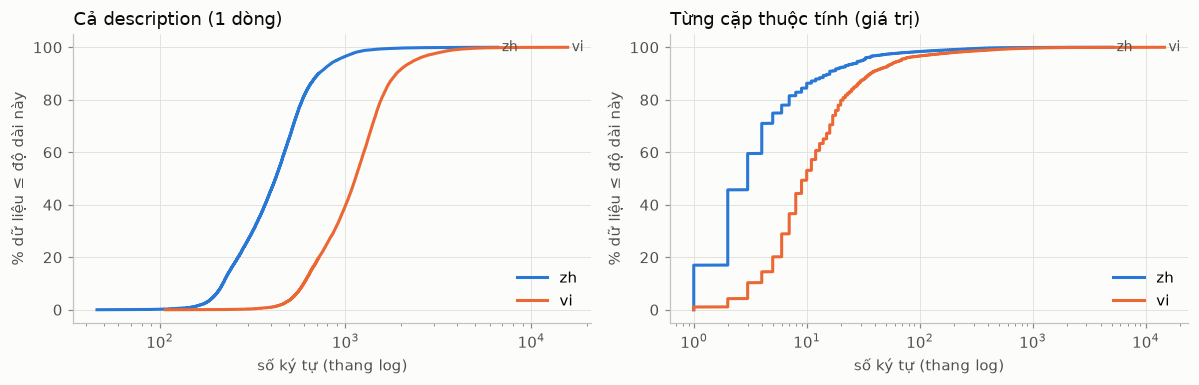

description_vi dài hơn 1.000 ký tự: 9.873 dòng (60,39%)
description_vi dài hơn 2.000 ký tự: 1.351 dòng (8,26%)
description_vi dài hơn 4.000 ký tự: 138 dòng (0,84%)


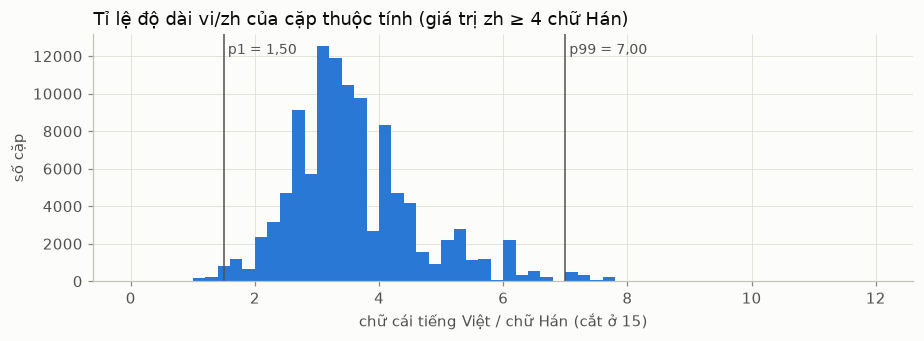

5 cặp ngắn bất thường nhất:


,loai,product_id,category,name_zh,val_zh,val_vi,ti_le
404519,qua_ngan_nghi_thieu,1029723773387,shoes,品牌,KOMANIC/柯玛妮克,Komanic,0.0
400259,qua_ngan_nghi_thieu,1007492040532,shoes,品牌,CARTELO/卡帝乐鳄鱼,CARTELO,0.0
297268,qua_ngan_nghi_thieu,1036269933259,mother_baby,品牌,Mekansm/梅肯斯姆,Mekansm,0.0
307752,qua_ngan_nghi_thieu,1067518006462,shoes,形象,WINNIE THE POOH小熊维尼,Gấu Pooh,0.0
314500,qua_ngan_nghi_thieu,979661082082,shoes,货号,零零八零128-2,0080128-2,0.0


5 cặp dài bất thường nhất:


,loai,product_id,category,name_zh,val_zh,val_vi,ti_le
380703,qua_dai_nghi_thua,1079348443536,shoes,包装体积,详询客服,Xin liên hệ bộ phận chăm sóc khách hàng để biết thêm chi tiết.,12.0
247347,qua_dai_nghi_thua,1073699664287,home,收纳容量,详询客服,Xin liên hệ bộ phận chăm sóc khách hàng để biết thêm chi tiết.2,12.0
159823,qua_dai_nghi_thua,1050055064060,home,箱装数量,详询客服,Xin liên hệ bộ phận chăm sóc khách hàng để biết thêm chi tiết.,12.0
331569,qua_dai_nghi_thua,1061822596841,shoes,包装体积,详询客服,Xin liên hệ bộ phận chăm sóc khách hàng để biết thêm chi tiết.,12.0
233917,qua_dai_nghi_thua,1005102701904,food,产品厂家厂名,详询客服,Xin liên hệ bộ phận chăm sóc khách hàng để biết thêm chi tiết.1,12.0


Đã ghi data/eda/description/desc_ti_le_do_dai_bat_thuong.csv (1.155 dòng)

KẾT LUẬN:
  - Cả description: trung vị 1.132 ký tự vi (227 âm tiết), p99 3.829 ký tự; 8,26% dòng dài hơn 2.000 ký tự.
  - Từng cặp thuộc tính: trung vị 10 ký tự vi, p99 427: rất ngắn, chủ yếu là từ/cụm từ.
  - Tỉ lệ vi/zh (giá trị ≥ 4 chữ Hán): trung vị 3,44, p1 1,50, p99 7,00. 421 cặp quá ngắn (nghi dịch thiếu), 734 cặp quá dài (nghi dịch thừa), cần đọc tay.


In [4]:
df["kt_zh"] = df.description_zh.str.len()
df["kt_vi"] = df.description_vi.str.len()
df["am_tiet_vi"] = df.description_vi.map(lambda s: len(s.split()))
df["so_gia_tri"] = df.attributes_zh.map(lambda a: sum(len(d["values"]) for d in a))
A["kt_zh"] = A.val_zh.str.len()
A["kt_vi"] = A.val_vi.str.len()
V["kt_zh"] = V.v_zh.str.len()
V["kt_vi"] = V.v_vi.str.len()


def pv(s):
    q = s.quantile([.5, .9, .99])
    return {"trung_vi": q[.5], "p90": q[.9], "p99": q[.99], "lon_nhat": s.max()}


tab = pd.DataFrame({
    "dòng: ký tự zh": pv(df.kt_zh), "dòng: ký tự vi": pv(df.kt_vi), "dòng: âm tiết vi": pv(df.am_tiet_vi),
    "dòng: số thuộc tính": pv(df.n_attributes_zh), "dòng: số giá trị": pv(df.so_gia_tri),
    "cặp thuộc tính: ký tự giá trị zh": pv(A.kt_zh), "cặp thuộc tính: ký tự giá trị vi": pv(A.kt_vi),
    "cặp giá trị: ký tự zh": pv(V.kt_zh), "cặp giá trị: ký tự vi": pv(V.kt_vi),
}).T.round(0).astype(int)
display(tab)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (title, sz, sv) in zip(axes, [("Cả description (1 dòng)", df.kt_zh, df.kt_vi),
                                      ("Từng cặp thuộc tính (giá trị)", A.kt_zh, A.kt_vi)]):
    for s, col, lab in [(sz, C1, "zh"), (sv, C2, "vi")]:
        x = np.sort(s.clip(lower=1).values)
        y = np.arange(1, len(x) + 1) / len(x) * 100
        ax.plot(x, y, color=col, linewidth=2, label=lab)
        ax.text(x[-1], 100, " " + lab, color=INK2, fontsize=9, va="center")
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("số ký tự (thang log)")
    ax.set_ylabel("% dữ liệu ≤ độ dài này")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

for L_ in [1000, 2000, 4000]:
    print(f"description_vi dài hơn {so(L_)} ký tự: {so((df.kt_vi > L_).sum())} dòng ({tl((df.kt_vi > L_).sum(), N)})")

# Tỉ lệ độ dài vi/zh, chỉ các cặp mà giá trị zh có ≥ 4 chữ Hán
mask = A.val_zh.map(lambda s: len(CJK.findall(s)) >= 4) & ~A.val_vi.map(has_cjk)
R = A[mask].copy()
# Chỉ so phần chữ dịch: (số chữ cái bản Việt − số chữ Latin đã có sẵn ở bản Trung) / số chữ Hán bản Trung.
# Số, dấu câu và chữ Latin chép nguyên (cm, tên Latin) không làm lệch tỉ lệ.
n_cjk = R.val_zh.map(lambda s: len(CJK.findall(s)))
n_lat_zh = R.val_zh.map(lambda s: len(re.findall(r"[A-Za-z]", s)))
n_chu_vi = R.val_vi_bo_so.map(lambda s: sum(ch.isalpha() for ch in s))
R["ti_le"] = (n_chu_vi - n_lat_zh).clip(lower=0) / n_cjk
q01, q50, q99 = R.ti_le.quantile([.01, .5, .99])
fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.hist(R.ti_le.clip(upper=15), bins=60, color=C1)
for q, lab in [(q01, "p1"), (q99, "p99")]:
    ax.axvline(q, color=INK2, linewidth=1)
    ax.text(q, ax.get_ylim()[1] * 0.92, f" {lab} = {sf(q, 2)}", color=INK2, fontsize=9)
ax.set_title("Tỉ lệ độ dài vi/zh của cặp thuộc tính (giá trị zh ≥ 4 chữ Hán)")
ax.set_xlabel("chữ cái tiếng Việt / chữ Hán (cắt ở 15)")
ax.set_ylabel("số cặp")
plt.tight_layout()
plt.show()

R["loai"] = np.select([R.ti_le < q01, R.ti_le > q99], ["qua_ngan_nghi_thieu", "qua_dai_nghi_thua"], "")
O = R[R.loai != ""].sort_values("ti_le")
out = O[["loai", "product_id", "category", "name_zh", "val_zh", "val_vi", "ti_le"]].copy()
out["ti_le"] = out.ti_le.round(2)
out["val_zh"] = out.val_zh.str[:300]
out["val_vi"] = out.val_vi.str[:300]
print("5 cặp ngắn bất thường nhất:")
display(out.head(5))
print("5 cặp dài bất thường nhất:")
display(out.tail(5))
ghi_csv(out, "desc_ti_le_do_dai_bat_thuong.csv")
ghi_van_de("DS04", "Nghi dịch thiếu/thừa ở cấp thuộc tính (tỉ lệ độ dài vi/zh ngoài p1–p99)", 3,
           "tỉ lệ ký tự vi/zh, cặp có ≥ 4 chữ Hán",
           {r: f"{n}: {z[:50]} | {v[:60]} (tỉ lệ {sf(t, 2)})" for r, n, z, v, t in zip(O.row, O.name_zh, O.val_zh, O.val_vi, O.ti_le)},
           so_cap=len(O))

ket_luan(
    f"Cả description: trung vị {so(df.kt_vi.median())} ký tự vi ({so(df.am_tiet_vi.median())} âm tiết), p99 {so(df.kt_vi.quantile(.99))} ký tự; "
    f"{tl((df.kt_vi > 2000).sum(), N)} dòng dài hơn 2.000 ký tự.",
    f"Từng cặp thuộc tính: trung vị {so(A.kt_vi.median())} ký tự vi, p99 {so(A.kt_vi.quantile(.99))}: rất ngắn, chủ yếu là từ/cụm từ.",
    f"Tỉ lệ vi/zh (giá trị ≥ 4 chữ Hán): trung vị {sf(q50, 2)}, p1 {sf(q01, 2)}, p99 {sf(q99, 2)}. "
    f"{so((R.loai == 'qua_ngan_nghi_thieu').sum())} cặp quá ngắn (nghi dịch thiếu), {so((R.loai == 'qua_dai_nghi_thua').sum())} cặp quá dài (nghi dịch thừa), cần đọc tay.",
)

## 4. Tên thuộc tính: độ phủ và cách dịch

**Làm gì:**
- Đếm bao nhiêu tên thuộc tính khác nhau, và bao nhiêu tên phổ biến nhất là đủ phủ phần lớn dữ liệu. Nếu vài trăm tên phủ gần hết thì dựng **từ điển tên thuộc tính** (dịch 1 lần, duyệt 1 lần) là khả thi.
- Mỗi tên tiếng Trung bị máy dịch ra bao nhiêu kiểu tiếng Việt. Tách biến thể chỉ khác chữ hoa/dấu "?" "." với biến thể khác thật.

**Đọc biểu đồ:**
- Đường độ phủ: trục ngang = số tên phổ biến nhất được lấy (thang log), trục dọc = % số lần xuất hiện được phủ.
- Bản đồ nhiệt: % sản phẩm trong mỗi category có thuộc tính đó (càng đậm càng phổ biến). Cho thấy thuộc tính nào dùng chung, thuộc tính nào riêng từng category.
- Thanh ngang: % số lần tên đó được dịch theo cách phổ biến nhất (100% = thống nhất hoàn toàn).

[OK] Tên thuộc tính zh khác nhau: 2.053
[OK] Tên thuộc tính vi khác nhau: 3.885
[OK] Tên zh chỉ xuất hiện 1 lần: 1.006


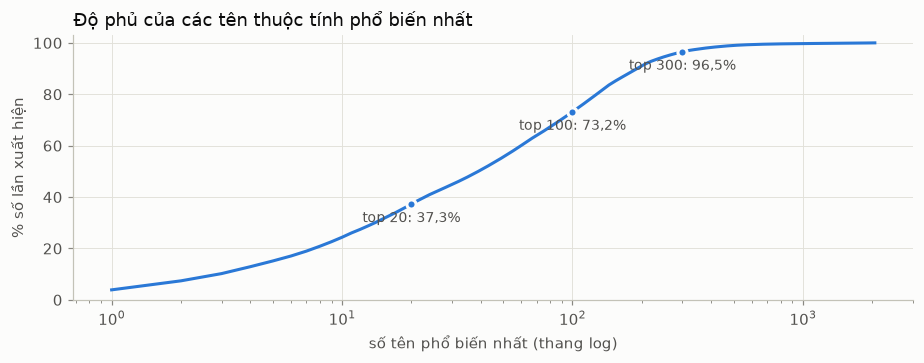

Số tên thuộc tính khác nhau theo category:


category,fashion,electronics,shoes,bags,beauty,mother_baby,food,home,auto
so_ten_zh,209,259,235,366,248,370,291,422,393


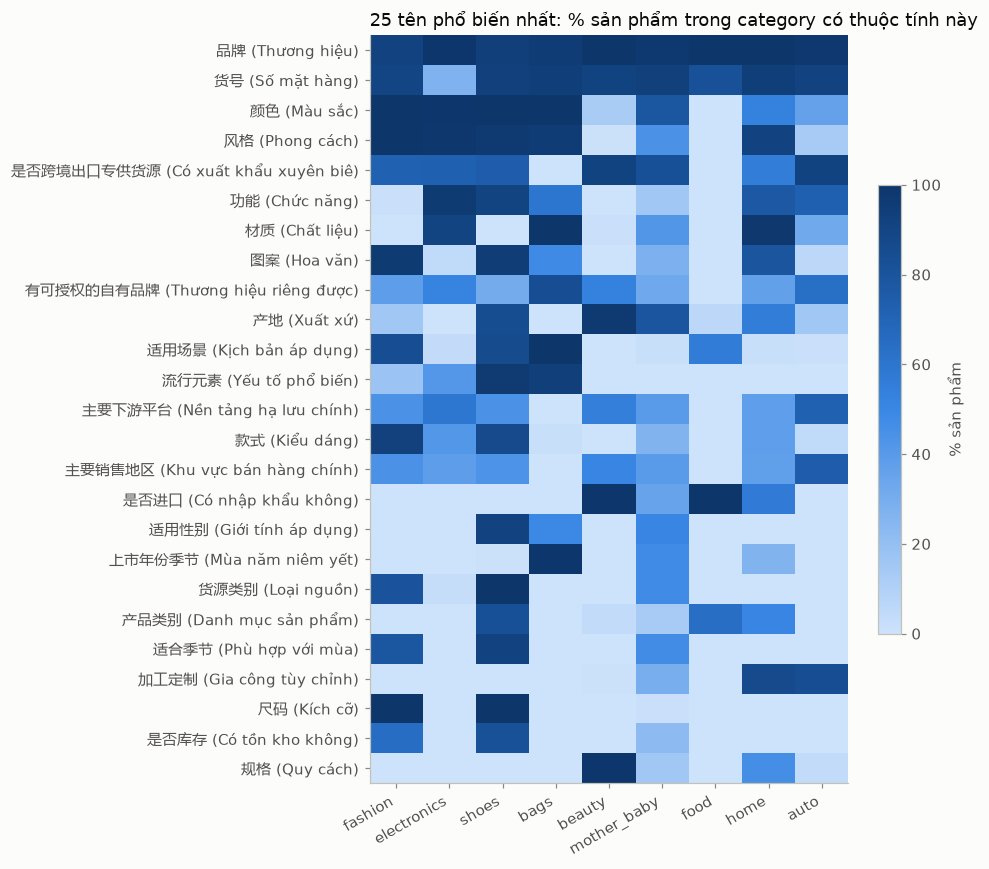

Bảng số của bản đồ nhiệt (%):


category,fashion,electronics,shoes,bags,beauty,mother_baby,food,home,auto
name_zh,,,,,,,,,
品牌,91,99,94,95,100,97,100,99,98
货号,89,27,93,94,91,93,82,94,91
颜色,100,99,100,100,13,79,0,53,36
风格,99,99,97,95,1,44,0,92,13
是否跨境出口专供货源,72,72,74,0,91,82,0,55,91
功能,1,96,90,59,0,15,0,77,73
材质,0,90,0,100,1,42,0,98,32
图案,96,5,95,48,0,28,0,80,6
有可授权的自有品牌,38,52,31,84,53,32,0,37,63


[OK] Tên zh có > 1 cách dịch: 866
[OK] ... sau khi bỏ khác biệt chữ hoa / dấu ? . :: 834
Đã ghi data/eda/description/desc_ten_thuoc_tinh_cach_dich.csv (2.052 dòng)
15 tên phổ biến nhất và các cách dịch:


,so_cap,so_cach_dich_sau_chuan_hoa,pct_cach_pho_bien_nhat,cac_cach_dich
name_zh,,,,
品牌,15834,2,99.5,Thương hiệu: 10355; thương hiệu: 5395; 品牌: 84
货号,14295,8,54.9,Số mặt hàng: 7165; Mã sản phẩm: 3214; Mã hàng: 3093; số mặt hàng: 679; 货号: 130; Mã số ...
颜色,11447,5,99.7,Màu sắc: 7805; màu sắc: 3607; 颜色: 28; màu: 5; Mẫu mã: 1; Số tạp chí: 1
风格,10945,2,99.8,Phong cách: 7305; phong cách: 3620; 风格: 20
是否跨境出口专供货源,9001,24,48.6,Có xuất khẩu xuyên biên giới dành riêng cho nguồn hàng không: 4378; Có phải là nguồn h...
功能,7892,2,99.7,Chức năng: 7164; chức năng: 708; 功能: 20
材质,7714,3,65.6,Chất liệu: 5059; vật liệu: 1543; Vật liệu: 1034; 材质: 78
图案,7686,5,43.6,Hoa văn: 3351; Họa tiết: 2084; mẫu: 1128; Mẫu: 982; mô hình: 135; 图案: 6
有可授权的自有品牌,7261,7,51.3,Thương hiệu riêng được ủy quyền: 3724; Có thương hiệu riêng được ủy quyền.: 1156; Có t...


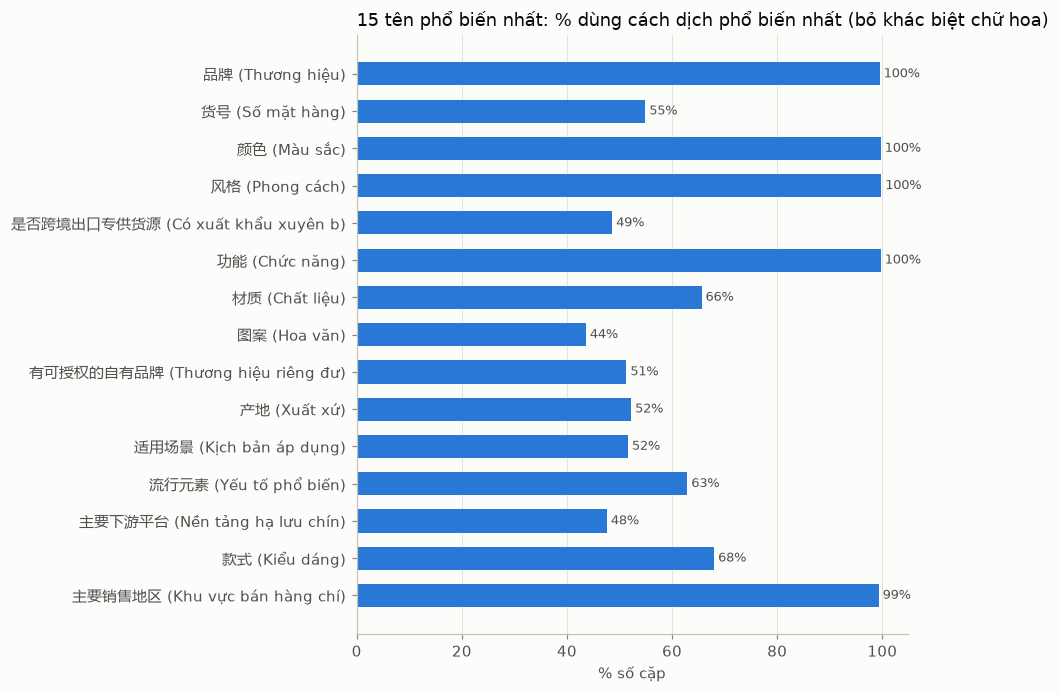

Tên tiếng Việt còn nguyên chữ Hán (máy chưa dịch tên), nhiều nhất:


,so_cap
name_zh,
货号,130
是否IP授权,119
产地,96
款式,96
材质成分,89
品牌,84
材质,78
床品规格标准,71
使用场景,61



KẾT LUẬN:
  - 2.053 tên zh nhưng 3.885 tên vi; 1.006 tên zh chỉ gặp 1 lần.
  - Top 100 tên phủ 73,2%, top 300 phủ 96,5% số lần xuất hiện → từ điển ~300 tên là đủ dùng.
  - 834 tên dịch nhiều kiểu thật (không tính khác chữ hoa); trong 100 tên phổ biến nhất có 99 tên như vậy.
  - 14.005 dòng (85,67%) có ít nhất 1 tên dịch theo cách thiểu số; 4.717 cặp có tên tiếng Việt còn nguyên chữ Hán.


In [5]:
names_zh_all = Counter(d["name"] for a in df.attributes_zh for d in a)
names_vi_all = Counter(d["name"] for a in df.attributes_vi for d in a)
check("Tên thuộc tính zh khác nhau", len(names_zh_all), 2053)
check("Tên thuộc tính vi khác nhau", len(names_vi_all), 3885)
check("Tên zh chỉ xuất hiện 1 lần", sum(v == 1 for v in names_zh_all.values()), 1006)

freq = A.name_zh.value_counts()
cum = freq.cumsum() / freq.sum() * 100
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(np.arange(1, len(cum) + 1), cum.values, color=C1, linewidth=2)
for k in [20, 100, 300]:
    ax.plot(k, cum.iloc[k - 1], "o", color=C1, markersize=6, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.text(k, cum.iloc[k - 1] - 7, f"top {k}: {sf(cum.iloc[k - 1], 1)}%", color=INK2, fontsize=9, ha="center")
ax.set_xscale("log")
ax.set_ylim(0, 103)
ax.set_title("Độ phủ của các tên thuộc tính phổ biến nhất")
ax.set_xlabel("số tên phổ biến nhất (thang log)")
ax.set_ylabel("% số lần xuất hiện")
plt.tight_layout()
plt.show()

print("Số tên thuộc tính khác nhau theo category:")
display(A.groupby("category").name_zh.nunique().reindex(CATS).rename("so_ten_zh").to_frame().T)

top_vi = A.groupby("name_zh").name_vi.agg(lambda s: s.value_counts().index[0])
top25 = freq.head(25).index
pres = A.drop_duplicates(["row", "name_zh"]).groupby(["name_zh", "category"]).size().unstack(fill_value=0)
share = (pres.loc[top25].reindex(columns=CATS, fill_value=0) / df.category.value_counts().reindex(CATS).values * 100)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(share.values, cmap=SEQ, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(CATS)), CATS, rotation=30, ha="right")
ax.set_yticks(range(len(top25)), [f"{n} ({top_vi[n][:22]})" for n in top25])
ax.set_title("25 tên phổ biến nhất: % sản phẩm trong category có thuộc tính này")
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.6, label="% sản phẩm")
plt.tight_layout()
plt.show()
print("Bảng số của bản đồ nhiệt (%):")
display(share.round(0).astype(int))


def norm_name(s):
    return s.lower().strip(" ?.:？")


g = A.groupby("name_zh")
var = pd.DataFrame({
    "so_cap": g.size(),
    "so_san_pham": g.row.nunique(),
    "so_cach_dich": g.name_vi.nunique(),
    "so_cach_dich_sau_chuan_hoa": g.name_vi.agg(lambda s: s.map(norm_name).nunique()),
    "pct_cach_pho_bien_nhat": g.name_vi.agg(lambda s: round(100 * s.map(norm_name).value_counts().iloc[0] / len(s), 1)),
    "cac_cach_dich": g.name_vi.agg(lambda s: "; ".join(f"{k}: {v}" for k, v in s.value_counts().head(6).items())),
}).sort_values("so_cap", ascending=False)
check("Tên zh có > 1 cách dịch", (var.so_cach_dich > 1).sum(), 866)
check("... sau khi bỏ khác biệt chữ hoa / dấu ? . :", (var.so_cach_dich_sau_chuan_hoa > 1).sum(), 834)
top100_multi = int((var.head(100).so_cach_dich_sau_chuan_hoa > 1).sum())
out = var.reset_index().rename(columns={"name_zh": "ten_zh"})
out.insert(1, "ten_vi_pho_bien", out.ten_zh.map(top_vi))
ghi_csv(out, "desc_ten_thuoc_tinh_cach_dich.csv")
print("15 tên phổ biến nhất và các cách dịch:")
display(var.head(15)[["so_cap", "so_cach_dich_sau_chuan_hoa", "pct_cach_pho_bien_nhat", "cac_cach_dich"]])
t15 = var.head(15)
bar_h([f"{n} ({top_vi[n][:20]})" for n in t15.index], t15.pct_cach_pho_bien_nhat,
      "15 tên phổ biến nhất: % dùng cách dịch phổ biến nhất (bỏ khác biệt chữ hoa)", "% số cặp", fmt_val=lambda v: f"{v:.0f}%")

# Dòng dùng cách dịch thiểu số (chỉ xét tên có ≥ 20 cặp)
A["name_vi_norm"] = A.name_vi.map(norm_name)
maj = A.groupby("name_zh").name_vi_norm.agg(lambda s: s.value_counts().index[0])
cnt = A.name_zh.map(freq)
minor = A[(cnt >= 20) & (A.name_vi_norm != A.name_zh.map(maj))]
ghi_van_de("DS05", "Tên thuộc tính dịch không thống nhất (dòng dùng cách dịch thiểu số)", 2,
           "so name_vi với cách dịch phổ biến nhất của cùng name_zh (tên có ≥ 20 cặp)",
           {r: f"{z} → {v} (phổ biến: {maj[z]})" for r, z, v in zip(minor.row[::-1], minor.name_zh[::-1], minor.name_vi[::-1])},
           so_cap=len(minor))

cjk_name = A[A.name_vi.map(has_cjk)]
print("Tên tiếng Việt còn nguyên chữ Hán (máy chưa dịch tên), nhiều nhất:")
display(cjk_name.name_zh.value_counts().head(10).rename("so_cap").to_frame())

ket_luan(
    f"{so(len(names_zh_all))} tên zh nhưng {so(len(names_vi_all))} tên vi; {so(sum(v == 1 for v in names_zh_all.values()))} tên zh chỉ gặp 1 lần.",
    f"Top 100 tên phủ {sf(cum.iloc[99], 1)}%, top 300 phủ {sf(cum.iloc[299], 1)}% số lần xuất hiện → từ điển ~300 tên là đủ dùng.",
    f"{so((var.so_cach_dich_sau_chuan_hoa > 1).sum())} tên dịch nhiều kiểu thật (không tính khác chữ hoa); trong 100 tên phổ biến nhất có {top100_multi} tên như vậy.",
    f"{so(minor.row.nunique())} dòng ({tl(minor.row.nunique(), N)}) có ít nhất 1 tên dịch theo cách thiểu số; {so(len(cjk_name))} cặp có tên tiếng Việt còn nguyên chữ Hán.",
)

## 5. Vai trò thuộc tính (gợi ý để anh duyệt)

**Vì sao:** không phải thuộc tính nào cũng là mô tả hàng. Nhiều thuộc tính là **thông tin giao dịch của 1688** (có xuất khẩu chuyên biệt không, nền tảng hạ lưu, khu vực bán, nguồn hàng...), giá trị lặp gần y hệt ở hàng nghìn sản phẩm, ít giúp mô hình học dịch hàng hoá.

**Cách gợi ý (luật, chưa phải kết luận):** tên khớp từ khoá giao dịch → `giao_dich_1688`; mã/số giấy tờ → `ma_giay_to`; `品牌` → `thuong_hieu`; trung vị ≥ 3 giá trị → `lua_chon_sku` (màu, size...); còn lại → `mo_ta_hang` (mặc định). Cột `cach_goi_y` ghi rõ gợi ý đến từ luật nào.

**Anh duyệt:** file `desc_vai_tro_thuoc_tinh_editted.csv` (300 tên phổ biến nhất, phủ ~96% số lần xuất hiện), điền `anh_duyet` (giữ hoặc sửa vai trò) và `anh_ghi_chu`. Tỉ lệ bên dưới chỉ là **gợi ý**, chưa dùng để báo cáo.

Đã ghi data/eda/description/desc_vai_tro_thuoc_tinh_editted.csv (300 dòng)
Tỉ lệ cặp thuộc tính theo vai trò GỢI Ý (chưa duyệt):


,so_cap,pct
vai_tro_goi_y,,
mo_ta_hang,265263,65.2
giao_dich_1688,79170,19.5
lua_chon_sku,25101,6.2
ma_giay_to,21503,5.3
thuong_hieu,15834,3.9


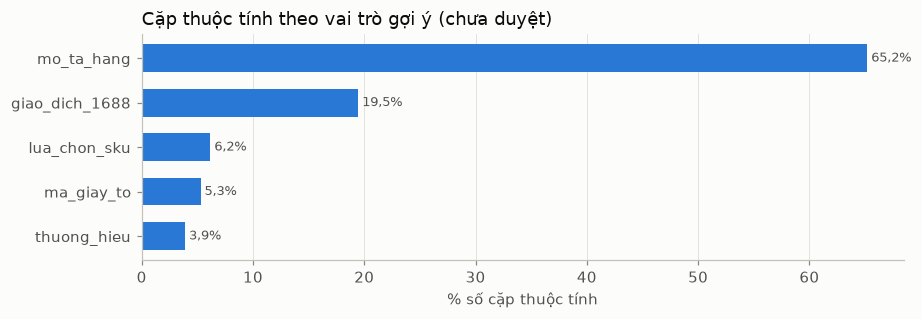

Các tên được gợi ý là giao_dich_1688 trong top 300:


,ten_zh,ten_vi_pho_bien,so_cap,gia_tri_zh_pho_bien
4,是否跨境出口专供货源,Có xuất khẩu xuyên biên giới dành riêng cho nguồn hàng không,9001,是 | 否
8,有可授权的自有品牌,Thương hiệu riêng được ủy quyền,7261,是 | 否 | 其他
12,主要下游平台,Nền tảng hạ lưu chính,5614,"ebay, 亚马逊, wish, 速卖通, 独立站, LAZADA | ebay, 亚马逊, wish, 速卖通, 独立站, LAZADA, 其他 | 其他"
14,主要销售地区,Khu vực bán hàng chính,5320,"非洲, 欧洲, 南美, 东南亚, 北美, 东北亚, 中东 | 非洲, 欧洲, 南美, 东南亚, 北美, 东北亚, 中东, 其他 | 其他"
15,是否进口,Có nhập khẩu không,5023,否 | 国产 | 是
18,货源类别,Loại nguồn,4614,现货 | 订货 | 现货+订货
21,加工定制,Gia công tùy chỉnh,3709,是 | 否 | 可以
23,是否库存,Có tồn kho không,3342,是 | 否 | 其他
29,是否IP授权,Ủy quyền IP: Có hay Không?,2420,否 | 是 | 其他
30,库存类型,Loại hàng tồn kho,2403,整单 | 杂款 | 其他



KẾT LUẬN:
  - Theo gợi ý (chưa duyệt): giao_dich_1688 chiếm 19,5% số cặp, ma_giay_to 5,3%, thuong_hieu 3,9%, lua_chon_sku 6,2%, mo_ta_hang 65,2%.
  - Con số chỉ chính thức sau khi anh duyệt desc_vai_tro_thuoc_tinh_editted.csv (vd tên '是否…' có thể là đặc điểm hàng như 是否连帽 = có mũ không).


In [6]:
ROLE_RULES = [
    ("giao_dich_1688", re.compile(r"跨境|下游平台|销售地区|货源|加工定制|库存|IP授权|专利|外贸|代发|发货|出货|自有品牌|是否进口|贸易属性|纳税人|价格段|淘货|加印|订制|定制|箱装数量|质检|AQL|产品认证|图片实拍|起批|起订")),
    ("ma_giay_to", re.compile(r"货号|^型号$|编号|条码|条形码|许可证|备案|标准号|批准文号|注册证")),
    ("thuong_hieu", re.compile(r"^品牌$")),
]
med_vals = A.groupby("name_zh").n_vals_zh.median()


def goi_y_vai_tro(name):
    for role, rx in ROLE_RULES:
        if rx.search(name):
            return role, f"luật: khớp '{rx.search(name).group()}'"
    if med_vals.get(name, 1) >= 3:
        return "lua_chon_sku", "luật: trung vị ≥ 3 giá trị"
    return "mo_ta_hang", "mặc định (không khớp luật nào)"


roles = {n: goi_y_vai_tro(n) for n in freq.index}
A["vai_tro_goi_y"] = A.name_zh.map(lambda n: roles[n][0])

top300 = freq.head(300).index
tab = pd.DataFrame({
    "ten_zh": top300,
    "so_cap": freq[top300].values,
    "so_san_pham": var.loc[top300, "so_san_pham"].values,
    "ten_vi_pho_bien": [top_vi[n] for n in top300],
    "tv_so_gia_tri": [med_vals[n] for n in top300],
    "gia_tri_zh_pho_bien": [" | ".join(A.loc[A.name_zh == n, "val_zh"].value_counts().index[:3])[:80] for n in top300],
    "vai_tro_goi_y": [roles[n][0] for n in top300],
    "cach_goi_y": [roles[n][1] for n in top300],
    "anh_duyet": "", "anh_ghi_chu": "",
})
ghi_csv(tab, "desc_vai_tro_thuoc_tinh_editted.csv")

share_role = A.vai_tro_goi_y.value_counts()
print("Tỉ lệ cặp thuộc tính theo vai trò GỢI Ý (chưa duyệt):")
display(pd.DataFrame({"so_cap": share_role, "pct": (share_role / len(A) * 100).round(1)}))
bar_h(share_role.index, share_role.values / len(A) * 100, "Cặp thuộc tính theo vai trò gợi ý (chưa duyệt)",
      "% số cặp thuộc tính", fmt_val=lambda v: f"{sf(v, 1)}%")
print("Các tên được gợi ý là giao_dich_1688 trong top 300:")
display(tab[tab.vai_tro_goi_y == "giao_dich_1688"][["ten_zh", "ten_vi_pho_bien", "so_cap", "gia_tri_zh_pho_bien"]])

ket_luan(
    f"Theo gợi ý (chưa duyệt): giao_dich_1688 chiếm {sf(share_role.get('giao_dich_1688', 0) / len(A) * 100, 1)}% số cặp, "
    f"ma_giay_to {sf(share_role.get('ma_giay_to', 0) / len(A) * 100, 1)}%, thuong_hieu {sf(share_role.get('thuong_hieu', 0) / len(A) * 100, 1)}%, "
    f"lua_chon_sku {sf(share_role.get('lua_chon_sku', 0) / len(A) * 100, 1)}%, mo_ta_hang {sf(share_role.get('mo_ta_hang', 0) / len(A) * 100, 1)}%.",
    "Con số chỉ chính thức sau khi anh duyệt desc_vai_tro_thuoc_tinh_editted.csv (vd tên '是否…' có thể là đặc điểm hàng như 是否连帽 = có mũ không).",
)

## 6. Giá trị thuộc tính: kiểu giá trị và kích thước thật

**Làm gì:**
- Số giá trị trong 1 thuộc tính (đa số chỉ 1, nhưng danh sách màu/size có thể rất dài).
- Phân loại cặp theo **kiểu giá trị** (theo bản Trung): `nhieu_gia_tri` (danh sách), `co_khong_khac` (是/否/有/无/其他...), `so_don_vi` (số + đơn vị), `ma_latin_so` (không có chữ Hán: mã, tên Latin), `chu_tu_do` (cụm chữ Hán). Mỗi kiểu khó dịch khác nhau.
- **Kích thước thật**: bao nhiêu cặp (zh, vi) khác nhau. Dữ liệu lặp nhiều thì số cặp "danh nghĩa" lớn hơn nhiều so với lượng thông tin thật.
- Cách dịch của các giá trị có/không phổ biến (是, 否, 其他...).

**Đọc biểu đồ Pareto:** trục ngang = số cặp (zh, vi) khác nhau lấy theo thứ tự phổ biến (thang log), trục dọc = % số lần xuất hiện được phủ. Đường dựng đứng sớm = dữ liệu lặp nhiều.

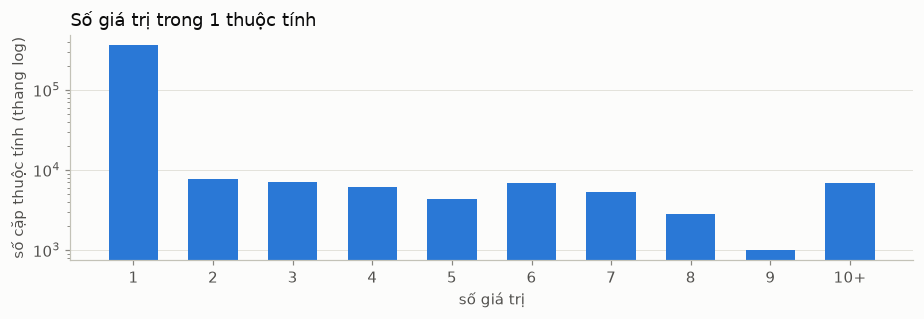

Thuộc tính chỉ 1 giá trị: 88,20%; nhiều nhất 328 giá trị trong 1 thuộc tính.
Kiểu giá trị (pct_chep_nguyen = % cặp mà bản Việt giống hệt bản Trung):


,so_cap,pct_chep_nguyen,pct,so_cap_zh_vi_khac_nhau
kieu_gia_tri,,,,
chu_tu_do,234889,1.3,57.7,29634
co_khong_khac,69430,0.9,17.1,255
nhieu_gia_tri,48027,8.5,11.8,26801
so_don_vi,33004,67.2,8.1,7469
ma_latin_so,21521,77.2,5.3,8233


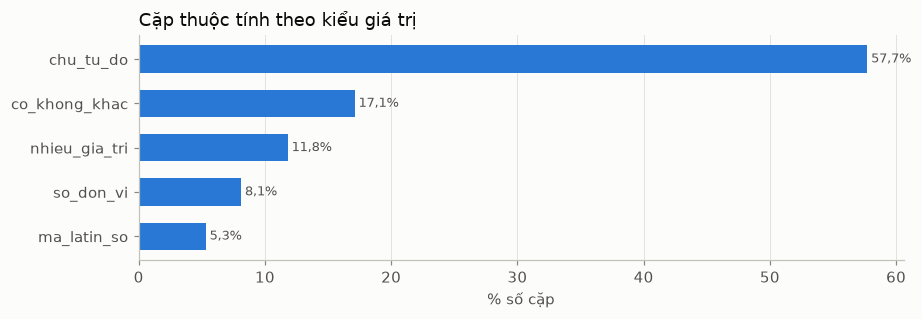

[OK] Cặp (giá trị zh, giá trị vi) khác nhau: 72.392


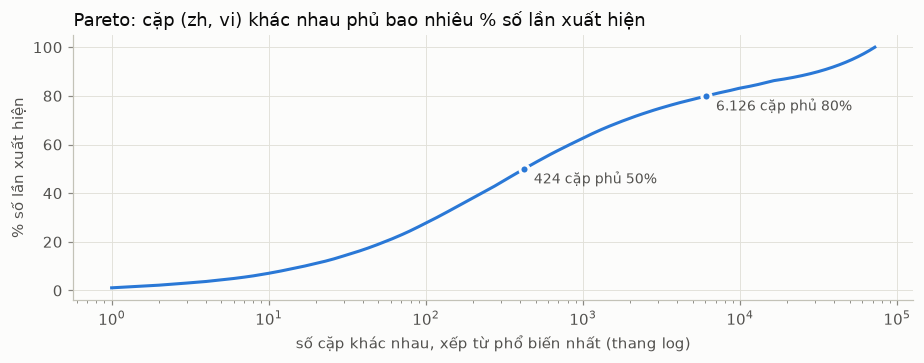

20 cặp (zh, vi) lặp nhiều nhất:


,val_zh,val_vi,so_lan
0,否,Không.1,4438
1,否,Không.2,4423
2,纯色,Màu trơn,3517
3,是,Là1,2690
4,是,Là2,2689
5,是,Là,2314
6,否,Không.3,2258
7,否,Không2,2158
8,否,Không1,2155
9,其他,Khác,2111


Cách dịch các giá trị có/không phổ biến:


,gia_tri_zh,so_cap,so_cach_dich,8_cach_pho_bien
0,是,19048,54,Là1: 2690; Là2: 2689; Là: 2314; Đúng vậy2: 1263; Đúng vậy1: 1263; Là3: 984; Đúng vậy: ...
1,否,30459,53,Không.1: 4438; Không.2: 4423; Không.3: 2258; Không2: 2158; Không1: 2155; Không.: 1934;...
2,其他,9048,35,Khác: 2111; Khác1: 1871; Khác2: 1534; Khác3: 768; Khác4: 483; khác: 470; khác1: 414; k...
3,无,4591,22,Không có: 1702; không có gì: 706; Không có1: 579; Không có2: 570; không có gì2: 235; k...
4,有,812,8,Có: 499; Đúng.: 150; có: 131; Đúng.1: 13; 有: 11; Đúng.2: 4; có2: 3; Có1: 1



KẾT LUẬN:
  - 406.871 cặp thuộc tính nhưng chỉ 72.392 cặp (zh, vi) khác nhau; 424 cặp phổ biến nhất đã phủ 50%, 6.126 cặp phủ 80%.
  - 20 cặp lặp nhiều nhất chiếm 11,1% số cặp: dữ liệu lặp rất nhiều, kích thước thật nhỏ hơn nhiều so với con số danh nghĩa.
  - 11,4% cặp có bản Việt giống hệt bản Trung (chủ yếu kiểu ma_latin_so: mã hàng, tên Latin).
  - Giá trị 是/否 bị dịch nhiều kiểu, kể cả kiểu có số đuôi (block 8).


In [7]:
nv_cap = A.n_vals_zh.clip(upper=10)
dist = nv_cap.value_counts().sort_index()
labels = [str(k) if k < 10 else "10+" for k in dist.index]
fig, ax = plt.subplots(figsize=(8.5, 3))
ax.bar(labels, dist.values, color=C1, width=0.62)
ax.set_yscale("log")
ax.set_title("Số giá trị trong 1 thuộc tính")
ax.set_xlabel("số giá trị")
ax.set_ylabel("số cặp thuộc tính (thang log)")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()
print(f"Thuộc tính chỉ 1 giá trị: {tl((A.n_vals_zh == 1).sum(), len(A))}; nhiều nhất {so(A.n_vals_zh.max())} giá trị trong 1 thuộc tính.")

YESNO = {"是", "否", "有", "无", "其他", "其它", "没有", "可以", "不可以", "不是", "非"}
UNIT_WORDS = re.compile(r"英寸|寸|厘米|毫米|千克|公斤|毫升|周岁|个月|小时|分钟|cm|mm|kg|ml|mah|米|克|斤|升|个|只|件|片|码|岁|月|天|年|元|度|℃|g|l|m|w|v|%", re.I)


def is_num_unit(s):
    return bool(re.search(r"\d", s)) and not re.sub(r"[\d\s.,\-~～/*xX×+()（）:：]", "", UNIT_WORDS.sub("", s))


def kieu_gia_tri(n, z):
    if n > 1:
        return "nhieu_gia_tri"
    if z in YESNO:
        return "co_khong_khac"
    if is_num_unit(z):
        return "so_don_vi"
    if not has_cjk(z):
        return "ma_latin_so"
    return "chu_tu_do"


A["kieu_gia_tri"] = [kieu_gia_tri(n, z) for n, z in zip(A.n_vals_zh, A.val_zh)]
A["chep_nguyen"] = A.val_zh == A.val_vi
kt = A.groupby("kieu_gia_tri").agg(so_cap=("row", "size"), pct_chep_nguyen=("chep_nguyen", lambda s: round(100 * s.mean(), 1)))
kt["pct"] = (kt.so_cap / len(A) * 100).round(1)
kt["so_cap_zh_vi_khac_nhau"] = A.groupby("kieu_gia_tri").apply(lambda x: len(x[["val_zh", "val_vi"]].drop_duplicates()))
kt = kt.sort_values("so_cap", ascending=False)
print("Kiểu giá trị (pct_chep_nguyen = % cặp mà bản Việt giống hệt bản Trung):")
display(kt)
bar_h(kt.index, kt.pct, "Cặp thuộc tính theo kiểu giá trị", "% số cặp", fmt_val=lambda v: f"{sf(v, 1)}%")

uniq = A.groupby(["val_zh", "val_vi"]).size().sort_values(ascending=False)
check("Cặp (giá trị zh, giá trị vi) khác nhau", len(uniq), 72392)
cumu = uniq.cumsum() / uniq.sum() * 100
k50 = int((cumu < 50).sum()) + 1
k80 = int((cumu < 80).sum()) + 1
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(np.arange(1, len(cumu) + 1), cumu.values, color=C1, linewidth=2)
for k, lab in [(k50, "50%"), (k80, "80%")]:
    ax.plot(k, cumu.iloc[k - 1], "o", color=C1, markersize=6, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.text(k * 1.15, cumu.iloc[k - 1] - 6, f"{so(k)} cặp phủ {lab}", color=INK2, fontsize=9)
ax.set_xscale("log")
ax.set_title("Pareto: cặp (zh, vi) khác nhau phủ bao nhiêu % số lần xuất hiện")
ax.set_xlabel("số cặp khác nhau, xếp từ phổ biến nhất (thang log)")
ax.set_ylabel("% số lần xuất hiện")
plt.tight_layout()
plt.show()
print("20 cặp (zh, vi) lặp nhiều nhất:")
display(uniq.head(20).rename("so_lan").reset_index())

rows = []
for z in ["是", "否", "其他", "无", "有"]:
    s = A.loc[A.val_zh == z, "val_vi"].value_counts()
    rows.append({"gia_tri_zh": z, "so_cap": int(s.sum()), "so_cach_dich": len(s),
                 "8_cach_pho_bien": "; ".join(f"{k}: {v}" for k, v in s.head(8).items())})
print("Cách dịch các giá trị có/không phổ biến:")
display(pd.DataFrame(rows))

ket_luan(
    f"{so(len(A))} cặp thuộc tính nhưng chỉ {so(len(uniq))} cặp (zh, vi) khác nhau; {so(k50)} cặp phổ biến nhất đã phủ 50%, {so(k80)} cặp phủ 80%.",
    f"20 cặp lặp nhiều nhất chiếm {sf(uniq.head(20).sum() / len(A) * 100, 1)}% số cặp: dữ liệu lặp rất nhiều, kích thước thật nhỏ hơn nhiều so với con số danh nghĩa.",
    f"{tl(A.chep_nguyen.sum(), len(A), 1)} cặp có bản Việt giống hệt bản Trung (chủ yếu kiểu ma_latin_so: mã hàng, tên Latin).",
    "Giá trị 是/否 bị dịch nhiều kiểu, kể cả kiểu có số đuôi (block 8).",
)

## 7. Tên hãng (品牌)

**Chuẩn đã chốt (01/10):** tên hãng ra **pinyin** là đúng; **dịch nghĩa** hoặc **để nguyên chữ Hán** là lỗi; **Hán Việt** chưa chốt.

**Giới hạn:** máy không tách được "Hán Việt" (方靖 → "Phương Tĩnh") với "dịch nghĩa" (悍狮 → "Sư tử khổng lồ") vì cả hai đều là tiếng Việt có dấu. Notebook gộp 2 loại vào nhóm `tieng_viet_co_dau` và xuất 200 mẫu để anh đọc.

**Phân loại:**
- `khong_co_ten_hang`: 其他, 无, 中性...
- `latin_giu_nguyen`: hãng viết Latin, giữ nguyên.
- `latin_bi_doi`: hãng Latin bị máy sửa.
- `con_chu_han`: bản Việt còn chữ Hán.
- `pinyin_dung`: chữ Latin không dấu, khớp pinyin của tên Trung (dò bằng `pypinyin`).
- `latin_khac`: chữ Latin không dấu nhưng không khớp pinyin: máy tự đặt tên (柏尼士 → "Perniz") hoặc tiếng Việt tình cờ không dấu (安徽青柠檬 → "Chanh xanh An Huy").
- `tieng_viet_co_dau`: Hán Việt hoặc dịch nghĩa.

[OK] Cặp 品牌 có chữ Hán ở bản Trung: 13.952
Phân loại tên hãng (so_cap = số cặp; vi_du = 4 cặp khác nhau):


,so_cap,pct,vi_du
loai,,,
khong_co_ten_hang,5936,37.5,other/其他 → Khác/khác; 其他 → khác1; 其他 → Khác; 暂无 → Không
tieng_viet_co_dau,5766,36.4,羽岑 → Vũ Cen; 和洁士 → Và Jie Shi; 尚浮 → Vẫn còn; 浦迈 → Phổ Mai
pinyin_dung,1375,8.7,荣善 → Rongshan; 璀达 → Cui Da; 鑫瑾 → Xin Jin; 启旺 → Qiwang
latin_giu_nguyen,1319,8.3,santigo → santigo; KNS → KNS; CHONGTENG → CHONGTENG; haomaida → haomaida
latin_khac,1168,7.4,柏尼士 → Perniz; 登驿诺 → Dengnuo; 安徽青柠檬 → Chanh xanh An Huy; 车益捷 → Xe Yijie
latin_bi_doi,221,1.4,LY → LÝ; elebest → tốt nhất; OEM ODM → OEMODM; OEMODM → OEM ODM
con_chu_han,49,0.3,驰航 → 驰航; 驰誉 → 驰誉; 维禹派 → 维禹派; 麦哲龙 → 麦哲龙


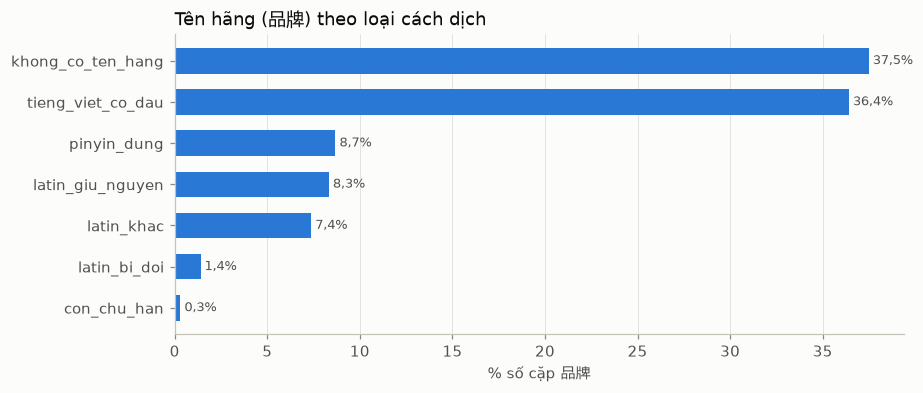

Giá trị 品牌 dài bất thường (> 15 ký tự, có chữ Hán, thường là nguyên tiêu đề): 82 cặp. Ví dụ:


,product_id,val_zh,val_vi
451,630875391471,旋转式挂钩、一件代发、天猫爆款、2019新款挂钩、卡通挂钩、工厂直批、车上座椅挂钩、便利小挂钩,"Móc xoay, giao một chiếc, mẫu hot Tmall, móc mới 2019, móc hoạt hình, hàng loạt trực t..."
550,933907999446,汽车通用型、网兜两座、椅间网兜、双层储物网、储物袋、收纳袋、多功能置物袋、隔离网兜、座椅间、椅背网、,"Loại phổ thông cho ô tô, túi lưới hai chỗ ngồi, túi lưới giữa ghế, lưới đựng đồ hai lớ..."
3194,630745844482,多功能、键盘清洁软胶、去尘胶、空调出风口、汽车除尘泥、多用途、蜗牛么么、家车两用、一件代发,"Đa chức năng, cao su mềm làm sạch bàn phím, cao su khử bụi, cửa gió điều hòa, bùn bụi ..."


anh_duyet điền: HAN_VIET / DICH_NGHIA / KHAC
Đã ghi data/eda/description/desc_ten_hang_mau_editted.csv (200 dòng)

KẾT LUẬN:
  - 15.834 cặp 品牌; khong_co_ten_hang 37,5%, tieng_viet_co_dau 36,4%, pinyin_dung 8,7%, latin_giu_nguyen 8,3%, latin_khac 7,4%, latin_bi_doi 1,4%, con_chu_han 0,3%.
  - Nhóm tieng_viet_co_dau (5.766 cặp, 3.143 cặp khác nhau) cần anh đọc mẫu để tách Hán Việt với dịch nghĩa.
  - pinyin_dung chỉ đúng khi pypinyin đọc đúng âm (chữ đa âm có thể làm lệch).


In [8]:
from pypinyin import lazy_pinyin

B = A[A.name_zh == "品牌"].copy()
check("Cặp 品牌 có chữ Hán ở bản Trung", B.val_zh.map(has_cjk).sum(), 13952)
PLACE = re.compile(r"^\s*((其他|其它|无|中性|无品牌|暂无|见包装|无牌|没有|OEM|other|others|none|null|no|/|-+)\s*[/、,]?\s*)+$", re.I)


def only_letters(s):
    return re.sub(r"[^a-z]", "", s.lower())


def loai_ten_hang(z, v):
    if PLACE.match(z):
        return "khong_co_ten_hang"
    if not has_cjk(z):
        return "latin_giu_nguyen" if v.strip() == z.strip() else "latin_bi_doi"
    if has_cjk(v):
        return "con_chu_han"
    if VI_DAU.search(v):
        return "tieng_viet_co_dau"
    py = only_letters("".join(lazy_pinyin(re.sub(r"[^\u4e00-\u9fff]", "", z))))
    return "pinyin_dung" if py and py in only_letters(v) else "latin_khac"


B["loai"] = [loai_ten_hang(z, v) for z, v in zip(B.val_zh, B.val_vi_bo_so)]   # bản Việt đã bỏ số đuôi (block 2)
B["gia_tri_dai_bat_thuong"] = B.val_zh.map(lambda s: has_cjk(s) and len(s) > 15)
lt = B.loai.value_counts()
ex = B.groupby("loai").apply(lambda x: "; ".join(f"{z} → {v}" for z, v in x[["val_zh", "val_vi"]].drop_duplicates().head(4).values))
print("Phân loại tên hãng (so_cap = số cặp; vi_du = 4 cặp khác nhau):")
display(pd.DataFrame({"so_cap": lt, "pct": (lt / len(B) * 100).round(1), "vi_du": ex.reindex(lt.index).str[:160]}))
bar_h(lt.index, lt.values / len(B) * 100, "Tên hãng (品牌) theo loại cách dịch", "% số cặp 品牌", fmt_val=lambda v: f"{sf(v, 1)}%")
print(f"Giá trị 品牌 dài bất thường (> 15 ký tự, có chữ Hán, thường là nguyên tiêu đề): {so(B.gia_tri_dai_bat_thuong.sum())} cặp. Ví dụ:")
display(B.loc[B.gia_tri_dai_bat_thuong, ["product_id", "val_zh", "val_vi"]].head(3))

tv = B[B.loai == "tieng_viet_co_dau"]
mau = (tv.groupby(["val_zh", "val_vi"])
         .agg(so_lan=("row", "size"), product_id_vi_du=("product_id", "first"), category=("category", "first"))
         .reset_index())
mau = mau.sample(min(200, len(mau)), random_state=SEED).sort_values("so_lan", ascending=False)
mau = mau.rename(columns={"val_zh": "ten_hang_zh", "val_vi": "ten_hang_vi"})
mau["anh_duyet"] = ""
mau["anh_ghi_chu"] = ""
print("anh_duyet điền: HAN_VIET / DICH_NGHIA / KHAC")
ghi_csv(mau, "desc_ten_hang_mau_editted.csv")

ghi_van_de("DS09A", "Tên hãng: bản Việt còn chữ Hán", 2, "品牌: giá trị vi còn chữ Hán",
           {r: f"{z} → {v}" for r, z, v in zip(B.row[B.loai == "con_chu_han"], B.val_zh[B.loai == "con_chu_han"], B.val_vi[B.loai == "con_chu_han"])})
ghi_van_de("DS09B", "Tên hãng ra tiếng Việt có dấu (Hán Việt hoặc dịch nghĩa, cần đọc)", 3, "品牌: giá trị vi có dấu tiếng Việt",
           {r: f"{z} → {v}" for r, z, v in zip(tv.row, tv.val_zh, tv.val_vi)})

ket_luan(
    f"{so(len(B))} cặp 品牌; " + ", ".join(f"{k} {tl(v, len(B), 1)}" for k, v in lt.items()) + ".",
    f"Nhóm tieng_viet_co_dau ({so(len(tv))} cặp, {so(tv[['val_zh', 'val_vi']].drop_duplicates().shape[0])} cặp khác nhau) cần anh đọc mẫu để tách Hán Việt với dịch nghĩa.",
    "pinyin_dung chỉ đúng khi pypinyin đọc đúng âm (chữ đa âm có thể làm lệch).",
)

## 8. Lỗi đánh số ("Không.1", "Là2", "bông1"...)

**Cơ chế:**
- Lúc khảo sát, em giả thuyết máy dịch đánh số những **giá trị Trung** giống nhau trong cùng sản phẩm, ví dụ 3 thuộc tính đều là 否 thì ra "Không.1", "Không.2", "Không.3".
- Khi viết notebook, em thấy cơ chế đúng hơn là máy đánh số những **bản dịch tiếng Việt** trùng nhau trong cùng sản phẩm. Hai giá trị Trung khác nhau mà ra cùng 1 bản dịch cũng bị đánh số, ví dụ 补水 và 保湿 → "Dưỡng ẩm1", "Dưỡng ẩm2"; 其他 và 其它 → "Khác1", "Khác2".
- Block này chứng minh cả hai bằng số.

**Ba luật dò:**
- **D07** (luật cũ, WALKTHROUGH mục 5): `(Không|Có|Là|Khác).?số` ở cuối. Chỉ bắt 4 từ viết hoa chữ đầu.
- **Luật rộng:** bản Việt tận cùng bằng số, bản Trung không có chữ số nào, và giá trị Trung lặp ≥ 2 lần trong sản phẩm. Đây là luật đo lúc khảo sát.
- **Luật v2 (đề xuất dùng):**
  - Bản Việt tận cùng bằng 1–2 chữ số, và bỏ các chữ số đó thì tập số khớp bản Trung, nên số thật như "16GB" hay "Size 2" không bị đụng.
  - Phần còn lại trùng với một bản dịch khác trong cùng sản phẩm.
  - Luật xét **từng giá trị**, nên bắt được cả trong danh sách.

**Chưa biết các luật bắt nhầm bao nhiêu:** file `desc_loi_danh_so_mau_editted.csv` có 200 mẫu chia 3 nhóm (cả D07 và v2 / chỉ v2 / chỉ D07). Anh điền `anh_duyet` = `DUNG_LOI` hoặc `BAT_NHAM`, từ đó ra độ chính xác của từng luật.

Tỉ lệ bị đánh số theo số lần giá trị lặp trong sản phẩm:


,gia_tri_zh,xuat_hien,so_cap,bi_danh_so,pct
0,否,1 lần trong sản phẩm,4293,6,0.1
1,否,≥ 2 lần trong sản phẩm,26166,18842,72.0
2,是,1 lần trong sản phẩm,4948,18,0.4
3,是,≥ 2 lần trong sản phẩm,14100,6895,48.9
4,其他,1 lần trong sản phẩm,4007,1132,28.3
5,其他,≥ 2 lần trong sản phẩm,5041,4206,83.4


[OK] 否 xuất hiện 1 lần/sp: 4.293
[OK] ... trong đó bị đánh số: 6
[OK] 否 xuất hiện ≥ 2 lần/sp: 26.166
[OK] ... trong đó bị đánh số: 18.842
[OK] Nhóm (sản phẩm, giá trị) có số đuôi: 13.121
[OK] ... được đánh số đúng 1..k liên tiếp: 11.490

Giả thuyết A (khảo sát): máy đánh số giá trị TRUNG lặp. Số giá trị:


col_0,có số đuôi,không có số đuôi
row_0,,
giá trị Trung không lặp,7213,600420
giá trị Trung lặp ≥ 2 lần trong sp,81116,2379


Giả thuyết B: máy đánh số BẢN DỊCH VIỆT trùng nhau. Số giá trị:


...

v_vi,Không,Khác,Là,KHÔNG,không,vậy,khác,là,Bông,Đúng,,có,tiết,dụng,bì,iPhone,thường,ẩm,ngày,tính
so_gia_tri,18896,10889,6686,3816,3661,3505,2495,2000,1875,1683,1423,1368,883,879,813,685,681,674,643,612


Ví dụ 2 giá trị Trung KHÁC nhau ra cùng 1 bản dịch nên bị đánh số:


,product_id,name_zh,v_zh,v_vi
630,913186027723,类型,其它,khác2
639,913186027723,适用送礼场合,其他,khác1
640,913186027723,加印LOGO,不可以,KHÔNG1
649,913186027723,有可授权的自有品牌,否,KHÔNG2
650,913186027723,是否跨境出口专供货源,否,KHÔNG3
1025,935084898498,加工定制,否,KHÔNG1
1028,935084898498,加印LOGO,不可以,KHÔNG2
1034,935084898498,是否跨境出口专供货源,否,KHÔNG3
1073,841279507273,材质,其它,Khác1


Tên thuộc tính hay bị đánh số nhất (luật v2):


name_zh,是否跨境出口专供货源,有可授权的自有品牌,是否进口,加工定制,品牌,是否库存,主要下游平台,主要销售地区,是否IP授权,是否外贸,流行元素,是否专利货源
so_cap,7464,5027,4089,2934,2692,2481,2383,2280,1959,1751,1343,1213


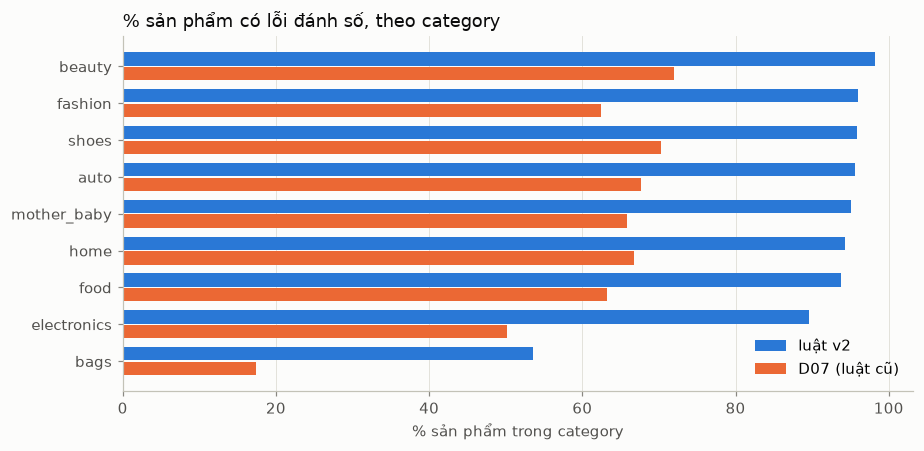

category,bags,electronics,food,home,mother_baby,auto,shoes,fashion,beauty
v2,53.6,89.6,93.7,94.3,95.1,95.6,95.9,96.0,98.3
d07,17.3,50.1,63.3,66.7,65.8,67.7,70.2,62.5,71.9


anh_duyet điền: DUNG_LOI (số đuôi đúng là lỗi đánh số) / BAT_NHAM (số đó là số thật)
Đã ghi data/eda/description/desc_loi_danh_so_mau_editted.csv (193 dòng)
Nghi đánh số lẻ (có số đuôi kiểu đánh số nhưng không thấy bản dịch trùng trong description): 1.185 giá trị, 895 dòng. Ví dụ:


,product_id,name_zh,v_zh,v_vi
250497,815245422984,规格型号,锁扣盒蓝扣14.6*8.5*3.4CM,Hộp khóa khóa màu xanh 14.6*8.5*3.4cm2
509915,1065322082880,元素,套装,Bộ2
689126,737732478703,款式,板鞋,Giày đế bằng1
105069,677392911936,null,null,null1
540970,1074261693484,款式,单鞋,Giày bệt2
250644,815245422984,规格型号,19长方盒透黑,19 hộp hình chữ nhật màu đen trong suốt2
574962,1009518440416,款式,单鞋,Giày bệt2
506150,1067993574396,元素,套装,Bộ2



KẾT LUẬN:
  - Giả thuyết khảo sát (giá trị Trung lặp) vẫn đúng một phần: 否 xuất hiện 1 lần/sp bị đánh số 0,1%, ≥ 2 lần bị đánh số 72,0%; nhưng bỏ sót 7.213 giá trị có số đuôi mà giá trị Trung không lặp.
  - Cơ chế đúng hơn: 99,2% giá trị có bản dịch Việt trùng trong sản phẩm bị đánh số; chỉ 1.185 giá trị có số đuôi mà bản dịch không trùng.
  - Luật v2 bắt 81.910 cặp thuộc tính / 87.144 giá trị / 14.329 dòng (87,6%); D07 cũ chỉ bắt 9.332 dòng.
  - Các luật chưa đo độ chính xác: cần anh duyệt 200 mẫu (desc_loi_danh_so_mau_editted.csv) trước khi dùng để sửa dữ liệu.


In [9]:
# Các cột danh_so_d07, danh_so_rong, lap_trong_sp (cấp cặp thuộc tính) và danh_so_gia_tri (cấp giá trị) đã gắn ở block 2.

# Chứng minh cơ chế: 否 xuất hiện 1 lần vs nhiều lần trong sản phẩm
S = A[A.n_vals_zh == 1]
rows = []
for z in ["否", "是", "其他"]:
    s = S[S.val_zh == z]
    for lab, m in [("1 lần trong sản phẩm", s.lap_trong_sp == 1), ("≥ 2 lần trong sản phẩm", s.lap_trong_sp >= 2)]:
        k = s[m]
        hit = k.val_vi.map(lambda v: bool(FULL_RE.match(v))).sum()
        rows.append({"gia_tri_zh": z, "xuat_hien": lab, "so_cap": len(k), "bi_danh_so": int(hit), "pct": round(pct(hit, len(k)), 1)})
mech = pd.DataFrame(rows)
print("Tỉ lệ bị đánh số theo số lần giá trị lặp trong sản phẩm:")
display(mech)
r_no = mech[(mech.gia_tri_zh == "否")]
check("否 xuất hiện 1 lần/sp", r_no.so_cap.iloc[0], 4293)
check("... trong đó bị đánh số", r_no.bi_danh_so.iloc[0], 6)
check("否 xuất hiện ≥ 2 lần/sp", r_no.so_cap.iloc[1], 26166)
check("... trong đó bị đánh số", r_no.bi_danh_so.iloc[1], 18842)

art = S[S.val_vi.map(lambda v: bool(FULL_RE.match(v)))]
seq = art.groupby(["row", "val_zh"]).val_vi.apply(lambda s: sorted(int(re.search(r"\d+$", v).group()) for v in s) == list(range(1, len(s) + 1)))
check("Nhóm (sản phẩm, giá trị) có số đuôi", len(seq), 13121)
check("... được đánh số đúng 1..k liên tiếp", seq.sum(), 11490)

# Cơ chế đúng hơn, ở cấp từng giá trị: so 2 giả thuyết
co_so = np.where(V.goc != "", "có số đuôi", "không có số đuôi")
gt_vi = pd.crosstab(np.where(V.vi_trung_trong_sp >= 2, "bản dịch Việt trùng ≥ 2 lần trong sp", "bản dịch Việt không trùng"), co_so)
gt_zh = pd.crosstab(np.where(V.lap_trong_sp >= 2, "giá trị Trung lặp ≥ 2 lần trong sp", "giá trị Trung không lặp"), co_so)
print("\nGiả thuyết A (khảo sát): máy đánh số giá trị TRUNG lặp. Số giá trị:")
display(gt_zh)
print("Giả thuyết B: máy đánh số BẢN DỊCH VIỆT trùng nhau. Số giá trị:")
display(gt_vi)
miss_zh = int(gt_zh.loc["giá trị Trung không lặp", "có số đuôi"])
miss_vi = int(gt_vi.loc["bản dịch Việt không trùng", "có số đuôi"])
hit_vi = int(gt_vi.loc["bản dịch Việt trùng ≥ 2 lần trong sp", "có số đuôi"])
tot_vi = int(gt_vi.loc["bản dịch Việt trùng ≥ 2 lần trong sp"].sum())

check("Cặp bắt bởi D07", A.danh_so_d07.sum(), 36524)
check("Dòng bắt bởi D07", A.loc[A.danh_so_d07, "row"].nunique(), 9332)
check("Cặp bắt bởi luật rộng", A.danh_so_rong.sum(), 66881)
check("Dòng bắt bởi luật rộng", A.loc[A.danh_so_rong, "row"].nunique(), 13675)
cmp = pd.DataFrame({
    "luat": ["D07 (cũ)", "luật rộng (khảo sát)", "luật v2 (đề xuất)"],
    "cap_thuoc_tinh": [int(A.danh_so_d07.sum()), int(A.danh_so_rong.sum()), int(A.danh_so_v2.sum())],
    "so_dong": [A.loc[A.danh_so_d07, "row"].nunique(), A.loc[A.danh_so_rong, "row"].nunique(), A.loc[A.danh_so_v2, "row"].nunique()],
})
cmp["pct_dong"] = (cmp.so_dong / N * 100).round(1)
print("So 3 luật (cấp cặp thuộc tính; v2 tính cả giá trị trong danh sách):")
display(cmp)
both, only_v2, only_d = (A.danh_so_d07 & A.danh_so_v2), (~A.danh_so_d07 & A.danh_so_v2), (A.danh_so_d07 & ~A.danh_so_v2)
print(f"Cả D07 và v2: {so(both.sum())} cặp | chỉ v2: {so(only_v2.sum())} | chỉ D07: {so(only_d.sum())}")


def tu_cuoi(v):
    w = re.sub(r"\.?\d+$", "", v).split()
    return w[-1] if w else ""


print("Từ đứng trước số, ở các giá trị luật v2 bắt (để thấy D07 bỏ sót những gì):")
display(V.loc[V.danh_so_gia_tri, "v_vi"].map(tu_cuoi).value_counts().head(20).rename("so_gia_tri").to_frame().T)
print("Ví dụ 2 giá trị Trung KHÁC nhau ra cùng 1 bản dịch nên bị đánh số:")
ex = V[V.danh_so_gia_tri].groupby(["row", "khoa_vi"]).filter(lambda g: g.v_zh.nunique() > 1)
display(ex.groupby(["row", "khoa_vi"]).head(3)[["product_id", "name_zh", "v_zh", "v_vi"]].head(9))
print("Tên thuộc tính hay bị đánh số nhất (luật v2):")
display(A.loc[A.danh_so_v2, "name_zh"].value_counts().head(12).rename("so_cap").to_frame().T)

rc = pd.DataFrame({
    "v2": A[A.danh_so_v2].groupby("category").row.nunique(),
    "d07": A[A.danh_so_d07].groupby("category").row.nunique(),
}).reindex(CATS).fillna(0)
rc = (rc.div(df.category.value_counts().reindex(CATS), axis=0) * 100).sort_values("v2")
fig, ax = plt.subplots(figsize=(8.5, 4.2))
y = np.arange(len(rc))
ax.barh(y + 0.2, rc.v2, height=0.36, color=C1, label="luật v2")
ax.barh(y - 0.2, rc.d07, height=0.36, color=C2, label="D07 (luật cũ)")
ax.set_yticks(y, rc.index)
ax.set_title("% sản phẩm có lỗi đánh số, theo category")
ax.set_xlabel("% sản phẩm trong category")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
display(rc.round(1).T)

parts = []
for nhom, m, k in [("ca_d07_va_v2", both, 60), ("chi_v2", only_v2, 100), ("chi_d07", only_d, 40)]:
    s = A[m]
    s = s.sample(min(k, len(s)), random_state=SEED)
    parts.append(s.assign(nhom=nhom))
mau = pd.concat(parts)[["nhom", "product_id", "category", "name_zh", "val_zh", "val_vi", "val_vi_bo_so"]]
mau["val_zh"] = mau.val_zh.str[:200]
mau["val_vi"] = mau.val_vi.str[:200]
mau["val_vi_bo_so"] = mau.val_vi_bo_so.str[:200]
mau["anh_duyet"] = ""
mau["anh_ghi_chu"] = ""
print("anh_duyet điền: DUNG_LOI (số đuôi đúng là lỗi đánh số) / BAT_NHAM (số đó là số thật)")
ghi_csv(mau, "desc_loi_danh_so_mau_editted.csv")

E = V[V.danh_so_gia_tri]
ghi_van_de("DS06", "Lỗi đánh số trong giá trị thuộc tính (luật v2: bản dịch Việt trùng nhau trong sản phẩm bị thêm số đuôi)", 2,
           "số đuôi 1–2 chữ số, bỏ đi thì khớp số bản Trung, và bản dịch trùng với giá trị khác trong sản phẩm",
           {r: f"{n}: {z} → {v}" for r, n, z, v in zip(E.row[::-1], E.name_zh[::-1], E.v_zh[::-1], E.v_vi[::-1])},
           so_cap=int(A.danh_so_v2.sum()))
L1 = V[V.nghi_danh_so_le]
print(f"Nghi đánh số lẻ (có số đuôi kiểu đánh số nhưng không thấy bản dịch trùng trong description): {so(len(L1))} giá trị, {so(L1.row.nunique())} dòng. Ví dụ:")
display(L1[["product_id", "name_zh", "v_zh", "v_vi"]].sample(min(8, len(L1)), random_state=SEED))
ghi_van_de("DS06B", "Nghi lỗi đánh số lẻ: số đuôi kiểu đánh số nhưng không thấy bản dịch trùng trong description (cần đọc)", 3,
           "số đuôi 1–2 chữ số, bỏ đi thì khớp số bản Trung, nhưng không trùng giá trị nào khác trong description",
           {r: f"{n}: {z} → {v}" for r, n, z, v in zip(L1.row[::-1], L1.name_zh[::-1], L1.v_zh[::-1], L1.v_vi[::-1])},
           so_cap=len(L1))

ket_luan(
    f"Giả thuyết khảo sát (giá trị Trung lặp) vẫn đúng một phần: 否 xuất hiện 1 lần/sp bị đánh số {tl(r_no.bi_danh_so.iloc[0], r_no.so_cap.iloc[0], 1)}, "
    f"≥ 2 lần bị đánh số {tl(r_no.bi_danh_so.iloc[1], r_no.so_cap.iloc[1], 1)}; nhưng bỏ sót {so(miss_zh)} giá trị có số đuôi mà giá trị Trung không lặp.",
    f"Cơ chế đúng hơn: {tl(hit_vi, tot_vi, 1)} giá trị có bản dịch Việt trùng trong sản phẩm bị đánh số; chỉ {so(miss_vi)} giá trị có số đuôi mà bản dịch không trùng.",
    f"Luật v2 bắt {so(A.danh_so_v2.sum())} cặp thuộc tính / {so(V.danh_so_gia_tri.sum())} giá trị / {so(A.loc[A.danh_so_v2, 'row'].nunique())} dòng "
    f"({tl(A.loc[A.danh_so_v2, 'row'].nunique(), N, 1)}); D07 cũ chỉ bắt {so(A.loc[A.danh_so_d07, 'row'].nunique())} dòng.",
    "Các luật chưa đo độ chính xác: cần anh duyệt 200 mẫu (desc_loi_danh_so_mau_editted.csv) trước khi dùng để sửa dữ liệu.",
)

## 9. Chữ Hán còn sót và tiếng Anh do máy dịch thêm

**Chữ Hán còn sót:** đếm riêng ở **tên** và ở **giá trị** tiếng Việt (D06 cũ chỉ đếm cả chuỗi).

**Tiếng Anh, theo chuẩn của title (chính sách 28/09):**
- Dùng đúng cách tách từ của `title_audit.py`: từ Latin không phải âm tiết tiếng Việt không dấu. Bỏ qua đơn vị, thuật ngữ kỹ thuật và từ mượn đã Việt hoá.
- Chỉ tính những từ **không có trong bản Trung**, tức do máy dịch thêm vào, vd 下游平台 → "downstream". Tên hãng, model, mã hàng chép từ bản Trung sang thì không tính.
- Bỏ qua thuộc tính tên hãng và mã/giấy tờ (vai trò gợi ý ở block 5): tên hãng đã xét riêng ở block 7.
- Mỗi từ được tra hành động đã chốt ở bảng của title (`title_latin_tokens_editted.csv`): `GIU` / `THAY` / `HANVIET` / `THEO_CUM` / `XEM_TAY`. Chỉ nhóm phải thay (`THAY`, `THEO_CUM`, `HANVIET`, `XEM_TAY`) được tính là vấn đề. Từ chưa có trong bảng ghi `CHUA_CO`, để anh duyệt, chưa tính là lỗi.

[OK] Cặp có chữ Hán trong TÊN tiếng Việt: 4.717
[OK] Cặp có chữ Hán trong GIÁ TRỊ tiếng Việt: 4.084
Dòng có ít nhất 1 chỗ còn chữ Hán: 2.097 (12,83%)
Giá trị Trung bị bỏ nguyên không dịch, nhiều nhất:


,name_zh,val_zh,so_cap
0,是否IP授权,否,113
1,床品规格标准,其他,58
2,包装种类,基础包装,47
3,规格类型,正常规格,41
4,是否智能,非智能,33
5,使用场景,日常护理,33
6,有可授权的自有品牌,否,30
7,适用人群,通用,30
8,款式,床笠式,29
9,是否跨境出口专供货源,否,28


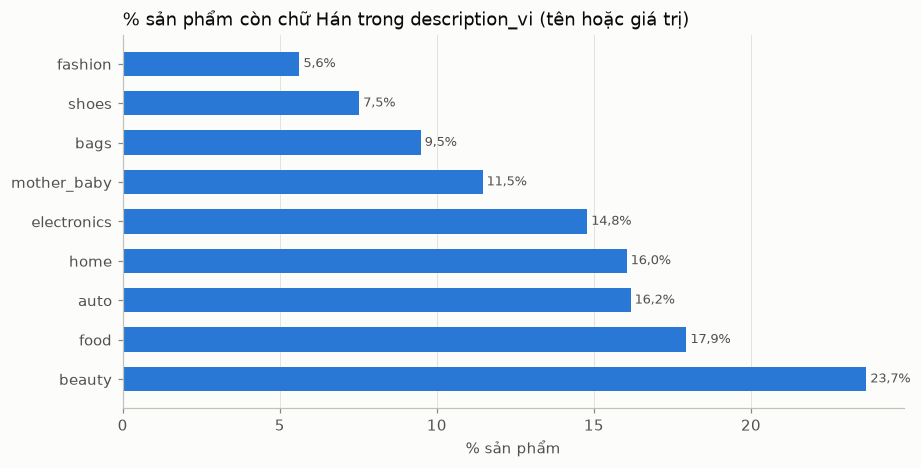

(tách từ mất 8 giây)
Từ Latin do máy dịch thêm (không có trong bản Trung): 7.386 từ khác nhau, 87.807 lượt, 14.047 dòng.
Theo hành động đã chốt ở bảng title:


,so_tu,so_luot
hanh_dong_title,,
GIU,994,49915
CHUA_CO,5922,23696
THEO_CUM,210,6960
HANVIET,121,3625
THAY,118,3268
XEM_TAY,21,343


30 từ nhiều nhất:


,tu,so_cap,so_dong,hanh_dong_title,thay_bang_title,vi_du_ten_zh,vi_du_vi
0,polyester,5028,3234,GIU,,里料质地,Polyester
1,aliexpress,4811,4810,GIU,,主要下游平台,"ebay, Amazon, wish, AliExpress, Trạm độc lập, LAZADA"
2,cotton,4642,989,GIU,,花型,[Mã hóa - đầu bàn chải mở rộng] cây lau nhà dạng que uốn cong tiết kiệm sức lao
3,amazon,4558,4552,GIU,,主要下游平台,"ebay, Amazon, wish, AliExpress, Trạm độc lập, LAZADA"
4,apple,2752,228,GIU,,适用型号,"Ping Ping An An★【Apple】 Gửi keo dán, Suy nghĩ về màu cam★【Orange】 Gửi keo dán"
5,kaki,1601,1275,GIU,,颜色,"Màu tinh khiết hình thang-** màu đen cổ điển [nhỏ], Màu tinh khiết hình thang-**"
6,unisex,1210,1205,THAY,nam nữ,适用性别,Unisex/Cả nam và nữ đều được chào đón.
7,downstream,1167,1167,CHUA_CO,,主要下游平台,"eBay, Amazon, mong muốn, AliExpress, Trang web độc lập, LAZADA, Khác4"
8,web,996,981,GIU,,主要下游平台,"Bột kim loại, Vôi kim loại, Bạc tuyết, Tím ánh ngọc trai, Hồng nhạt vàng hồng, V"
9,gram,886,695,CHUA_CO,,克重,"Bàn chải cán tre số 1, Số 2 bàn chải đầu tròn tốt, Số 3 bàn chải đầu tròn màu đe"


Đã ghi data/eda/description/desc_tieng_anh_trong_vi_editted.csv (7.386 dòng)

KẾT LUẬN:
  - Còn chữ Hán: 4.717 cặp ở tên, 4.084 cặp ở giá trị; tổng 2.097 dòng (12,83%).
  - Từ Latin do máy thêm (đã bỏ tên hãng và mã): 7.386 từ, 14.047 dòng. Theo bảng title: 4.040 dòng (24,7%) có từ thuộc nhóm phải thay; nhóm GIU (vd polyester, amazon) không tính là lỗi.
  - 5.922 từ (23.696 lượt, 7.967 dòng) chưa có trong bảng title: chưa phân loại, không tính vào DS08; anh duyệt trong desc_tieng_anh_trong_vi_editted.csv (đã xếp theo số lượt, đọc từ trên xuống).


In [10]:
cjk_name_m = A.name_vi.map(has_cjk)
cjk_val_m = A.val_vi.map(has_cjk)
check("Cặp có chữ Hán trong TÊN tiếng Việt", cjk_name_m.sum(), 4717)
check("Cặp có chữ Hán trong GIÁ TRỊ tiếng Việt", cjk_val_m.sum(), 4084)
cjk_rows = A.loc[cjk_name_m | cjk_val_m, "row"].unique()
print(f"Dòng có ít nhất 1 chỗ còn chữ Hán: {so(len(cjk_rows))} ({tl(len(cjk_rows), N)})")
print("Giá trị Trung bị bỏ nguyên không dịch, nhiều nhất:")
display(A.loc[cjk_val_m & (A.val_zh == A.val_vi), ["name_zh", "val_zh"]].value_counts().head(10).rename("so_cap").reset_index())
cr = (A.loc[cjk_name_m | cjk_val_m].groupby("category").row.nunique() / df.category.value_counts() * 100).reindex(CATS).sort_values()
bar_h(cr.index, cr.values, "% sản phẩm còn chữ Hán trong description_vi (tên hoặc giá trị)", "% sản phẩm", fmt_val=lambda v: f"{sf(v, 1)}%")
E = A[cjk_name_m | cjk_val_m]
ghi_van_de("DS07", "Còn chữ Hán trong description_vi (tên hoặc giá trị)", 2, "regex chữ Hán trên tên và giá trị tiếng Việt",
           {r: f"{a}: {b[:60]}" for r, a, b in zip(E.row[::-1], E.name_vi[::-1], E.val_vi[::-1])}, so_cap=len(E))

# --- Tiếng Anh: cùng cách tách từ với scripts/eda/title_audit.py
TOKEN = re.compile(r"[0-9A-Za-zÀ-ỹĐđ]+(?:[.\-+'’][0-9A-Za-zÀ-ỹĐđ]+)*")
ONSET = r"(?:ngh|ng|nh|ch|gh|gi|kh|ph|qu|th|tr|b|c|d|g|h|k|l|m|n|p|r|s|t|v|x)?"
RHYME = (r"(?:a|ai|ao|au|ay|an|am|ang|anh|e|eo|en|em|eng|i|ia|iu|in|im|inh|o|oi|on|om|ong|oong|"
         r"oa|oai|oay|oan|oang|oanh|oe|oeo|oen|u|ua|ui|uy|un|um|ung|uya|uyu|uynh|y)")
VN_ASCII = re.compile(rf"^{ONSET}{RHYME}$")


def latin_foreign(tok):
    letters = re.sub(r"[^A-Za-zÀ-ỹĐđ]", "", tok)
    if not letters or not letters.isascii():
        return False
    if re.search(r"\d", tok):
        return True
    return not VN_ASCII.match(tok.lower())


UNITS = set("""cm mm m km ml l lít kg g mg w kw v mah ah gb tb mb hz khz ghz inch db lm oz lb cc k p x
mw kv va kwh mbps ma a nm um""".split())
TECH = set("""wifi bluetooth usb led lcd oled hdmi gps nfc tws anc enc hifi hd fhd uhd 2k 4k 8k ai app tv pc
ios android carplay magsafe type-c typec otg sim cpu ram rom rgb ic ups dc ac adas dvr etc obd tpms 3d 5d
pvc abs pp pe pet tpu tpr eva ppsu pom pu pa pc nbr epe pla uv spf pa+++ oem odm diy qr id mp3 mp4 mp5 ipx
ip67 ip68 wi-fi 4g 5g 3g lte sd tf""".split())
VN_LOAN = set("""vali balo axit amin inox caro gile oxy amoniac sandal vest nylon silicon camera logo laptop video
robot micro nano gel vitamin protein internet game piano laser radar polo jean short tivi ô-tô karaoke
mascara album""".split())

title_tok = pd.read_csv(ROOT / "data" / "eda" / "title_audit" / "title_latin_tokens_editted.csv", usecols=["token", "hanh_dong", "thay_bang"])
title_tok["token"] = title_tok.token.astype(str).str.lower()
act = dict(zip(title_tok.token, title_tok.hanh_dong))
thay = dict(zip(title_tok.token, title_tok.thay_bang))


def latin_moi(z, v):
    zl = z.lower()
    out = []
    for t in TOKEN.findall(v):
        k = t.lower()
        if re.search(r"\d", k) or not latin_foreign(t) or k in UNITS or k in TECH or k in VN_LOAN or k in zl:
            continue
        out.append(k)
    return out


t = time.time()
# Bỏ tên hãng và mã/giấy tờ (vai trò gợi ý ở block 5): tên hãng đã có block 7, mã hàng là chuỗi Latin/số không phải lỗi dịch.
xet = ~A.vai_tro_goi_y.isin(["thuong_hieu", "ma_giay_to"])
A["latin_moi"] = [latin_moi(f"{a} | {b}", f"{c} | {d}") if x else [] for a, b, c, d, x in zip(A.name_zh, A.val_zh, A.name_vi, A.val_vi, xet)]
print(f"(tách từ mất {time.time() - t:.0f} giây)")
X = A[A.latin_moi.map(len) > 0][["row", "name_zh", "name_vi", "val_zh", "val_vi", "latin_moi"]].explode("latin_moi")
tok = (X.groupby("latin_moi").agg(so_cap=("row", "size"), so_dong=("row", "nunique"),
                                  vi_du_ten_zh=("name_zh", lambda s: s.value_counts().index[0]),
                                  vi_du_vi=("val_vi", lambda s: s.iloc[0][:80]))
         .sort_values("so_cap", ascending=False).reset_index().rename(columns={"latin_moi": "tu"}))
tok["hanh_dong_title"] = tok.tu.map(act).fillna("CHUA_CO")
tok["thay_bang_title"] = tok.tu.map(thay).fillna("")
tok["anh_duyet"] = ""
tok["anh_ghi_chu"] = ""
print(f"Từ Latin do máy dịch thêm (không có trong bản Trung): {so(len(tok))} từ khác nhau, {so(len(X))} lượt, {so(X.row.nunique())} dòng.")
print("Theo hành động đã chốt ở bảng title:")
display(tok.groupby("hanh_dong_title").agg(so_tu=("tu", "size"), so_luot=("so_cap", "sum")).sort_values("so_luot", ascending=False))
print("30 từ nhiều nhất:")
display(tok.head(30)[["tu", "so_cap", "so_dong", "hanh_dong_title", "thay_bang_title", "vi_du_ten_zh", "vi_du_vi"]])
ghi_csv(tok, "desc_tieng_anh_trong_vi_editted.csv")
VI_PHAM = {"THAY", "THEO_CUM", "HANVIET", "XEM_TAY"}
bad = X[X.latin_moi.map(lambda k: act.get(k) in VI_PHAM)]
chua = X[X.latin_moi.map(lambda k: k not in act)]
ghi_van_de("DS08", "Tiếng Anh/pinyin do máy dịch thêm vào description_vi, thuộc nhóm phải thay theo bảng title (THAY/THEO_CUM/HANVIET/XEM_TAY)", 3,
           "từ Latin không phải âm tiết Việt, không có trong bản Trung, bỏ tên hãng và mã; tra hành động ở bảng title",
           {r: f"{k} ({act.get(k, 'CHUA_CO')}): {v[:60]}" for r, k, v in zip(bad.row[::-1], bad.latin_moi[::-1], bad.val_vi[::-1])},
           so_cap=len(bad))

ket_luan(
    f"Còn chữ Hán: {so(cjk_name_m.sum())} cặp ở tên, {so(cjk_val_m.sum())} cặp ở giá trị; tổng {so(len(cjk_rows))} dòng ({tl(len(cjk_rows), N)}).",
    f"Từ Latin do máy thêm (đã bỏ tên hãng và mã): {so(len(tok))} từ, {so(X.row.nunique())} dòng. "
    f"Theo bảng title: {so(bad.row.nunique())} dòng ({tl(bad.row.nunique(), N, 1)}) có từ thuộc nhóm phải thay; nhóm GIU (vd polyester, amazon) không tính là lỗi.",
    f"{so((tok.hanh_dong_title == 'CHUA_CO').sum())} từ ({so(len(chua))} lượt, {so(chua.row.nunique())} dòng) chưa có trong bảng title: "
    "chưa phân loại, không tính vào DS08; anh duyệt trong desc_tieng_anh_trong_vi_editted.csv (đã xếp theo số lượt, đọc từ trên xuống).",
)

## 10. Số và đơn vị

**Làm gì:** so các con số trong giá trị zh với giá trị vi của cùng cặp thuộc tính, tương tự D05 của title. Trước khi so:
- Đổi số kiểu Việt về cùng dạng: "0,5" → 0.5; "100.000" → 100000.
- Bỏ số đuôi của lỗi đánh số (block 8), để không tính trùng lỗi.

**Kiểu lệch:**
- `vi_thieu_so`: bản Việt mất số.
- `vi_thua_so`: bản Việt có thêm số.
- `khac_so`: hai bên có số khác nhau.
- `doi_nam`: năm 20xx bị đổi.

**Giới hạn:** máy dịch hay đổi chữ số Hán đơn (二层 → "2 lớp", 双 → 2) sang chữ số, đổi 斤 sang kg (36斤 → "18kg", vì 1 斤 = 0,5 kg), đổi 万 (1000万 → "10 million"), và 纯棉 → "100% cotton". Các trường hợp này được coi là đúng. Số Hán ghép (二十, 百) và năm viết tắt (26年) chưa quy đổi nên có thể báo nhầm. Danh sách để đọc, không để xoá.

**Đơn vị:** bảng cho thấy mỗi đơn vị Trung (寸, 厘米, 克, 斤...) được dịch thành gì. Ví dụ 寸 ở vali nghĩa là inch, đó là đặc thù của miền TMĐT.

In [11]:
NUM = re.compile(r"\d+(?:\.\d+)?")


def nums_zh(s):
    return sorted(float(x) for x in NUM.findall(s))


def nums_vi(s):
    s = re.sub(r"(?<=\d)\.(?=\d{3}(?!\d))", "", s)
    s = re.sub(r"(?<=\d),(?=\d)", ".", s)
    return sorted(float(x) for x in NUM.findall(s))


has_num =A.val_zh.map(lambda s: bool(HAS_DIGIT.search(s))) | A.val_vi_bo_ca_nghi.map(lambda s: bool(HAS_DIGIT.search(s)))
Nm = A[has_num].copy()
Nm["so_zh"] = Nm.val_zh.map(nums_zh)
Nm["so_vi"] = Nm.val_vi_bo_ca_nghi.map(nums_vi)   # bỏ số đuôi của lỗi đánh số, kể cả nhóm nghi đánh số lẻ (block 2)
YEAR = re.compile(r"20\d\d")


def kieu_lech_so(z, v, sz, sv):
    if sz == sv:
        return ""
    yz, yv = set(YEAR.findall(z)), set(YEAR.findall(v))
    if yz and yv and yz != yv:
        return "doi_nam"
    # Các quy đổi đúng của máy dịch, không tính lệch:
    #   斤 → kg (1 斤 = 0,5 kg); 万 → "triệu/million" hoặc số đầy đủ (1000万 = 10 million = 10.000.000); 纯 → "100%" (纯棉 = 100% cotton)
    ok = Counter(sz)
    if "斤" in z and "kg" in v.lower():
        ok += Counter(x / 2 for x in sz)
    if "万" in z:
        ok += Counter(x / 100 for x in sz) + Counter(x * 10000 for x in sz)
    if "纯" in z:
        ok += Counter([100.0])
    if ok != Counter(sz) and not (Counter(sv) - ok) and not any(x not in sv and x / 2 not in sv and x / 100 not in sv and x * 10000 not in sv for x in sz):
        return ""
    thua = Counter(sv) - Counter(sz)
    cn = {float(CN_NUM[c]) for c in z if c in CN_NUM}
    if not (Counter(sz) - Counter(sv)) and thua and all(x in cn for x in thua):
        return ""                      # máy đổi chữ số Hán (二层 → 2 lớp): đúng, không tính lệch
    if not thua:
        return "vi_thieu_so"
    if not (Counter(sz) - Counter(sv)):
        return "vi_thua_so"
    return "khac_so"


Nm["kieu"] = [kieu_lech_so(z, v, a, b) for z, v, a, b in zip(Nm.val_zh, Nm.val_vi_bo_ca_nghi, Nm.so_zh, Nm.so_vi)]
M = Nm[Nm.kieu != ""]
print(f"Cặp có số ở ít nhất 1 bên: {so(len(Nm))}; lệch số: {so(len(M))} ({tl(len(M), len(Nm))}), ở {so(M.row.nunique())} dòng.")
display(M.kieu.value_counts().rename("so_cap").to_frame().T)
print("Tên thuộc tính lệch số nhiều nhất:")
display(M.name_zh.value_counts().head(12).rename("so_cap").to_frame().T)
out = M[["kieu", "product_id", "category", "name_zh", "val_zh", "val_vi", "so_zh", "so_vi"]].copy()
for c in ["val_zh", "val_vi"]:
    out[c] = out[c].str[:250]
out["so_zh"] = out.so_zh.map(lambda x: " ".join(f"{v:g}" for v in x))
out["so_vi"] = out.so_vi.map(lambda x: " ".join(f"{v:g}" for v in x))
print("Ví dụ mỗi kiểu:")
display(out.groupby("kieu").head(2))
ghi_csv(out, "desc_so_lech.csv")
ghi_van_de("DS10", "Số trong giá trị thuộc tính lệch giữa zh và vi", 1, "so tập số zh với vi sau chuẩn hoá dấu thập phân",
           {r: f"[{k}] {n}: {z[:50]} | {v[:50]}" for r, k, n, z, v in zip(M.row[::-1], M.kieu[::-1], M.name_zh[::-1], M.val_zh[::-1], M.val_vi[::-1])},
           so_cap=len(M))

dec = A[A.val_zh.str.contains(r"\d\.\d", regex=True)]
dec_comma = dec.val_vi.str.contains(r"\d,\d", regex=True).sum()
print(f"\nGiá trị zh có số thập phân dạng 0.5: {so(len(dec))} cặp; bản Việt viết dấu phẩy (0,5): {so(dec_comma)} ({tl(dec_comma, len(dec), 1)}).")
# Chỉ xét SỐ ĐO có đơn vị (1.5米, 0.5kg...): mã tiêu chuẩn (GB/T30357.2) và số phiên bản (蓝牙 5.3) giữ dấu chấm là đúng.
DO = re.compile(r"\d\.\d+\s*(?:cm|mm|kg|ml|m|g|l|英寸|寸|厘米|毫米|千克|公斤|米|克|斤|毫升|升)", re.I)
meas = A[A.val_zh.map(lambda s: bool(DO.search(s)))]
dec_dot = meas[meas.val_vi_bo_so.str.contains(r"\d\.\d", regex=True) & ~meas.val_vi.str.contains(r"\d,\d", regex=True)]
dec_com = meas[meas.val_vi.str.contains(r"\d,\d", regex=True)]
print(f"Số đo thập phân có đơn vị: {so(len(meas))} cặp; bản Việt giữ dấu chấm {so(len(dec_dot))}, viết dấu phẩy {so(len(dec_com))}; "
      f"dòng có cả 2 kiểu: {so(len(set(dec_dot.row) & set(dec_com.row)))}")
ghi_van_de("DS14", "Định dạng: số đo thập phân bản Việt lúc viết dấu phẩy (1,5m), lúc giữ dấu chấm (1.5m)", 4,
           "giá trị zh có số đo thập phân kèm đơn vị; xem bản Việt viết 1,5 hay 1.5",
           {**{r: f"dấu chấm: {n}: {z[:40]} | {v[:50]}" for r, n, z, v in zip(dec_dot.row, dec_dot.name_zh, dec_dot.val_zh, dec_dot.val_vi_bo_so)},
            **{r: f"dấu phẩy: {n}: {z[:40]} | {v[:50]}" for r, n, z, v in zip(dec_com.row, dec_com.name_zh, dec_com.val_zh, dec_com.val_vi)}},
           so_cap=len(dec_dot) + len(dec_com))

UNITS_ZH = {"寸": r"(?<!英)寸", "英寸": r"英寸", "厘米": r"厘米", "毫米": r"毫米", "米": r"(?<![厘毫])米", "克": r"(?<!千)克",
            "千克": r"千克", "公斤": r"公斤", "斤": r"(?<!公)斤", "毫升": r"毫升", "升": r"(?<!毫)升", "码": r"码", "岁": r"岁"}
rows = []
for u, rx in UNITS_ZH.items():
    pat = re.compile(r"(\d+(?:\.\d+)?)\s*" + rx)
    sub = A[A.val_zh.str.contains(rx, regex=True)]
    nxt = Counter()
    for z, v in zip(sub.val_zh, sub.val_vi):
        for n in pat.findall(z):
            for form in {n, n.replace(".", ",")}:
                mm = re.search(r"(?<![\d.,])" + re.escape(form) + r"\s*([^\s\d,;:()/]+)", v)
                if mm:
                    nxt[mm.group(1).lower()] += 1
                    break
    rows.append({"don_vi_zh": u, "so_cap": len(sub), "cach_dich_vi_pho_bien": "; ".join(f"{k}: {c}" for k, c in nxt.most_common(6))})
print("Đơn vị tiếng Trung được dịch thành gì (từ đứng ngay sau con số ở bản Việt):")
display(pd.DataFrame(rows))

ket_luan(
    f"{so(len(M))}/{so(len(Nm))} cặp có số bị lệch ({tl(len(M), len(Nm))}), ở {so(M.row.nunique())} dòng: "
    + ", ".join(f"{k} {so(v)}" for k, v in M.kieu.value_counts().items()) + ".",
    f"Số thập phân: {tl(dec_comma, len(dec), 1)} bản Việt đổi sang dấu phẩy (đúng kiểu Việt); cần thống nhất 1 cách khi làm sạch.",
    "Báo nhầm có thể có ở chữ số Hán và năm viết tắt: đọc desc_so_lech.csv trước khi dùng.",
)

Cặp có số ở ít nhất 1 bên: 88.570; lệch số: 1.263 (1,43%), ở 727 dòng.


kieu,vi_thua_so,khac_so,vi_thieu_so,doi_nam
so_cap,888,252,122,1


Tên thuộc tính lệch số nhiều nhất:


name_zh,床单面料材质,枕套材质,被面材质,材质,颜色,尺寸规格,包装规格,货号,规格,花型,尺寸,容量
so_cap,169,166,164,117,108,87,70,57,31,27,20,20


Ví dụ mỗi kiểu:


,kieu,product_id,category,name_zh,val_zh,val_vi,so_zh,so_vi
1113,vi_thua_so,959192226769,auto,尺寸,"三折棉-灰色（151*55cm）, 三折棉-棕色（151*55cm)","70% off cotton-xám (151*55cm), 70% off cotton nâu (151*55cm)",55 55 151 151,55 55 70 70 151 151
1642,vi_thieu_so,895818189903,auto,尺寸,"黑色普通款, 黑色升级双拉链款, 黑色加厚双拉链款, 黑色加厚4拉链款","Phong cách đen thông thường, Dây kéo đôi nâng cấp màu đen, Dây kéo đôi dày màu đen, Mà...",4,
2063,vi_thieu_so,639544253848,auto,尺寸,"遮阳伞-钛银大号140*80cm（原版正品）, 遮阳伞-钛银小号125*65cm（原版正品）, 开口款遮阳伞-钛银大号（原版正品）, 开口款遮阳伞-钛银小号（原版正品）, ...","Parasol-titan bạc cỡ lớn 140*80cm (chính hãng và chính hãng), Parasol-titan bạc cỡ nhỏ...",1 1 1 2 2 2 2 2 4 4 4 4 65 65 80 80 125 125 140 140,1 1 2 2 2 2 2 4 4 4 4 65 65 80 80 125 125 140 140
2091,doi_nam,768008456940,auto,尺寸,"款式1, 款式2, 款式3, 款式4, 款式5, 款式6, 款式7, 套装1, 套装2, 奔驰w24, 宝马5系 X5 E53 E39, 宝马 X5 X6后备箱开关, 宝马...","Kiểu 1, Kiểu 2, Kiểu dáng 3, Kiểu 4, Kiểu 5, Kiểu 6, Kiểu dáng 7, Bộ 1, Bộ 2, Mercedes...",1 1 2 2 2 3 3 3 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 ...,1 1 1 2 2 2 2 3 3 3 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 ...
2677,khac_so,932538618729,auto,尺寸,"跨境沙纹黑1.5(opp一个装）, 跨境沙纹1.5袋子对装, 跨境1.5沙纹电商盒一对装, 1.5 沙纹吸塑+纸卡, 跨境沙纹米1.5(opp一个装）, 跨境沙纹灰1.5(...","跨境沙纹黑1.5(opp一个装）, 跨境沙纹米1.5(opp一个装）, 跨境沙纹灰1.5(opp一个装）, Họa tiết cát xuyên biên giới 1,5...",1.5 1.5 1.5 1.5 1.5 1.5 2 2 2 2 2 2 2 2 3 3 3 5 5 104 105 105 105 105 106 107,1 1.5 1.5 1.5 1.5 1.5 2 2 2 2 2 2 2 2 3 3 3 5 5 5 104 105 105 105 105 106 107
2894,vi_thua_so,988263386898,auto,颜色,"兔毛豹纹立体猫咪坐垫前排, 兔毛豹纹立体猫咪坐垫靠背, 兔毛豹纹立体猫咪坐垫后排, 兔毛豹纹立体猫咪坐垫后排迷你, 兔毛豹纹猫咪头枕, 兔毛豹纹猫咪腰靠, 兔毛豹纹头枕-无...","Lông thỏ in hình da báo đệm mèo ba chiều hàng ghế trước, Đệm và tựa lưng ghế mèo ba ch...",3 7,3 3 7
5495,khac_so,633156351171,auto,颜色,"加长款三合一红色, 加长款三合一黄色, 加长款三合一蓝色, 黑色三合一不可伸缩【可旋转刷头+海绵手柄+刨冰铲头】, 蓝色三合一不可伸缩【可旋转刷头+海绵手柄+刨冰铲头】, ...","Đỏ 3 trong 1, Dài Hơn, Chiều dài mở rộng 3 trong 1 màu vàng, Màu xanh 3 trong 1 có chi...",2 7 13 18 19 20 20 21 21 21 22 22 98 126 126 137 137 137 137 2001 2001 3113 3113 3114 ...,1 1 1 1 1 2 3 3 3 3 3 13 18 19 20 20 21 21 21 22 22 98 126 126 137 137 137 137 2001 20...


Đã ghi data/eda/description/desc_so_lech.csv (1.263 dòng)

Giá trị zh có số thập phân dạng 0.5: 6.324 cặp; bản Việt viết dấu phẩy (0,5): 1.281 (20,3%).
Số đo thập phân có đơn vị: 2.067 cặp; bản Việt giữ dấu chấm 1.036, viết dấu phẩy 1.027; dòng có cả 2 kiểu: 76
Đơn vị tiếng Trung được dịch thành gì (từ đứng ngay sau con số ở bản Việt):


,don_vi_zh,so_cap,cach_dich_vi_pho_bien
0,寸,912,inch: 3986; inch]: 27; ]: 10; 寸: 10; .: 6; kênh: 5
1,英寸,970,inch: 1027; *: 16; inch-[vỏ: 1
2,厘米,96,cm: 443; *: 22; cm]: 18; m: 12; cm】: 6; cm-phiên: 1
3,毫米,2,
4,米,2896,m: 1154; mét: 372; màu: 118; đen: 31; .: 22; x: 13
5,克,1249,g: 3366; gram: 308; g]: 126; đầu: 112; gx: 58; g*: 39
6,千克,4,kg: 4
7,公斤,13,kg: 11; .: 1
8,斤,619,kg: 1309; kg]: 457; món: 80; catties: 45; .: 42; -: 28
9,毫升,19,ml: 74; bình: 5; mililit.: 1; lít: 1; ml储奶瓶【无奶嘴⚑♢: 1



KẾT LUẬN:
  - 1.263/88.570 cặp có số bị lệch (1,43%), ở 727 dòng: vi_thua_so 888, khac_so 252, vi_thieu_so 122, doi_nam 1.
  - Số thập phân: 20,3% bản Việt đổi sang dấu phẩy (đúng kiểu Việt); cần thống nhất 1 cách khi làm sạch.
  - Báo nhầm có thể có ở chữ số Hán và năm viết tắt: đọc desc_so_lech.csv trước khi dùng.


## 11. Trùng lặp và gần trùng

**Trùng y hệt:** nhiều sản phẩm có `description_zh` giống hệt nhau. Có trường hợp cùng bản Trung nhưng bản Việt khác, tức máy dịch không ổn định.

**Gần trùng (MinHash, `datasketch`):** cắt `description_zh` thành các đoạn 5 ký tự, ước lượng độ giống Jaccard. Cặp ≥ 0,8 được nối thành cụm (giống ngưỡng charter đề xuất). Cụm lớn thường là cùng shop dùng chung khuôn mô tả.

**Vì sao quan trọng:** nếu một cụm thực chất là cùng một sản phẩm (hoặc cùng khuôn của một shop), các dòng của cụm phải nằm cùng một tập khi chia train/test, nếu không điểm test bị thổi phồng (D10). Ghi chú: MinHash ở đây chạy trên bảng thuộc tính, nên cụm có thể gồm các sản phẩm khác nhau nhưng cùng khuôn thuộc tính.

[OK] Dòng trùng y hệt description_zh với dòng khác: 193
[OK] Số nhóm trùng y hệt: 87
[OK] Nhóm cùng zh nhưng khác vi: 70
Nhóm trùng y hệt cùng 1 shop: 41/87
(MinHash mất 12 giây; 1.581 cặp gần trùng)
Cụm gần trùng (≥ 2 dòng): 465 cụm, 1.319 dòng (8,07%); cụm lớn nhất 45 dòng.
Cụm chỉ 1 shop: 259; cụm trải ≥ 2 category: 0


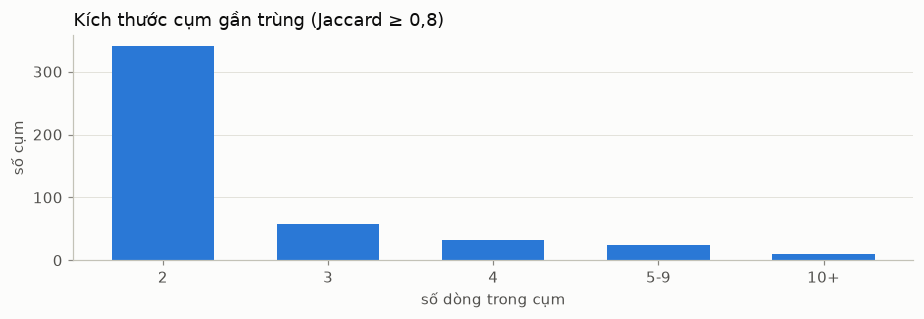

Theo category (% dòng nằm trong cụm gần trùng):


category,fashion,electronics,shoes,bags,beauty,mother_baby,food,home,auto
pct,18.0,5.2,15.3,4.1,4.9,9.4,3.2,5.9,5.5



Cụm 9588: 45 dòng, 3 shop, category {'fashion': 45}
    主面料成分: 棉; 面料名称: 纯棉; 款式: 套头; 品牌: 其他; 工艺: 印花/印染; 适合人群: 青少年; 类别: 短袖T恤; 风格: 基础大众; 货号: W820; 图案: 卡通; 版型: 合体型; 货源类别: 现货; 淘货类别: 青春流行（18-24岁）; 领型: 圆领; 袖长: 短袖; 是否连帽: 不连帽

Cụm 16119: 26 dòng, 3 shop, category {'shoes': 26}
    鞋面材质: pu; 款式: 圆头鞋; 鞋底材质: 橡胶; 内里材质: 其它; 鞋垫材质: EVA; 功能: 透气; 品牌: 其他; 产品类别: 懒人鞋; 开口深度: 浅口（7cm以下）; 适用年龄段: 青年（18-40周岁）; 适合季节: 秋季; 流行元素: 车缝线; 产地: 浙江温州; 风格: 其他; 适用性别: 男

Cụm 16003: 24 dòng, 7 shop, category {'shoes': 24}
    鞋面材质: pu+网布; 功能: 透气, 防滑, 耐磨; 内里材质: 布; 鞋底材质: 橡胶; 款式: 老爹鞋; 产品类别: 老爹鞋; 适用年龄段: 青年（18-40周岁）; 产地: 浙江温州; 风格: 韩版; 货号: Z637; 适合季节: 夏季, 冬季, 春季, 秋季; 适用性别: 男; 图案: 拼色; 适用运动:

Lưu ý: cột shop là tên công ty (thông tin cá nhân theo charter), file chỉ dùng nội bộ.
Đã ghi data/eda/description/desc_cum_gan_trung.csv (1.319 dòng)

KẾT LUẬN:
  - Trùng y hệt: 193 dòng / 87 nhóm; 70 nhóm cùng zh khác vi (máy dịch không ổn định).
  - Gần trùng: 1.319 dòng (8,07%) trong 465 cụm; 56% cụm chỉ thuộc 1 shop.
  - Gần trùng ở đây là 

In [12]:
from datasketch import MinHash, MinHashLSH

dup = df.description_zh.duplicated(keep=False)
grp = df[dup].groupby("description_zh")
check("Dòng trùng y hệt description_zh với dòng khác", dup.sum(), 193)
check("Số nhóm trùng y hệt", grp.ngroups, 87)
check("Nhóm cùng zh nhưng khác vi", int((grp.description_vi.nunique() > 1).sum()), 70)
print(f"Nhóm trùng y hệt cùng 1 shop: {so((grp['shop'].nunique() == 1).sum())}/{so(grp.ngroups)}")

t = time.time()
K, PERM, THR = 5, 128, 0.8
mhs = []
for s in df.description_zh:
    m = MinHash(num_perm=PERM, seed=SEED)
    m.update_batch([s[i:i + K].encode("utf-8") for i in range(max(1, len(s) - K + 1))])
    mhs.append(m)
lsh = MinHashLSH(threshold=THR, num_perm=PERM)
for i, m in enumerate(mhs):
    lsh.insert(i, m)
parent = list(range(N))


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


n_pairs = 0
for i, m in enumerate(mhs):
    for j in lsh.query(m):
        if j > i and m.jaccard(mhs[j]) >= THR:
            n_pairs += 1
            ri, rj = find(i), find(j)
            if ri != rj:
                parent[ri] = rj
print(f"(MinHash mất {time.time() - t:.0f} giây; {so(n_pairs)} cặp gần trùng)")
df["cum_gan_trung"] = [find(i) for i in range(N)]
size = df.cum_gan_trung.map(df.cum_gan_trung.value_counts())
C = df[size >= 2]
cl = C.groupby("cum_gan_trung").agg(kich_thuoc=("product_id", "size"), so_shop=("shop", "nunique"), so_category=("category", "nunique"))
print(f"Cụm gần trùng (≥ 2 dòng): {so(len(cl))} cụm, {so(len(C))} dòng ({tl(len(C), N)}); cụm lớn nhất {so(cl.kich_thuoc.max())} dòng.")
print(f"Cụm chỉ 1 shop: {so((cl.so_shop == 1).sum())}; cụm trải ≥ 2 category: {so((cl.so_category > 1).sum())}")
bins = pd.cut(cl.kich_thuoc, [1, 2, 3, 4, 9, 10_000], labels=["2", "3", "4", "5-9", "10+"])
d = bins.value_counts().reindex(["2", "3", "4", "5-9", "10+"])
fig, ax = plt.subplots(figsize=(8.5, 3))
ax.bar(d.index.astype(str), d.values, color=C1, width=0.62)
ax.set_title("Kích thước cụm gần trùng (Jaccard ≥ 0,8)")
ax.set_xlabel("số dòng trong cụm")
ax.set_ylabel("số cụm")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()
print("Theo category (% dòng nằm trong cụm gần trùng):")
display((C.category.value_counts() / df.category.value_counts() * 100).reindex(CATS).round(1).rename("pct").to_frame().T)
big = cl.sort_values("kich_thuoc", ascending=False).head(3).index
for cid in big:
    x = df[df.cum_gan_trung == cid]
    print(f"\nCụm {cid}: {len(x)} dòng, {x['shop'].nunique()} shop, category {x.category.value_counts().to_dict()}")
    print("   ", x.description_zh.iloc[0][:160])
out = C[["cum_gan_trung", "product_id", "category", "shop", "title_zh"]].copy()
out.insert(1, "kich_thuoc_cum", size[size >= 2].values)
out = out.sort_values(["kich_thuoc_cum", "cum_gan_trung"], ascending=[False, True])
print("\nLưu ý: cột shop là tên công ty (thông tin cá nhân theo charter), file chỉ dùng nội bộ.")
ghi_csv(out, "desc_cum_gan_trung.csv")
ghi_van_de("DS11", "Description trùng hoặc gần trùng (MinHash Jaccard ≥ 0,8) với sản phẩm khác", 2,
           "MinHash 5 ký tự trên description_zh, nối cặp ≥ 0,8 thành cụm",
           {i: f"cụm {c} ({s} dòng)" for i, c, s in zip(C.index, C.cum_gan_trung, size[size >= 2])})

ket_luan(
    f"Trùng y hệt: {so(dup.sum())} dòng / {so(grp.ngroups)} nhóm; {so(int((grp.description_vi.nunique() > 1).sum()))} nhóm cùng zh khác vi (máy dịch không ổn định).",
    f"Gần trùng: {so(len(C))} dòng ({tl(len(C), N)}) trong {so(len(cl))} cụm; {tl((cl.so_shop == 1).sum(), len(cl), 0)} cụm chỉ thuộc 1 shop.",
    "Gần trùng ở đây là gần trùng BẢNG THUỘC TÍNH: có thể là các sản phẩm khác nhau dùng chung khuôn (vd cùng loại áo thun, khác mã hàng), "
    "không chắc là cùng 1 sản phẩm. Nên đọc vài cụm lớn trong desc_cum_gan_trung.csv trước khi quyết định có gộp cụm vào nhóm chia train/dev/test hay không.",
)

## 12. Thông tin cá nhân

**Charter §6:** mô tả có thể chứa tên shop, số điện thoại, địa chỉ, và phải lọc trước khi công bố dữ liệu.

**Dò bằng regex** trên `description_zh`, `description_vi`, `description_extra_zh`:
- `so_di_dong_TQ`: số di động Trung Quốc, 11 số bắt đầu bằng 1[3-9].
- `so_co_dinh`: số máy bàn.
- `url`, `email`.
- `wechat_qq`: chữ 微信 / VX / QQ / wechat.
- `dia_chi`: 地址, số nhà...

**Đây là ứng viên, chưa chắc là thông tin cá nhân thật:** chuỗi 11 số có thể là mã hàng, "QQ" có thể là kẹo QQ糖. File `desc_thong_tin_ca_nhan_editted.csv` có đoạn trích ±25 ký tự; anh điền `anh_duyet` = `PII_THAT` / `KHONG_PHAI`.

In [13]:
PII = {
    "so_di_dong_TQ": re.compile(r"(?<!\d)1[3-9]\d{9}(?!\d)"),
    "so_co_dinh": re.compile(r"(?<!\d)0\d{2,3}-?\d{7,8}(?!\d)"),
    "url": re.compile(r"https?://|www\.", re.I),
    "email": re.compile(r"[\w.]+@[\w.]+\.\w+"),
    "wechat_qq": re.compile(r"微信|VX|vx|QQ|qq号|wechat", re.I),
    "dia_chi": re.compile(r"地址|路\d+号|街道|工业区|号楼"),
}
hits = []
for col in ["description_zh", "description_vi", "description_extra_zh"]:
    for i, s in zip(df.index, df[col]):
        if not s:
            continue
        for loai, rx in PII.items():
            m = rx.search(s)
            if m:
                hits.append({"row": i, "product_id": df.at[i, "product_id"], "category": df.at[i, "category"], "cot": col,
                             "loai": loai, "doan_trich": s[max(0, m.start() - 25): m.end() + 25]})
H = pd.DataFrame(hits)
print("Số dòng có ứng viên, theo cột × loại:")
display(H.pivot_table(index="loai", columns="cot", values="row", aggfunc="nunique", fill_value=0))
check("Dòng có số di động TQ trong description_zh", H[(H.cot == "description_zh") & (H.loai == "so_di_dong_TQ")].row.nunique(), 92)
ph = A[A.val_zh.map(lambda s: bool(PII["so_di_dong_TQ"].search(s)))]
check("Cặp thuộc tính có số di động TQ", len(ph), 93)
check("... ở số dòng", ph.row.nunique(), 91)
print("Thuộc tính chứa số di động (tên có 联系/电话 gần như chắc là số điện thoại; 净含量 có thể là mã):")
display(ph.name_zh.value_counts().rename("so_cap").to_frame().T)
co = A[A.val_zh.str.contains("有限公司", regex=False)]
print(f"Giá trị có tên công ty (有限公司): {so(len(co))} cặp, nhiều nhất ở: {co.name_zh.value_counts().head(5).to_dict()}")
out = H.drop(columns=["row"]).copy()
out["anh_duyet"] = ""
out["anh_ghi_chu"] = ""
print("anh_duyet điền: PII_THAT / KHONG_PHAI")
ghi_csv(out, "desc_thong_tin_ca_nhan_editted.csv")
ghi_van_de("DS12", "Ứng viên thông tin cá nhân trong description (số điện thoại, URL, email, WeChat/QQ, địa chỉ)", 2,
           "regex trên description_zh/vi/extra_zh", {r: f"[{l}] {t}" for r, l, t in zip(H.row[::-1], H.loai[::-1], H.doan_trich[::-1])})

ket_luan(
    f"{so(H.row.nunique())} dòng có ít nhất 1 ứng viên thông tin cá nhân; riêng số di động TQ nằm trong {so(ph.row.nunique())} dòng (giá trị thuộc tính).",
    f"Tên công ty xuất hiện trong {so(len(co))} cặp giá trị; ngoài ra cột shop (không thuộc description) có ở mọi dòng.",
    "Phải lọc trước khi công bố dữ liệu (charter §6); trước đó cần anh duyệt để tách số điện thoại thật với mã hàng.",
)

Số dòng có ứng viên, theo cột × loại:


cot,description_extra_zh,description_vi,description_zh
loai,,,
dia_chi,61,1,27
so_co_dinh,0,18,16
so_di_dong_TQ,8,89,92
url,86,2,2
wechat_qq,8,16,16


[OK] Dòng có số di động TQ trong description_zh: 92
[OK] Cặp thuộc tính có số di động TQ: 93
[OK] ... ở số dòng: 91
Thuộc tính chứa số di động (tên có 联系/电话 gần như chắc là số điện thoại; 净含量 có thể là mã):


name_zh,净含量,产品厂家联系方式,适用范围,功能,流行元素,联系方式,适用人群,成分原料,营养成分,商品特性,包装方式,定做电话,风格,厂家联系电话,收纳场景,生产厂家,货号,主要销售地区,商品条形码
so_cap,24,19,18,7,4,3,2,2,2,2,2,1,1,1,1,1,1,1,1


Giá trị có tên công ty (有限公司): 691 cặp, nhiều nhất ở: {'生产厂家': 553, '产品厂家厂名': 73, '生产厂商': 29, '生产企业': 10, '供货商': 9}
anh_duyet điền: PII_THAT / KHONG_PHAI
Đã ghi data/eda/description/desc_thong_tin_ca_nhan_editted.csv (442 dòng)

KẾT LUẬN:
  - 297 dòng có ít nhất 1 ứng viên thông tin cá nhân; riêng số di động TQ nằm trong 91 dòng (giá trị thuộc tính).
  - Tên công ty xuất hiện trong 691 cặp giá trị; ngoài ra cột shop (không thuộc description) có ở mọi dòng.
  - Phải lọc trước khi công bố dữ liệu (charter §6); trước đó cần anh duyệt để tách số điện thoại thật với mã hàng.


## 13. `description_extra_zh`

**Là gì:** chữ bóc ra từ khối ảnh giới thiệu (详情) trên trang 1688, **chỉ có tiếng Trung, không có bản Việt**, nên không ghép cặp được.

**Làm gì:** tỉ lệ có chữ theo category, độ dài, và phân loại nội dung bằng từ khoá. Một đoạn có thể thuộc nhiều nhóm: thông số, giới thiệu công ty, hậu mãi, lưu ý, vận chuyển, liên hệ. Thông tin cá nhân trong cột này đã đếm ở block 12.

[OK] Dòng có description_extra_zh: 3.749


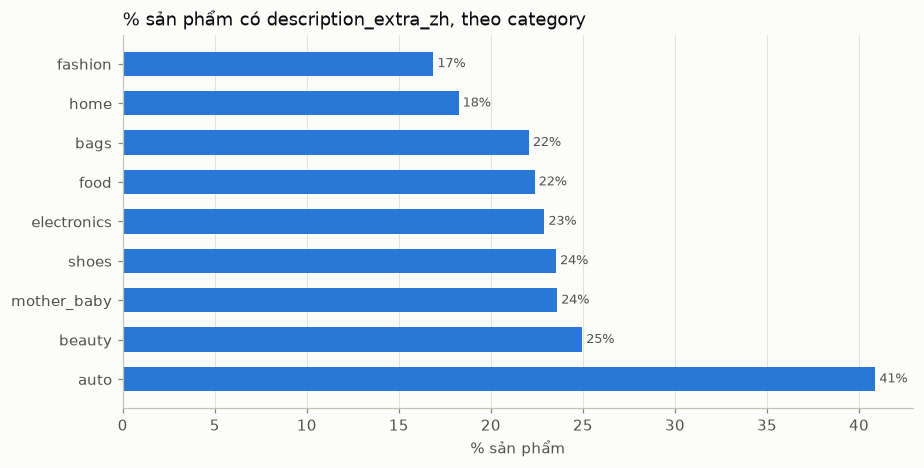

Độ dài (ký tự): {0.5: 122, 0.9: 645, 0.99: 1699}


,so_dong,pct
lien_he,1082,28.9
thong_so,989,26.4
cong_ty,929,24.8
van_chuyen,903,24.1
luu_y,568,15.2
hau_mai,549,14.6


Đoạn extra chứa nguyên title_zh: 126 dòng

5 mẫu ngẫu nhiên (cắt 220 ký tự):
  > 感谢大家选择康泰制鞋厂 服务简要说明如下 跨境代发： 支持 Amazon 、 Shopee 、 Temu 、 Shein 、 Flipkart 、 AliExpress 、 Mercado Libre 、 Ozon 、 Wildberries 、 Lazada 、 Walmart 、 Tik Tok 、 FBA 、 海外仓 等多平台贴 转码标 、 条码 、 箱唛 、 船唛 发货。 国内代发： 支持 抖音 、 快手 、 视频号 、 淘宝（
  > 各位亲，咱们家的飞碟飞的比较高哦，建议在有草坪的地方玩哦 另外，拉线的时候，线要平着拉，这样就不容易摩擦了 自助购物 上架商品能拍就有现货，亲们可以按照流程自助拍下喜欢的宝贝哦！ 色差 本店所有商品均为实物拍摄，由于显示器不同可能会存在色彩差异，都有详细描述，不清楚的请在购买前咨询客服。 发货 亲要发哪个快递，请在下单后和客服说清楚，没有说明的一律发本店默认快递。对产品有特别要求的请在给卖家留言里说明！ 签收 签收包裹是请务必当着快递员
  > 深圳易路有你电子科技有限公司，专业生产各类各式汽车电子产品。美容汽修+渠道批发+外贸贸易+电商一件代发。款式齐全，价格优惠。以品质第一，服务至上为宗旨。 烽途者A4-1寸WIFI隐藏式行车记录仪 1寸屏，1080P高清录像，高清夜视效果。 手机WIFI互联，一键分享保存视频。 实时停车监控，缩时录影，停车48小时记录。 智能语音提醒，开启录像，紧急录像，拍照成功。 超强配置，稳定出货中，支持外语版，国内外通用。 全套包含：主机+电源线+
  > ———产品参数——— 品名：古树晒红--把把茶 类型：滇红茶 年份：2026年 规格：500g/份，28斤/件 保存方法：避光 密封 防潮 防异味，可长期贮存。 古树晒红 实物拍摄，又名金枝玉叶，看外型很是高贵，巨长的滇红金针茶，条索相当完整。蜜香浓郁，很有颜值和口感。
  > 实力商家 店家推荐 全场包邮3C认证 男孩汽车变形玩具汽车变形机器人过家家儿童金刚玩具培训机构礼物 ￥ 3.99 立即购买 大集合 遥控车 电动遥控坦克飞机攀爬翻斗车男孩女孩积分兑换玩具 ￥ 7.70 立即购

In [14]:
X = df[df.description_extra_zh.str.len() > 0]
check("Dòng có description_extra_zh", len(X), 3749)
cov = (X.category.value_counts() / df.category.value_counts() * 100).reindex(CATS).sort_values()
bar_h(cov.index, cov.values, "% sản phẩm có description_extra_zh, theo category", "% sản phẩm", fmt_val=lambda v: f"{v:.0f}%")
print("Độ dài (ký tự):", {k: int(v) for k, v in X.description_extra_zh.str.len().quantile([.5, .9, .99]).items()})
KW = {
    "thong_so": r"参数|规格|尺寸|重量|材质|货号|型号",
    "cong_ty": r"公司|企业|工厂|厂家|源头",
    "hau_mai": r"售后|退换|质保|退货|退款",
    "luu_y": r"注意|温馨提示|说明|提示",
    "van_chuyen": r"发货|物流|快递|包邮|代发",
    "lien_he": r"客服|联系|咨询|电话|热线",
}
kw = pd.Series({k: int(X.description_extra_zh.str.contains(p, regex=True).sum()) for k, p in KW.items()}).sort_values(ascending=False)
display(pd.DataFrame({"so_dong": kw, "pct": (kw / len(X) * 100).round(1)}))
same_title = sum(t in e for t, e in zip(X.title_zh, X.description_extra_zh))
print(f"Đoạn extra chứa nguyên title_zh: {so(same_title)} dòng")
print("\n5 mẫu ngẫu nhiên (cắt 220 ký tự):")
for s in X.description_extra_zh.sample(5, random_state=SEED):
    print("  >", s[:220])

ket_luan(
    f"{so(len(X))} dòng ({tl(len(X), N)}) có chữ; nội dung lẫn lộn: " + ", ".join(f"{k} {tl(v, len(X), 0)}" for k, v in kw.items()) + ".",
    "Chỉ có tiếng Trung nên không dùng làm cặp song ngữ; nếu dùng (vd nguồn đơn ngữ zh) thì phải lọc thông tin cá nhân trước. Cách dùng do anh quyết.",
)

## 14. Thuật ngữ: title so với description

**Làm gì:** với 11 thuật ngữ trong `title_term_consistency.csv` (vd 行车记录仪, 拉杆箱), lấy các sản phẩm có thuật ngữ đó ở **cả** `title_zh` lẫn `description_zh`. Sau đó xem bản Việt của title và của description có dùng **cùng một cách dịch** không.

**Cách dò:**
- Tìm các cách dịch (theo danh sách trong file title) xuất hiện trong mỗi bản Việt.
- Cách dịch ngắn nằm lọt trong cách dịch dài thì bỏ, vd "ghi âm lái xe" nằm trong "máy ghi âm lái xe".
- `khop`: hai bên có chung 1 cách dịch.
- `lech`: hai bên đều tìm thấy cách dịch nhưng không trùng nhau.
- `khong_xac_dinh`: một bên không thấy cách dịch nào trong danh sách.

**Chỉ đếm, không sửa.** Kết quả dùng cho bảng thuật ngữ chuẩn (D09) sau này.

In [15]:
tt = pd.read_csv(ROOT / "data" / "eda" / "title_audit" / "title_term_consistency.csv")
col = [c for c in tt.columns if c.startswith("cach_dich_vi")][0]
terms = {r["thuat_ngu_zh"]: [p.rsplit(":", 1)[0].strip().lower() for p in str(r[col]).split(";") if p.strip()]
         for _, r in tt.iterrows()}


def tim_cach_dich(text, variants):
    t = text.lower()
    found = [v for v in variants if v and v in t]
    return {v for v in found if not any(v != w and v in w for w in found)}


rows, ev = [], {}
for term, variants in terms.items():
    m = df.title_zh.str.contains(term, regex=False) & df.description_zh.str.contains(term, regex=False)
    k = Counter()
    for i in df.index[m]:
        a, b = tim_cach_dich(df.at[i, "title_vi"], variants), tim_cach_dich(df.at[i, "description_vi"], variants)
        if a and b:
            if a & b:
                k["khop"] += 1
            else:
                k["lech"] += 1
                ev[i] = f"{term}: title '{'/'.join(sorted(a))}' ≠ description '{'/'.join(sorted(b))}'"
        else:
            k["khong_xac_dinh"] += 1
    rows.append({"thuat_ngu_zh": term, "so_dong_ca_hai": int(m.sum()), **{x: k[x] for x in ["khop", "lech", "khong_xac_dinh"]}})
TT = pd.DataFrame(rows).sort_values("so_dong_ca_hai", ascending=False)
display(TT)
out = pd.DataFrame([{"product_id": df.at[i, "product_id"], "category": df.at[i, "category"], "bang_chung": s,
                     "title_vi": df.at[i, "title_vi"][:150]} for i, s in ev.items()])
ghi_csv(out, "desc_thuat_ngu_title_lech.csv")
ghi_van_de("DS13", "Cùng sản phẩm, cùng thuật ngữ nhưng title và description dịch khác nhau", 2,
           "11 thuật ngữ của title_term_consistency.csv, so cách dịch ở title_vi và description_vi", ev)
tot = TT[["khop", "lech", "khong_xac_dinh"]].sum()
ket_luan(
    f"Trong {so(TT.so_dong_ca_hai.sum())} lượt (sản phẩm, thuật ngữ): khớp {so(tot.khop)}, lệch {so(tot.lech)}, không xác định {so(tot.khong_xac_dinh)}.",
    "Lệch nghĩa là cùng 1 sản phẩm mà title và description dùng 2 cách dịch khác nhau: mô hình học 2 đáp án cho 1 thuật ngữ.",
)

,thuat_ngu_zh,so_dong_ca_hai,khop,lech,khong_xac_dinh
10,面膜,720,690,12,18
9,补水,510,477,4,29
0,行车记录仪,229,74,121,34
6,老爹鞋,129,79,15,35
8,双肩包,75,64,4,7
1,充电宝,59,19,20,20
7,拉杆箱,23,4,4,15
4,网红,9,1,0,8
2,密码箱,3,1,0,2
5,一件代发,2,0,0,2


Đã ghi data/eda/description/desc_thuat_ngu_title_lech.csv (180 dòng)

KẾT LUẬN:
  - Trong 1.761 lượt (sản phẩm, thuật ngữ): khớp 1.410, lệch 180, không xác định 171.
  - Lệch nghĩa là cùng 1 sản phẩm mà title và description dùng 2 cách dịch khác nhau: mô hình học 2 đáp án cho 1 thuật ngữ.


## 15. Đọc thêm: dịch sai nghĩa, địa danh, không thống nhất, ký tự

Block này bổ sung các lỗi tìm được khi **đọc tay** tên và giá trị thuộc tính phổ biến. Em đã đọc 220 tên phổ biến nhất và 700 cặp giá trị phổ biến nhất.

**Dịch sai nghĩa** (giống D03 của title):
- Danh sách các cách dịch sai do em đọc tay mà lập ra, kèm nghĩa đúng gợi ý.
- Notebook đếm chính xác các cách dịch đó ở cấp tên (DS15) và cấp giá trị (DS17). Nó **không** tự tìm lỗi mới, nên con số là mức tối thiểu.
- Nhiều lỗi cho thấy máy dịch đi vòng qua tiếng Anh: 鞋底 = "sole" → "duy nhất", 大众 → "Volkswagen", 蓝讯 → "Blue News", 纯色 = "solid" → "màu rắn".

**Các mục khác:**
- `是否X` (câu hỏi "có phải X không") bị dịch thành "Có nên X" hoặc "cho dù X": đổi nghĩa (DS16).
- Sai địa danh ở thuộc tính nơi sản xuất (DS18).
- Giá trị phổ biến dịch nhiều kiểu (DS19).
- Số thập phân bị tách: "53.5" → "53, 5" (DS20).
- Giá trị rỗng nghĩa như 其他, 无, 见包装 (DS21).
- Dấu chấm cuối do máy thêm (DS22).
- Chữ "KHÔNG" in hoa (DS23).
- Ký tự lạ (DS24).
- Tên thuộc tính lặp trong cùng sản phẩm (DS25).

**Đã kiểm, không có lỗi:** đảo ngược có/không (是 dịch "Không", 否 dịch "Có"): 0 cặp. Đảo giới tính: chỉ 1 cặp, in ra bên dưới.

In [16]:
def low(s):
    return s.lower()


# --- DS15: tên thuộc tính dịch sai nghĩa (danh sách đọc tay: tên zh → cụm sai trong bản Việt, nghĩa đúng gợi ý)
TEN_SAI = {
    "适用场景": (["kịch bản"], "tình huống/dịp sử dụng"), "使用场景": (["kịch bản"], "tình huống sử dụng"),
    "上市年份季节": (["niêm yết"], "năm/mùa ra mắt"), "上市年份季节（上市时间）": (["niêm yết"], "năm/mùa ra mắt"),
    "上市年份/季节": (["niêm yết"], "năm/mùa ra mắt"), "容量": (["công suất", "năng lực"], "dung tích"),
    "毛重": (["tịnh", "lông"], "trọng lượng cả bì"), "净含量（规格）": (["nội dung"], "khối lượng/dung tích tịnh"),
    "净含量": (["nội dung"], "khối lượng/dung tích tịnh"), "主面料成分含量": (["nội dung"], "tỉ lệ thành phần vải chính"),
    "主面料成分的含量": (["nội dung"], "tỉ lệ thành phần vải chính"), "适合人群": (["đám đông"], "đối tượng phù hợp"),
    "适用人群": (["đám đông"], "đối tượng sử dụng"), "安全等级": (["bảo mật", "an ninh"], "cấp độ an toàn"),
    "皮质特征": (["vỏ não", "cortical"], "đặc điểm da"), "有无夹层": (["tầng lửng", "gác lửng"], "có ngăn phụ không"),
    "鞋头形状": (["ngón chân"], "hình dạng mũi giày"), "鞋跟形状": (["gót chân"], "hình dạng gót giày"),
    "鞋跟高度": (["gót chân"], "chiều cao gót giày"), "鞋跟款式": (["gót chân"], "kiểu gót giày"),
    "鞋底工艺": (["duy nhất"], "công nghệ đế giày"), "版型": (["phiên bản"], "form dáng"),
    "口径规格": (["cỡ nòng"], "đường kính miệng"), "面料支数": (["số lượng vải"], "chi số sợi"),
    "元素": (["nguyên tố", "phần tử"], "yếu tố/chi tiết"), "起泡程度": (["phồng rộp"], "độ tạo bọt"),
    "热卖月份": (["tháng nóng"], "tháng bán chạy"), "图案": (["mô hình"], "hoa văn"),
    "领标": (["giá thầu", "lãnh đạo"], "nhãn cổ áo"), "传输速率": (["chuyển khoản"], "tốc độ truyền"),
    "型号": (["người mẫu"], "mẫu mã/model"), "闭合方式": (["đóng cửa"], "kiểu đóng"), "口味": (["nếm thử"], "hương vị"),
}
A["ten_sai"] = [(z in TEN_SAI) and any(w in low(v) for w in TEN_SAI[z][0]) for z, v in zip(A.name_zh, A.name_vi)]
T15 = A[A.ten_sai]
check("Cặp có tên thuộc tính dịch sai nghĩa (danh sách đọc tay)", len(T15), 21917)
check("... ở số dòng", T15.row.nunique(), 10878)
tb = (T15.groupby("name_zh").agg(so_cap=("row", "size"), so_dong=("row", "nunique"),
                                 cach_dich_sai=("name_vi", lambda s: "; ".join(f"{k}: {v}" for k, v in s.value_counts().head(3).items())))
        .sort_values("so_cap", ascending=False))
tb["nghia_dung_goi_y"] = [TEN_SAI[n][1] for n in tb.index]
print("Tên thuộc tính dịch sai nghĩa:")
display(tb.head(20))
ghi_csv(tb.reset_index().rename(columns={"name_zh": "ten_zh"}), "desc_ten_dich_sai_nghia.csv")
ghi_van_de("DS15", "Tên thuộc tính dịch sai nghĩa (毛重 → 'trọng lượng tịnh', 容量 → 'công suất', 皮质特征 → 'vỏ não'...)", 1,
           "danh sách đọc tay 33 tên, đếm cách dịch sai trong name_vi",
           {r: f"{z} → {v} (đúng: {TEN_SAI[z][1]})" for r, z, v in zip(T15.row[::-1], T15.name_zh[::-1], T15.name_vi[::-1])},
           so_cap=len(T15))

# --- DS16: 是否X → "Có nên X" / "cho dù X"
Q = A[A.name_zh.str.startswith("是否") & A.name_vi.map(lambda s: bool(re.search(r"^có nên|cho dù|^dù |^dù là|liệu có nên", low(s))))]
check("Cặp 是否 dịch thành 'có nên'/'cho dù'", len(Q), 4047)
check("... ở số dòng", Q.row.nunique(), 2877)
print("Các cách dịch sai hay gặp:")
display(Q.name_vi.value_counts().head(8).rename("so_cap").to_frame())
ghi_van_de("DS16", "Câu hỏi 是否X ('có phải X không') bị dịch thành 'Có nên X' hoặc 'cho dù X' (đổi nghĩa)", 1,
           "name_zh bắt đầu 是否, name_vi bắt đầu 'có nên' hoặc chứa 'cho dù'",
           {r: f"{z} → {v}" for r, z, v in zip(Q.row[::-1], Q.name_zh[::-1], Q.name_vi[::-1])}, so_cap=len(Q))

# --- DS17: giá trị dịch sai nghĩa (danh sách đọc tay: zh chứa, bản Việt chứa cụm sai, chỉ xét các tên thuộc tính nào, nghĩa đúng)
GT_SAI = [
    ("鸭屎香", "phân vịt", None, "Áp Thỉ Hương (giống trà)"), ("密码箱", "hộp mật khẩu", None, "vali khóa số"),
    ("雪梨", "sydney", None, "lê tuyết"), ("冰岛", "iceland", None, "Băng Đảo (làng trà)"),
    ("杰理", "jerry", None, "chip Jieli"), ("中科蓝讯", "blue news", None, "chip Zhongke Lanxun"),
    ("大红袍", "áo choàng đỏ", None, "Đại Hồng Bào (trà)"), ("苹果", "táo", {"适用型号", "适用机型", "苹果型号", "规格型号", "品牌"}, "Apple/iPhone"),
    ("基础大众", "volkswagen", None, "phổ thông/đại chúng"), ("长爬", "leo", None, "bộ liền thân trẻ em"),
    ("低帮", "mũ thấp", None, "cổ thấp"), ("低帮", "đỉnh thấp", None, "cổ thấp"), ("生活防水", "cuộc sống", None, "chống nước sinh hoạt"),
    ("粘胶鞋", "viscose", None, "giày dán keo"), ("前系带", "cà vạt", None, "buộc dây phía trước"),
    ("无领标", "không có cổ áo", None, "không có nhãn cổ"), ("韩版", "tiếng hàn", None, "kiểu Hàn"),
    ("纯色", "màu rắn", None, "màu trơn"), ("实拍无模特", "mô hình", None, "ảnh thật không có người mẫu"),
    ("单根", "gốc", None, "một dây"), ("双根", "rễ", None, "hai dây"), ("宽口径", "cỡ nòng", None, "miệng rộng"),
    ("套头", "mũ trùm", None, "chui đầu"), ("套头", "xe kéo", None, "chui đầu"), ("日常搭配", "đối sánh", None, "phối đồ hằng ngày"),
    ("明前", "nhà minh", None, "trà Minh Tiền (hái trước Thanh minh)"), ("明前", "trung thu", None, "trà Minh Tiền"),
    ("明前", "ngày mai", None, "trà Minh Tiền"), ("单鞋", "căn hộ", None, "giày bệt (flats → 'căn hộ')"),
    ("磨毛", "đánh răng", None, "vải chải lông (brushed → 'đánh răng')"), ("皮质", "vỏ não", None, "chất liệu da"),
]
hit = pd.Series("", index=V.index)
vl = V.v_vi.str.lower()
for z, w, names, dung in GT_SAI:
    m = V.v_zh.str.contains(z, regex=False) & vl.str.contains(w, regex=False) & (hit == "")
    if names:
        m &= V.name_zh.isin(names)
    hit[m] = f"{z} → '{w}' (đúng: {dung})"
m = V.v_zh.eq("中") & V.name_zh.isin(["箱包大小", "包大小", "硬度", "尺寸"]) & vl.str.strip(" .").isin(["trong", "giữa"])
hit[m & (hit == "")] = "中 (cỡ/độ vừa) → 'trong/giữa' (đúng: vừa, trung bình)"
G17 = V[hit != ""].assign(loi=hit[hit != ""])
tg = G17.groupby("loi").agg(so_gia_tri=("row", "size"), so_dong=("row", "nunique")).sort_values("so_gia_tri", ascending=False)
print(f"Giá trị dịch sai nghĩa (danh sách đọc tay): {so(len(G17))} giá trị, {so(G17.row.nunique())} dòng")
display(tg)
ghi_csv(tg.reset_index(), "desc_gia_tri_dich_sai_nghia.csv")
ghi_van_de("DS17", "Giá trị dịch sai nghĩa (鸭屎香 → 'phân vịt', 基础大众 → 'Volkswagen', 苹果 → 'táo'...)", 1,
           "danh sách đọc tay 32 lỗi, đếm ở cấp từng giá trị",
           {r: f"{n}: {z} → {v}" for r, n, z, v in zip(G17.row[::-1], G17.name_zh[::-1], G17.v_zh[::-1], G17.v_vi[::-1])},
           so_cap=len(G17))
gi = V[V.v_zh.isin(["男", "男士", "男款"]) & vl.str.contains("nữ") & ~vl.str.contains("nam")]
print(f"Đảo giới tính: {so(len(gi))} cặp", gi[["product_id", "name_zh", "v_zh", "v_vi"]].values.tolist())

# --- DS18: sai địa danh ở thuộc tính nơi sản xuất
PL = {"温州": ["ôn châu", "wenzhou"], "台州": ["thai châu", "đài châu", "taizhou"], "义乌": ["nghĩa ô", "yiwu"], "广州": ["quảng châu", "guangzhou"],
      "深圳": ["thâm quyến", "shenzhen"], "东莞": ["đông hoản", "dongguan"], "汕头": ["sán đầu", "shantou"], "杭州": ["hàng châu", "hangzhou"],
      "金华": ["kim hoa", "jinhua"], "宁波": ["ninh ba", "ningbo"], "泉州": ["tuyền châu", "quanzhou"], "晋江": ["tấn giang", "jinjiang"],
      "莆田": ["bồ điền", "putian"], "保定": ["bảo định", "baoding"], "白沟": ["bạch câu", "baigou"], "揭阳": ["yết dương", "jieyang"],
      "佛山": ["phật sơn", "foshan"], "中山": ["trung sơn", "zhongshan"], "潮州": ["triều châu", "chaozhou"], "湖州": ["hồ châu", "huzhou"],
      "苏州": ["tô châu", "suzhou"], "南通": ["nam thông", "nantong"], "临沂": ["lâm nghi", "linyi"], "安溪": ["an khê", "anxi"],
      "福鼎": ["phúc đỉnh", "fuding"], "武夷山": ["vũ di sơn", "wuyishan", "wuyi"], "云南": ["vân nam", "yunnan"], "普洱": ["phổ nhĩ", "pu'er", "puer"],
      "浙江": ["chiết giang", "zhejiang"], "广东": ["quảng đông", "guangdong"], "福建": ["phúc kiến", "fujian"], "河北": ["hà bắc", "hebei"],
      "河南": ["hà nam", "henan"], "江苏": ["giang tô", "jiangsu"], "山东": ["sơn đông", "shandong"], "安徽": ["an huy", "anhui"], "湖南": ["hồ nam", "hunan"],
      "四川": ["tứ xuyên", "sichuan"], "上海": ["thượng hải", "shanghai"], "北京": ["bắc kinh", "beijing"], "江西": ["giang tây", "jiangxi"]}
P = A[A.name_zh.isin({"产地", "原产地", "发货地", "产区", "原产国/地区", "产地/城市"})]
bad = []
for i, z, v in zip(P.index, P.val_zh, P.val_vi_bo_so):
    for k, ok in PL.items():
        if k in z and not any(o in low(v) for o in ok):
            bad.append((i, k))
            break
D18 = P.loc[[i for i, _ in bad]].assign(dia_danh=[k for _, k in bad])
check("Cặp sai địa danh (产地...)", len(D18), 997)
print("Sai địa danh nhiều nhất (địa danh, bản Việt):")
display(D18.groupby(["dia_danh", "val_vi"]).size().sort_values(ascending=False).head(12).rename("so_cap").to_frame())
ghi_van_de("DS18", "Sai địa danh nơi sản xuất (温州 → 'Vũ Hán', 义乌 → 'Nhật Bản', 莆田 → 'Phủ Điền'...)", 1,
           "40 địa danh hay gặp: bản Việt không có âm Hán Việt đúng hoặc pinyin",
           {r: f"{k}: {z} → {v}" for r, k, z, v in zip(D18.row[::-1], D18.dia_danh[::-1], D18.val_zh[::-1], D18.val_vi[::-1])}, so_cap=len(D18))

# --- DS19: giá trị phổ biến dịch không thống nhất (giá trị zh gặp ≥ 50 lần; bỏ khác biệt chữ hoa, dấu chấm, số đuôi)
S1 = A[A.n_vals_zh == 1].copy()
S1["vn"] = S1.val_vi_bo_so.str.lower().str.strip(" .")
cntv = S1.val_zh.value_counts()
S2 = S1[S1.val_zh.isin(cntv[cntv >= 50].index)]
majv = S2.groupby("val_zh").vn.agg(lambda s: s.value_counts().index[0])
M19 = S2[S2.vn != S2.val_zh.map(majv)]
check("Cặp dùng cách dịch thiểu số (giá trị phổ biến)", len(M19), 67932)
check("... ở số dòng", M19.row.nunique(), 13652)
cons = S2.groupby("val_zh").vn.agg(lambda s: round(100 * s.value_counts().iloc[0] / len(s), 1))
print(f"{so(len(cntv[cntv >= 50]))} giá trị zh gặp ≥ 50 lần; giá trị kém thống nhất nhất (% dùng cách dịch phổ biến nhất):")
display(pd.DataFrame({"pct_cach_pho_bien": cons, "cac_cach_dich": S2.groupby("val_zh").vn.agg(lambda s: "; ".join(f"{k}: {v}" for k, v in s.value_counts().head(5).items()))}).sort_values("pct_cach_pho_bien").head(12))
ghi_van_de("DS19", "Giá trị phổ biến dịch không thống nhất (vd 通用 → 'thông dụng' / 'đa năng' / 'phổ quát' / 'tổng quan')", 2,
           "giá trị zh gặp ≥ 50 lần, dòng dùng cách dịch khác cách phổ biến nhất",
           {r: f"{z} → {v} (phổ biến: {majv[z]})" for r, z, v in zip(M19.row[::-1], M19.val_zh[::-1], M19.vn[::-1])}, so_cap=len(M19))

# --- DS20: số thập phân bị tách ("53.5" → "53, 5")
c20 = A[A.val_zh.str.contains(r"\d\.\d", regex=True) & A.val_vi.str.contains(r"\d, \d", regex=True)]
c20 = c20[[any(f"{a}, {b}" in v for a, b in re.findall(r"(\d+)\.(\d+)", z)) for z, v in zip(c20.val_zh, c20.val_vi)]]
print(f"Số thập phân bị tách: {so(len(c20))} cặp, {so(c20.row.nunique())} dòng")
ghi_van_de("DS20", "Số thập phân bị tách thành 2 số ('53.5' → '53, 5', đọc như danh sách)", 1, "số zh dạng a.b xuất hiện ở bản Việt dạng 'a, b'",
           {r: f"{n}: {z[:50]} | {v[:60]}" for r, n, z, v in zip(c20.row, c20.name_zh, c20.val_zh, c20.val_vi)}, so_cap=len(c20))

# --- DS21: giá trị rỗng nghĩa
EMPTY = {"其他", "其它", "无", "见包装", "详见包装", "详询客服", "咨询客服", "联系客服", ".", "/", "-", "--", "null", "如图", "见详情", "查看详情", "以实物为准", "详情页", "见图", "暂无", "不详"}
E21 = A[A.val_zh.str.strip().isin(EMPTY)]
check("Cặp có giá trị rỗng nghĩa (其他/无/见包装/...)", len(E21), 20792)
check("... ở số dòng", E21.row.nunique(), 10036)
display(E21.val_zh.value_counts().head(10).rename("so_cap").to_frame().T)
ghi_van_de("DS21", "Giá trị rỗng nghĩa (其他, 无, 见包装, 咨询客服, '/', '-', '.'...): ít thông tin để học dịch", 3, "val_zh thuộc danh sách giá trị rỗng nghĩa",
           {r: f"{n}: {z} → {v}" for r, n, z, v in zip(E21.row[::-1], E21.name_zh[::-1], E21.val_zh[::-1], E21.val_vi[::-1])}, so_cap=len(E21))

# --- DS22: dấu chấm cuối do máy thêm
D22 = V[V.v_vi_bo_so.str.endswith(".") & ~V.v_zh.str.endswith(("。", ".")) & ~V.v_vi_bo_so.str.endswith("...")]
check("Giá trị có dấu chấm cuối do máy thêm", len(D22), 7855)
check("... ở số dòng", D22.row.nunique(), 5645)
ghi_van_de("DS22", "Dấu chấm cuối do máy dịch thêm ('Đúng.', 'Không.', '... cắt tỉa.')", 4, "bản Việt kết thúc bằng '.', bản Trung không",
           {r: f"{n}: {z} → {v}" for r, n, z, v in zip(D22.row[::-1], D22.name_zh[::-1], D22.v_zh[::-1], D22.v_vi[::-1])}, so_cap=len(D22))


# --- DS23: chữ in hoa toàn bộ ("KHÔNG")
def in_hoa_viet(s):
    chu = [c for c in s if c.isalpha() and not CJK.match(c)]
    return len(chu) >= 4 and all(c.isupper() for c in chu) and any(not c.isascii() for c in chu)


D23 = V[V.v_vi.map(in_hoa_viet)]
print(f"Giá trị viết IN HOA toàn bộ: {so(len(D23))} giá trị, {so(D23.row.nunique())} dòng;",
      D23.v_vi.str.replace(r"\.?\d+$", "", regex=True).value_counts().head(5).to_dict())
ghi_van_de("DS23", "Chữ tiếng Việt IN HOA toàn bộ ('KHÔNG', 'KHÔNG1'): không thống nhất với 'Không'", 4, "mọi chữ cái đều in hoa và có chữ có dấu",
           {r: f"{n}: {z} → {v}" for r, n, z, v in zip(D23.row[::-1], D23.name_zh[::-1], D23.v_zh[::-1], D23.v_vi[::-1])}, so_cap=len(D23))

# --- DS24: ký tự lạ trong bản Việt
KT = [("ky_tu_hong_U+FFFD", re.compile("�")), ("chu_Han_Quoc", re.compile("[가-힯]")),
      ("ky_tu_vung_rieng_PUA", re.compile("[-]")), ("dau_cau_Trung_khi_da_dich", re.compile("[，。、；：（）《》“”！？]")),
      ("khoang_trang_thua", re.compile(r"  |\( | \)|\[ | \]| ,"))]
rows24 = []
for i, n, z, v in zip(V.row, V.name_zh, V.v_zh, V.v_vi):
    for lab, rx in KT:
        if rx.search(v) and v != z and not (lab == "dau_cau_Trung_khi_da_dich" and has_cjk(v)):
            rows24.append((i, lab, f"[{lab}] {n}: {z[:40]} → {v[:60]}"))
            break
K24 = pd.DataFrame(rows24, columns=["row", "loai", "bc"])
print("Ký tự lạ trong bản Việt (số giá trị):")
display(K24.loai.value_counts().rename("so_gia_tri").to_frame().T)
display(K24.groupby("loai").head(2)[["loai", "bc"]])
ghi_van_de("DS24", "Ký tự lạ trong bản Việt: ký tự hỏng '�', chữ Hàn, ký tự vùng riêng, dấu câu Trung, khoảng trắng thừa", 4, "regex ký tự trên từng giá trị tiếng Việt",
           dict(zip(K24.row[::-1], K24.bc[::-1])), so_cap=len(K24))

# --- DS25: tên thuộc tính lặp trong cùng sản phẩm
dn = A.groupby(["row", "name_zh"]).size()
dn = dn[dn > 1]
print(f"Tên thuộc tính lặp trong cùng sản phẩm: {so(len(dn))} lần, {so(dn.index.get_level_values(0).nunique())} dòng")
ghi_van_de("DS25", "Cấu trúc: một tên thuộc tính xuất hiện 2 lần trong cùng sản phẩm", 0, "đếm (dòng, name_zh) lặp",
           {r: f"{n} lặp {k} lần" for (r, n), k in dn.items()})

ket_luan(
    f"Tên thuộc tính dịch sai nghĩa: {so(len(T15))} cặp / {so(T15.row.nunique())} dòng ({tl(T15.row.nunique(), N, 1)}), chỉ tính 33 tên đã đọc tay → mức tối thiểu.",
    f"是否 dịch thành 'có nên/cho dù': {so(len(Q))} cặp / {so(Q.row.nunique())} dòng. Giá trị dịch sai nghĩa: {so(len(G17))} giá trị / {so(G17.row.nunique())} dòng.",
    f"Sai địa danh: {so(len(D18))} cặp. Giá trị phổ biến dịch không thống nhất: {so(M19.row.nunique())} dòng ({tl(M19.row.nunique(), N, 1)}).",
    f"Định dạng: dấu chấm cuối {so(D22.row.nunique())} dòng, 'KHÔNG' in hoa {so(D23.row.nunique())} dòng, ký tự lạ {so(K24.row.nunique())} dòng; "
    f"giá trị rỗng nghĩa {so(len(E21))} cặp ({tl(len(E21), len(A), 1)} số cặp).",
    "Đảo ngược có/không: 0 cặp. Nhiều lỗi sai nghĩa có dấu vết dịch vòng qua tiếng Anh (sole → 'duy nhất', 大众 → 'Volkswagen').",
)

[OK] Cặp có tên thuộc tính dịch sai nghĩa (danh sách đọc tay): 21.917
[OK] ... ở số dòng: 10.878
Tên thuộc tính dịch sai nghĩa:


,so_cap,so_dong,cach_dich_sai,nghia_dung_goi_y
name_zh,,,,
适用场景,3573,3573,Kịch bản áp dụng: 3573,tình huống/dịp sử dụng
上市年份季节,2189,2189,Mùa năm niêm yết: 2189,năm/mùa ra mắt
容量,1770,1769,Công suất: 1049; công suất: 530; năng lực: 191,dung tích
毛重,1633,1633,Trọng lượng tịnh: 877; Trọng lượng lông: 756,trọng lượng cả bì
上市年份/季节,1163,1163,Năm/mùa niêm yết: 954; Năm/Mùa niêm yết: 209,năm/mùa ra mắt
净含量（规格）,1112,1112,Nội dung tịnh (thông số kỹ thuật): 688; Nội dung Tịnh (Thông số kỹ thuật): 193; Nội du...,khối lượng/dung tích tịnh
适合人群,993,993,Phù hợp với đám đông: 761; Thích hợp cho đám đông: 221; Dành cho đám đông: 11,đối tượng phù hợp
适用人群,844,844,Đám đông áp dụng: 844,đối tượng sử dụng
安全等级,813,813,Mức độ bảo mật: 466; mức độ bảo mật: 248; mức độ an ninh: 88,cấp độ an toàn


Đã ghi data/eda/description/desc_ten_dich_sai_nghia.csv (33 dòng)
[OK] Cặp 是否 dịch thành 'có nên'/'cho dù': 4.047
[OK] ... ở số dòng: 2.877
Các cách dịch sai hay gặp:


,so_cap
name_vi,
Có nên nhập khẩu hay không,974
Có nên cung cấp nguồn cung độc quyền cho xuất khẩu xuyên biên giới hay không,741
Có nên xuất khẩu hay không,358
Có nên đội mũ trùm đầu hay không,351
Có nên cung cấp nguồn cung đặc biệt cho xuất khẩu xuyên biên giới hay không,283
Có nên nhập khẩu không,254
Dù là tai đơn hay tai đôi,230
Cho dù đó là hộp quà tặng,96


Giá trị dịch sai nghĩa (danh sách đọc tay): 6.143 giá trị, 3.944 dòng


...

val_zh,其他,无,其它,见包装,/,咨询客服,-,详见包装,见详情,.
so_cap,9048,4591,3225,1008,708,637,473,417,302,101


[OK] Giá trị có dấu chấm cuối do máy thêm: 7.855
[OK] ... ở số dòng: 5.645
Giá trị viết IN HOA toàn bộ: 4.456 giá trị, 1.986 dòng; {'KHÔNG': 4376, 'NHÀ CUỘC SỐNG': 14, 'KHÁC': 5, 'LOGO NHÀ SẢN XUẤT': 5, 'HERO CÙNG': 4}
Ký tự lạ trong bản Việt (số giá trị):


loai,khoang_trang_thua,dau_cau_Trung_khi_da_dich,ky_tu_vung_rieng_PUA,chu_Han_Quoc,ky_tu_hong_U+FFFD
so_gia_tri,629,40,9,4,1


,loai,bc
0,khoang_trang_thua,[khoang_trang_thua] 颜色分类: 1:120高泡洗车液【36斤大桶装】 → Nước rửa xe tạo bọt cao 1:120 [ 18kg th...
1,khoang_trang_thua,[khoang_trang_thua] 颜色分类: 1:120水蜡香波洗车液【36斤大桶装】 → Nước rửa xe sáp nước 1:120 [ 18kg thù...
94,chu_Han_Quoc,[chu_Han_Quoc] 面料名称: 德绒 → Đề롱
137,chu_Han_Quoc,[chu_Han_Quoc] 品牌: 崂韵 → lào윤
144,dau_cau_Trung_khi_da_dich,[dau_cau_Trung_khi_da_dich] 尺寸: 24*18*14cm（20#无轮5L） → 24*18*14cm（20 # Thùng 5L không b...
145,dau_cau_Trung_khi_da_dich,[dau_cau_Trung_khi_da_dich] 型号: 7170 ，6569 → 7170 ，65692
164,ky_tu_hong_U+FFFD,[ky_tu_hong_U+FFFD] 花型: 意境-橙 → Tâm trạng-O�
230,ky_tu_vung_rieng_PUA,[ky_tu_vung_rieng_PUA] 颜色: 橙色【纳米磨砂防指纹手汗 → Cam [Nano Frosted]  Chống mồ hôi tay chống...
231,ky_tu_vung_rieng_PUA,[ky_tu_vung_rieng_PUA] 颜色: 沙漠金【纳米磨砂防指纹手汗】 → Vàng sa mạc [Nano mờChống mồ hôi tay vân...


Tên thuộc tính lặp trong cùng sản phẩm: 47 lần, 47 dòng

KẾT LUẬN:
  - Tên thuộc tính dịch sai nghĩa: 21.917 cặp / 10.878 dòng (66,5%), chỉ tính 33 tên đã đọc tay → mức tối thiểu.
  - 是否 dịch thành 'có nên/cho dù': 4.047 cặp / 2.877 dòng. Giá trị dịch sai nghĩa: 6.143 giá trị / 3.944 dòng.
  - Sai địa danh: 997 cặp. Giá trị phổ biến dịch không thống nhất: 13.652 dòng (83,5%).
  - Định dạng: dấu chấm cuối 5.645 dòng, 'KHÔNG' in hoa 1.986 dòng, ký tự lạ 167 dòng; giá trị rỗng nghĩa 20.792 cặp (5,1% số cặp).
  - Đảo ngược có/không: 0 cặp. Nhiều lỗi sai nghĩa có dấu vết dịch vòng qua tiếng Anh (sole → 'duy nhất', 大众 → 'Volkswagen').


## 16. Tổng hợp vấn đề và bảng kiểm

**Mức độ** (cùng thang với D00–D17 ở WALKTHROUGH mục 5, là **đề xuất**):
- 0: cấu trúc (bẫy khi xử lý, không phải lỗi dịch).
- 1: sai hoặc mất thông tin.
- 2: lỗi lan rộng hoặc làm hỏng đánh giá.
- 3: chưa tự nhiên, hoặc nghi ngờ cần đọc.
- 4: định dạng.

Một dòng có thể dính nhiều vấn đề nên cột `so_dong` **không cộng dồn được**.

**File:**
- `desc_issues_summary.csv`: 1 dòng cho mỗi vấn đề, xếp từ nặng tới nhẹ (mục cấu trúc mức 0 ở cuối), kèm 3 ví dụ bằng chứng ngẫu nhiên.
- `desc_issues_evidence.csv`: 1 dòng cho mỗi cặp (vấn đề, sản phẩm), kèm bằng chứng. Lọc theo `ma_van_de` để xem toàn bộ `product_id` dính lỗi đó.

**Bảng kiểm `[OK]/[LỆCH]`:** tất cả phải khớp số lúc khảo sát. Có `LỆCH` thì đừng dùng số của block đó.

,ma,muc_do,ten_muc_do,van_de,so_dong,pct_dong,so_cap,category_nhieu_nhat,vi_du_bang_chung
0,DS15,1,1 sai/mất thông tin,"Tên thuộc tính dịch sai nghĩa (毛重 → 'trọng lượng tịnh', 容量 → 'công suất', 皮质特征 → 'vỏ n...",10878,66.54,21917.0,"bags 2.584, shoes 1.831, fashion 1.280",671551202628: 上市年份季节 → Mùa năm niêm yết (đúng: năm/mùa ra mắt) || 967891884250: 容量 → n...
1,DS17,1,1 sai/mất thông tin,"Giá trị dịch sai nghĩa (鸭屎香 → 'phân vịt', 基础大众 → 'Volkswagen', 苹果 → 'táo'...)",3944,24.13,6143.0,"bags 1.274, mother_baby 869, fashion 575",879027417837: 适用型号: 苹果15 → Táo 15 || 907488444496: 箱包大小: 中 → giữa || 983435376353: 穿着方...
2,DS16,1,1 sai/mất thông tin,Câu hỏi 是否X ('có phải X không') bị dịch thành 'Có nên X' hoặc 'cho dù X' (đổi nghĩa),2877,17.60,4047.0,"mother_baby 472, home 448, food 412",946883640727: 是否进口 → Có nên nhập khẩu hay không || 931616328755: 是否连帽 → Có nên đội mũ ...
3,DS18,1,1 sai/mất thông tin,"Sai địa danh nơi sản xuất (温州 → 'Vũ Hán', 义乌 → 'Nhật Bản', 莆田 → 'Phủ Điền'...)",990,6.06,997.0,"shoes 660, home 215, mother_baby 53",965856574995: 东莞: 东莞 → Đông Quan || 988442667814: 东莞: 东莞 → Đông Quan || 980215302143: ...
4,DS10,1,1 sai/mất thông tin,Số trong giá trị thuộc tính lệch giữa zh và vi,727,4.45,1263.0,"home 361, food 100, mother_baby 98",815391909568: [khac_so] 毛重: 0.879 | 0.879 || 1040107778365: [vi_thua_so] 规格: 33×25.5×1...
5,DS03,1,1 sai/mất thông tin,Danh sách giá trị: thứ tự hoặc con số lệch giữa zh và vi (ghép theo vị trí sẽ ra cặp sai),73,0.45,74.0,"home 34, mother_baby 19, food 7","887858727945: [so_bi_doi_hoac_mat] 适合身高: 80cm, 90cm, 100cm, 110cm, 120cm, 80cm-120cm/1..."
6,DS20,1,1 sai/mất thông tin,"Số thập phân bị tách thành 2 số ('53.5' → '53, 5', đọc như danh sách)",39,0.24,51.0,"home 34, auto 1, bags 1","815245422984: 规格型号: 耳塞盒3.5*3.5*1.7CM, 小锁扣6.9*5.1*2.4CM, 粉扑盒11.5*9.2*2. | Hộp nhét tai ..."
7,DS06,2,2 lan rộng/hỏng đánh giá,Lỗi đánh số trong giá trị thuộc tính (luật v2: bản dịch Việt trùng nhau trong sản phẩm...,14329,87.65,81910.0,"mother_baby 2.374, home 2.350, shoes 2.216",1051927103819: 内里材质: 网纱 → Vải lưới1 || 946972439202: 主面料成分: 棉 → bông2 || 903731889241:...
8,DS05,2,2 lan rộng/hỏng đánh giá,Tên thuộc tính dịch không thống nhất (dòng dùng cách dịch thiểu số),14005,85.67,120352.0,"mother_baby 2.432, home 2.350, shoes 2.309",595841966948: 适用人群 → Người áp dụng (phổ biến: đám đông áp dụng) || 962023226607: 材质 → ...
9,DS19,2,2 lan rộng/hỏng đánh giá,Giá trị phổ biến dịch không thống nhất (vd 通用 → 'thông dụng' / 'đa năng' / 'phổ quát' ...,13652,83.51,67932.0,"shoes 2.304, mother_baby 2.282, home 2.248",950268790557: 40支 → 40 que (phổ biến: 40 sợi) || 1041431121409: 普通 → thông thường (phổ...


Đã ghi data/eda/description/desc_issues_summary.csv (27 dòng)
Đã ghi data/eda/description/desc_issues_evidence.csv (113.353 dòng)


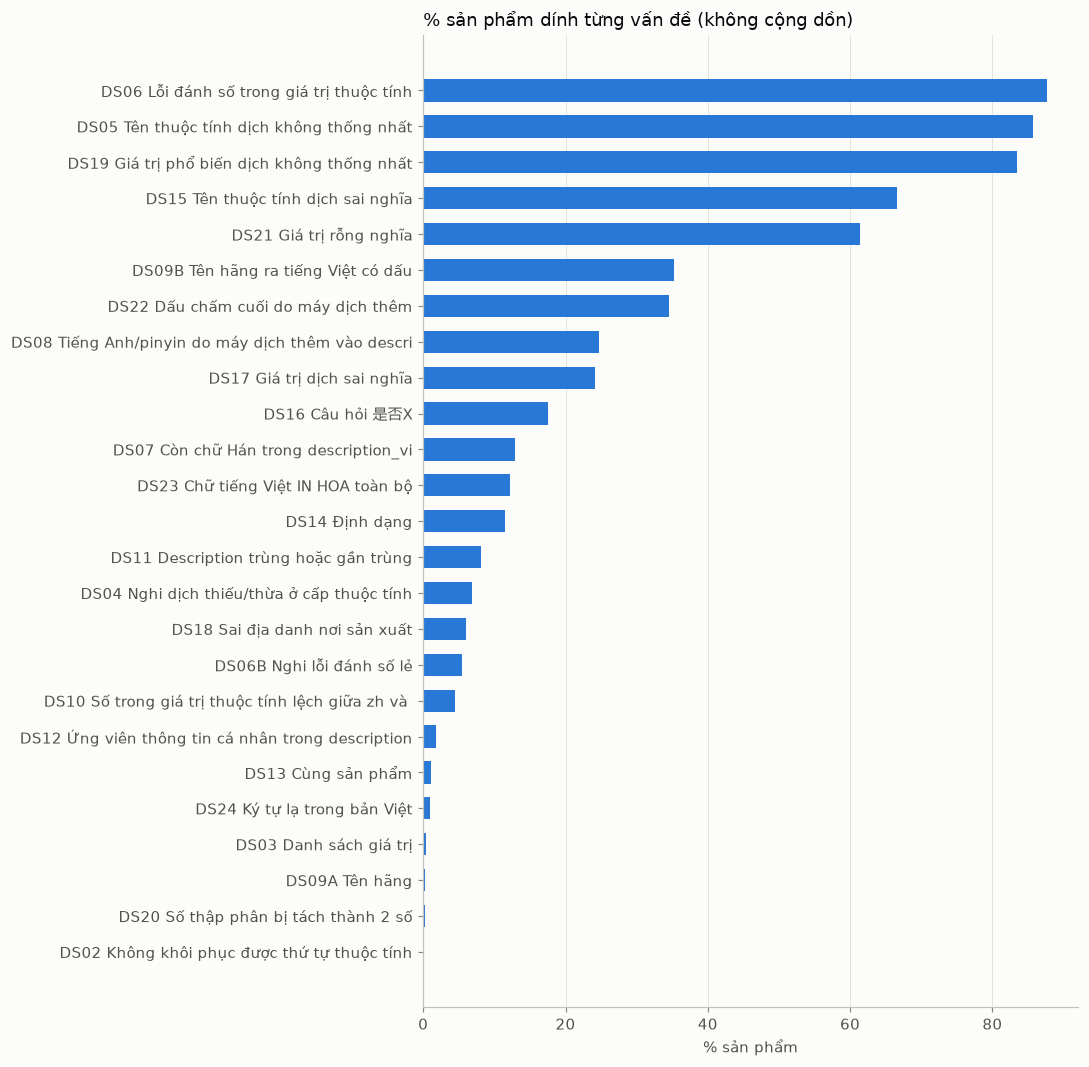

Dòng dính ≥ 1 vấn đề mức 1: 12.790 (78,24%); mức 1–2: 16.333 (99,91%); mức 1–3: 16.347 (99,99%)

Bảng kiểm: 49/49 chỉ số khớp số lúc khảo sát.


,chi_so,notebook,luc_khao_sat,khop
0,Số dòng (sản phẩm),16348,16348,True
1,description_zh dựng lại đúng từ attributes_zh,16347,16347,True
2,attributes_vi cùng thứ tự với description_vi,21,21,True
3,Dòng khôi phục được thứ tự,16342,16342,True
4,Dòng D08 (tách '; ' ra số đoạn khác nhau),72,72,True
5,... trong đó giá trị/tên tiếng Việt chứa '; ',72,72,True
6,... khôi phục được bằng cách mới,72,72,True
7,Cặp thuộc tính,406871,406871,True
8,Cặp thuộc tính lệch số giá trị zh/vi,0,0,True
9,Cặp giá trị,691128,691128,True



File đã xuất trong data/eda/description/:


,file,kb
0,desc_cum_gan_trung.csv,179
1,desc_gia_tri_dich_sai_nghia.csv,2
2,desc_issues_evidence.csv,9224
3,desc_issues_summary.csv,15
4,desc_loi_danh_so_mau_editted.csv,17
5,desc_so_lech.csv,488
6,desc_ten_dich_sai_nghia.csv,3
7,desc_ten_hang_mau_editted.csv,11
8,desc_ten_thuoc_tinh_cach_dich.csv,213
9,desc_thong_tin_ca_nhan_editted.csv,64


Tổng thời gian chạy: 103 giây


In [17]:
TEN_MUC = {0: "0 cấu trúc (không phải lỗi dịch)", 1: "1 sai/mất thông tin", 2: "2 lan rộng/hỏng đánh giá",
           3: "3 chưa tự nhiên/nghi ngờ", 4: "4 định dạng"}
rng = random.Random(SEED)
rows, ev = [], []
for ma, it in ISSUES.items():
    r = sorted(it["bang_chung"])
    cats = df.loc[r, "category"].value_counts().head(3)
    mau3 = rng.sample(r, min(3, len(r)))
    rows.append({"ma": ma, "muc_do": it["muc_do"], "ten_muc_do": TEN_MUC[it["muc_do"]], "van_de": it["van_de"],
                 "so_dong": len(r), "pct_dong": round(pct(len(r), N), 2), "so_cap": it["so_cap"],
                 "category_nhieu_nhat": ", ".join(f"{c} {so(v)}" for c, v in cats.items()),
                 "vi_du_bang_chung": " || ".join(f"{df.at[i, 'product_id']}: {it['bang_chung'][i]}" for i in mau3),
                 "vi_du_product_id": ", ".join(df.loc[r[:5], "product_id"]),
                 "cach_phat_hien": it["cach_phat_hien"]})
    ev += [{"ma_van_de": ma, "muc_do": it["muc_do"], "product_id": df.at[i, "product_id"], "category": df.at[i, "category"],
            "bang_chung": it["bang_chung"][i]} for i in r]
SUM = pd.DataFrame(rows)
SUM["_k"] = SUM.muc_do.replace(0, 9)          # mục cấu trúc (mức 0) xếp cuối bảng
SUM = SUM.sort_values(["_k", "so_dong"], ascending=[True, False]).drop(columns="_k").reset_index(drop=True)
display(SUM.drop(columns=["cach_phat_hien", "vi_du_product_id"]))
ghi_csv(SUM, "desc_issues_summary.csv")
ghi_csv(pd.DataFrame(ev), "desc_issues_evidence.csv")

S2 = SUM[SUM.muc_do > 0].sort_values("pct_dong", ascending=False)
bar_h([f"{m} {re.split(r' \(|,|:', v)[0][:44]}" for m, v in zip(S2.ma, S2.van_de)], S2.pct_dong, "% sản phẩm dính từng vấn đề (không cộng dồn)",
      "% sản phẩm", fmt_val=lambda v: f"{sf(v, 1)}%", width=10)

def rows_of(levels):
    s = set()
    for ma, it in ISSUES.items():
        if it["muc_do"] in levels:
            s |= set(it["bang_chung"])
    return s


r1, r12, r123 = rows_of({1}), rows_of({1, 2}), rows_of({1, 2, 3})
print(f"Dòng dính ≥ 1 vấn đề mức 1: {so(len(r1))} ({tl(len(r1), N)}); mức 1–2: {so(len(r12))} ({tl(len(r12), N)}); mức 1–3: {so(len(r123))} ({tl(len(r123), N)})")

CK = pd.DataFrame(CHECKS)
print(f"\nBảng kiểm: {so(CK.khop.sum())}/{so(len(CK))} chỉ số khớp số lúc khảo sát.")
display(CK)
print("\nFile đã xuất trong data/eda/description/:")
display(pd.DataFrame([{"file": p.name, "kb": round(p.stat().st_size / 1024)} for p in sorted(OUT.glob("*.csv"))]))
print(f"Tổng thời gian chạy: {time.time() - T0:.0f} giây")